Base model Simulation

Starting simulation with 200 players...
Parameters: c=1.0, k=0.5, y_hat=1.0


Simulating network evolution:  33%|███▎      | 100/300 [00:09<00:19, 10.40it/s]



Simulation converged after 101 steps!

Visualizing results...

Final statistics:
Core size (players acquiring significant info): 1
Core to total ratio: 0.01
Total information in network: 1.00
Average degree: 1.99
Degree centralization: 1.0000

Core players (acquiring significant information): [4]
Information levels of core players: [1.0]

Most popular players (by incoming links): [  4   0 127 128 129]
Their incoming links: [199.0, 0.0, 0.0, 0.0, 0.0]
Their information levels: [1.0, 0.0, 0.0, 0.0, 0.0]

Verifying the Law of the Few predictions:
1. Core size is small: 1/200 = 0.50%
2. Total information in network: 1.0000 (should be close to 1.0)
3. Information per hub: [1.0]
   Theoretical prediction: k/c = 0.5


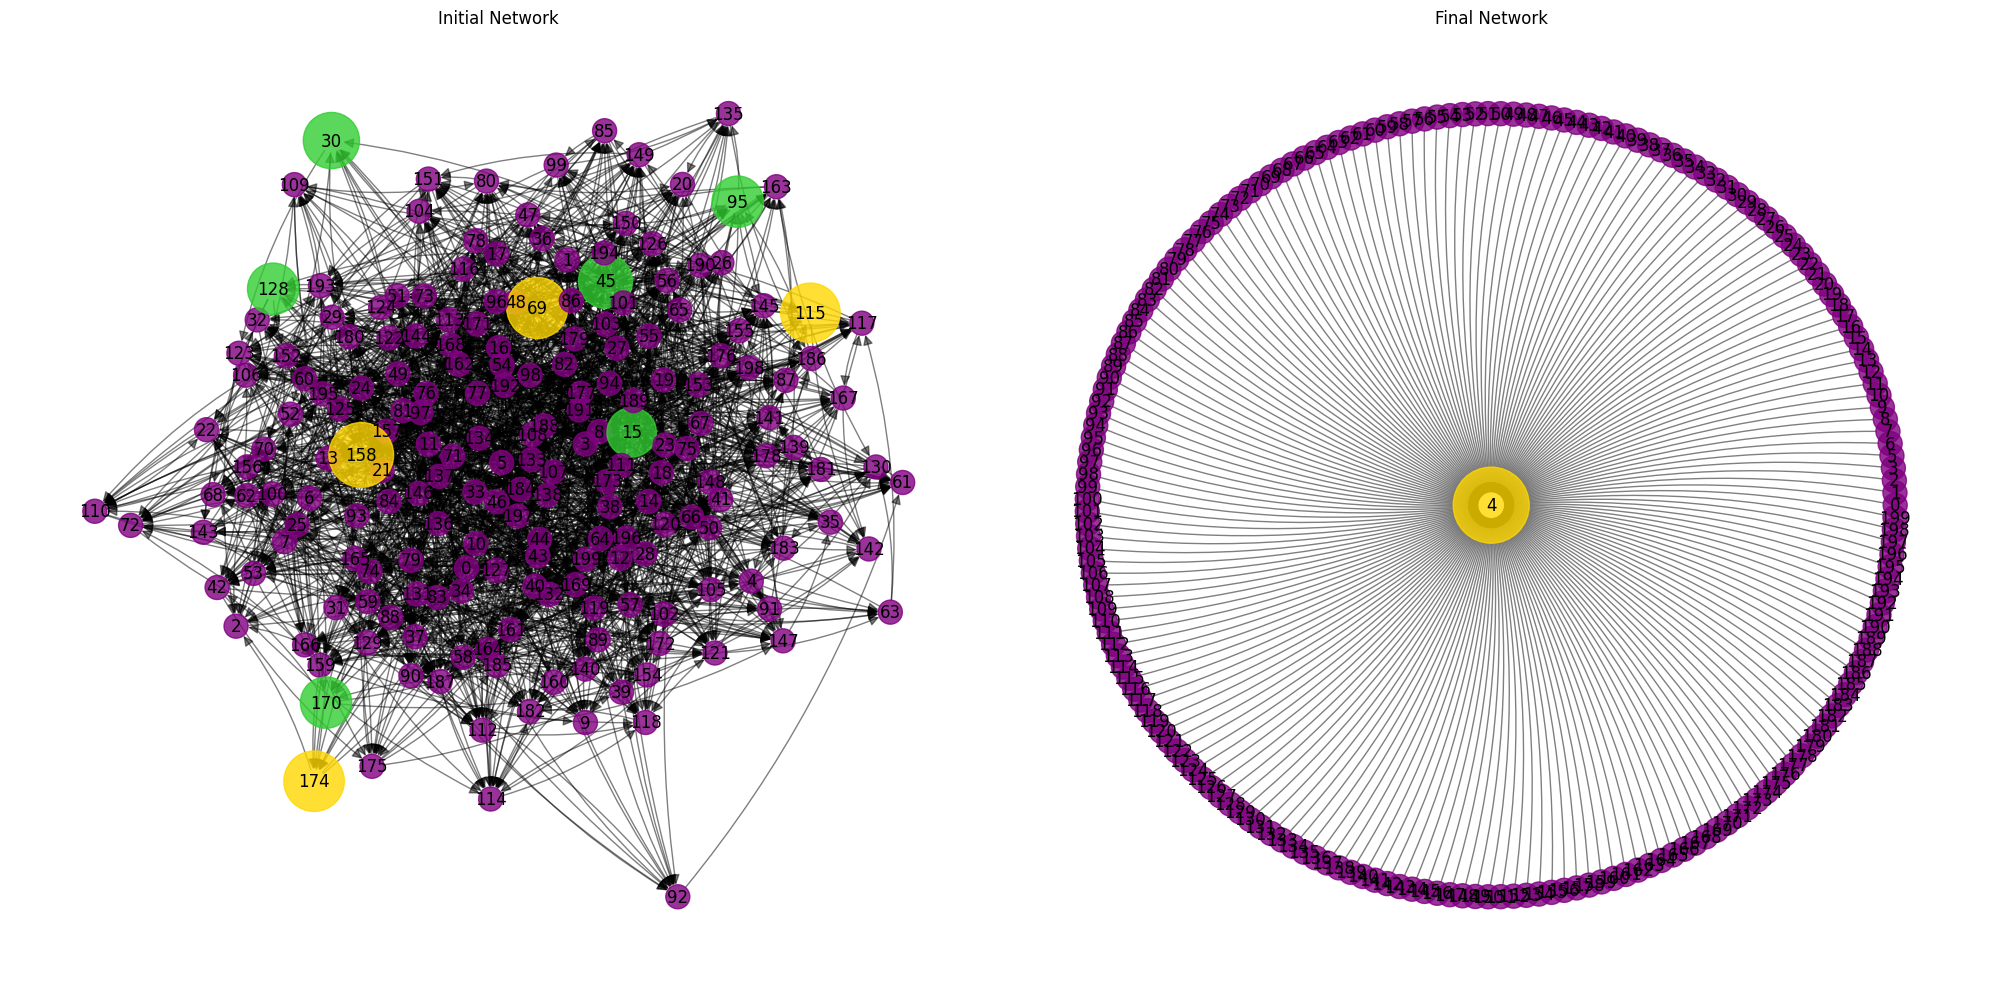

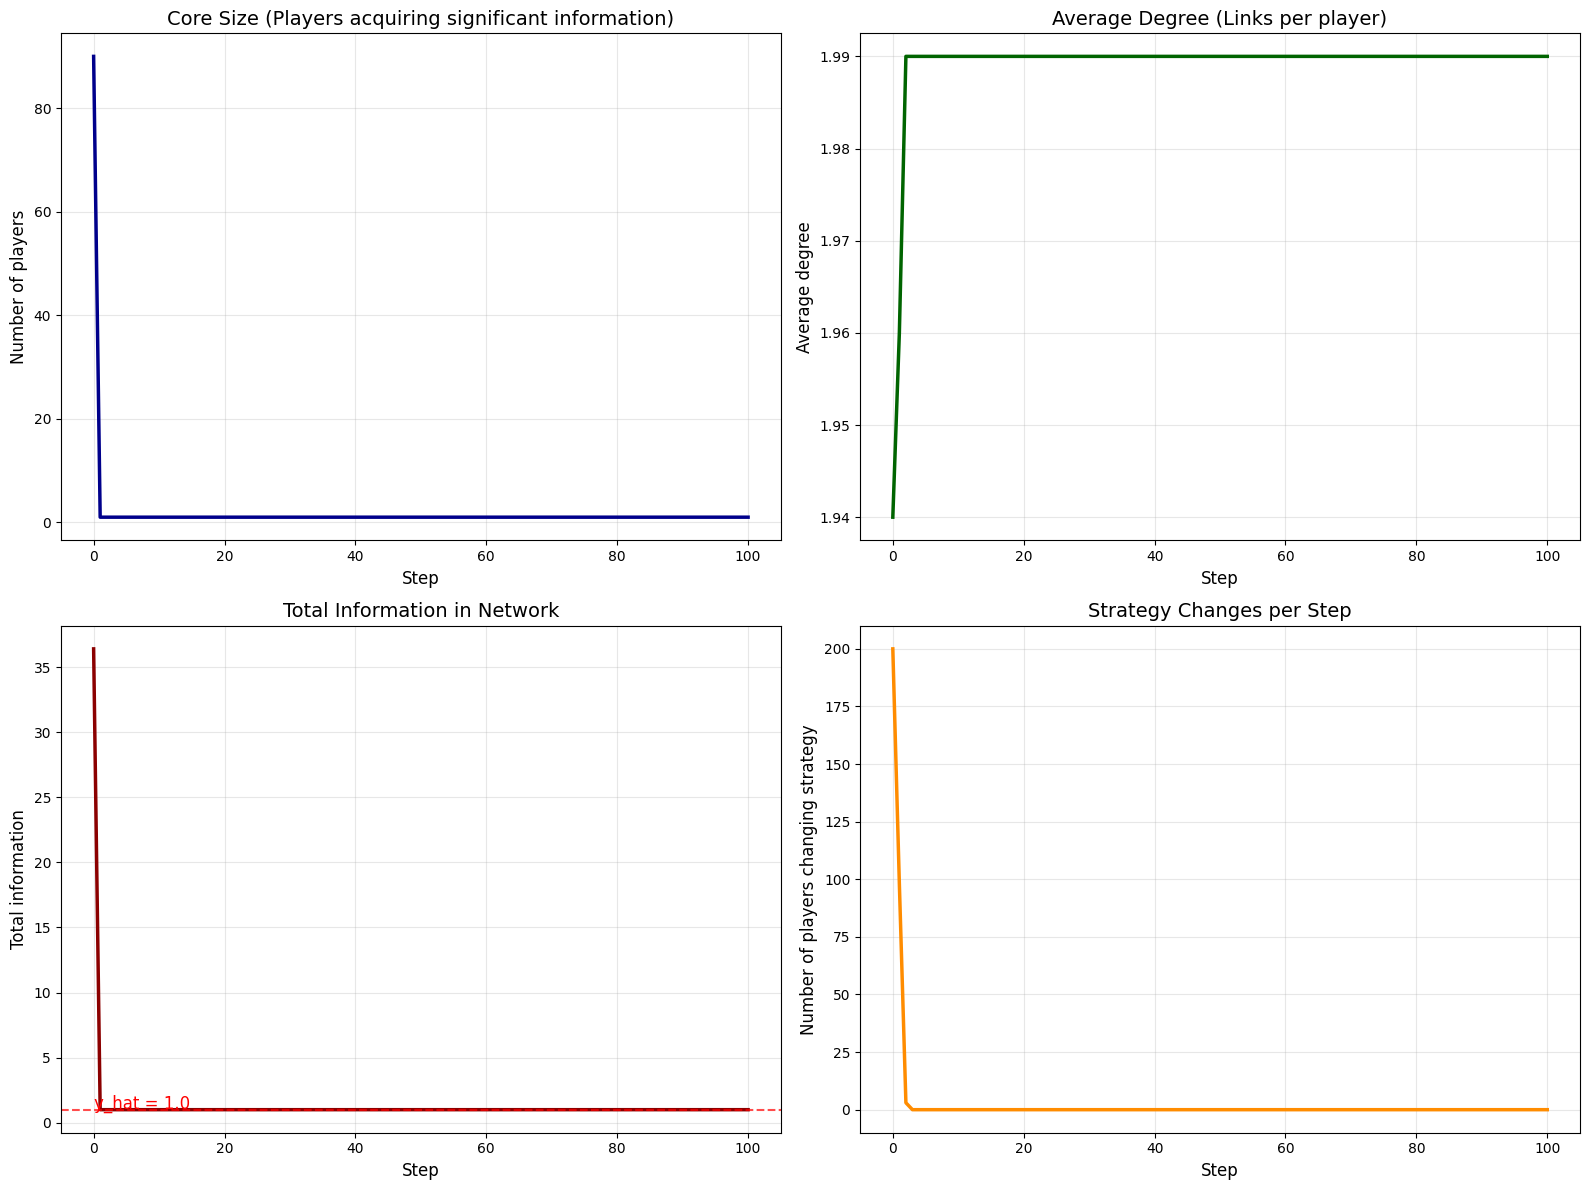

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import random

class LawOfFewModel:
    """
    Corrected implementation of the Law of the Few model from Galeotti and Goyal (2010).
    
    This model explores how individuals decide between personally acquiring information
    and forming strategic connections with others to access their information, leading
    to the emergence of core-periphery network structures with information specialization.
    
    Key insights from the paper:
    1. In equilibrium, each player either acquires information personally or forms links
       with others who do, creating a division between "hubs" and "spokes"
    2. Aggregate information in equilibrium should equal the optimal level for an isolated player
    3. The number of hubs is bounded and becomes a tiny fraction of the population as n grows
    """
    
    def __init__(self, n=10, c=1.0, k=0.5, y_hat=1.0, seed=None):
        """
        Initialize the model with parameters.
        
        Parameters:
        ----------
        n : int
            Number of players
        c : float
            Cost of acquiring one unit of information
        k : float
            Cost of forming a link with another player
        y_hat : float
            Optimal level of information for an isolated player
            (the amount that maximizes f(y) - cy)
        seed : int
            Random seed for reproducibility
        """
        self.n = n
        self.c = c
        self.k = k
        self.y_hat = y_hat
        
        # Set random seed if provided
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)
        
        # Initialize player strategies with balanced starting conditions
        # Initialize information acquisition (between 0 and y_hat)
        self.x = np.zeros(self.n)
        num_initial_info = min(int(n * 0.2), 10)  # 20% of players, but no more than 10
        initial_info_players = np.random.choice(n, num_initial_info, replace=False)
        for i in initial_info_players:
            self.x[i] = np.random.uniform(0.3, 0.7)
        
        # Initialize the network with a moderate number of links
        self.g = np.zeros((self.n, self.n))
        link_density = 0.05  # Start with a sparse network
        for i in range(self.n):
            for j in range(self.n):
                if i != j and np.random.random() < link_density:
                    self.g[i, j] = 1
    
    def information_utility(self, y):
        """Utility function f(y) for information, concave in y"""
        return np.log(1 + y)
    
    def get_accessible_information(self, player):
        """Calculate the total information player can access (own + neighbors')"""
        own_info = self.x[player]
        
        # Calculate undirected network (closure)
        g_closure = np.maximum(self.g, self.g.T)
        
        # Get information from neighbors
        neighbor_info = 0
        for j in range(self.n):
            if g_closure[player, j] == 1:
                neighbor_info += self.x[j]
                
        return own_info + neighbor_info
    
    def calculate_payoff(self, player):
        """Calculate the payoff for a given player"""
        accessible_info = self.get_accessible_information(player)
        
        # Information utility minus costs
        return (
            self.information_utility(accessible_info) - 
            self.c * self.x[player] - 
            self.k * np.sum(self.g[player])
        )
    
    def best_response_x(self, player):
        """
        Find the best response information acquisition for a player,
        given the current network and others' information levels
        """
        # Calculate information from neighbors
        g_closure = np.maximum(self.g, self.g.T)
        neighbor_info = sum(self.x[j] for j in range(self.n) if g_closure[player, j] == 1)
        
        # Best response is to acquire enough information to reach y_hat in total
        # This is a key insight from the paper
        best_x = max(0, min(self.y_hat - neighbor_info, self.y_hat))
        
        return best_x
    
    def best_response_links(self, player):
        """
        Find the best response linking strategy for a player,
        given the current information levels and others' links
        """
        # Create a copy of current links for this player
        current_links = self.g[player].copy()
        best_links = np.zeros(self.n)
        
        # First, calculate payoff with no links as baseline
        temp_links = np.zeros(self.n)
        self.g[player] = temp_links
        best_x_with_no_links = self.best_response_x(player)
        
        # Temporarily update information level to match best response
        original_x = self.x[player]
        self.x[player] = best_x_with_no_links
        
        # Get payoff with no links
        payoff_with_no_links = self.calculate_payoff(player)
        
        # Keep track of best payoff and corresponding links
        best_payoff = payoff_with_no_links
        
        # Try forming links with each player who has information
        for j in range(self.n):
            if j != player and self.x[j] > 0:
                # Try a link with just this player
                temp_links = np.zeros(self.n)
                temp_links[j] = 1
                self.g[player] = temp_links
                
                # Calculate best information level with this link
                best_x_with_link = self.best_response_x(player)
                
                # Temporarily update information level
                self.x[player] = best_x_with_link
                
                # Calculate payoff with this link
                payoff_with_link = self.calculate_payoff(player)
                
                # Update best links if this is better
                if payoff_with_link > best_payoff:
                    best_payoff = payoff_with_link
                    best_links = temp_links.copy()
        
        # Try forming links with the top information providers
        sorted_info_players = np.argsort(-self.x)
        top_info_players = [i for i in sorted_info_players if i != player and self.x[i] > 0][:5]
        
        if len(top_info_players) > 0:
            # Try links with all top info providers
            temp_links = np.zeros(self.n)
            for j in top_info_players:
                temp_links[j] = 1
            
            self.g[player] = temp_links
            best_x_with_links = self.best_response_x(player)
            self.x[player] = best_x_with_links
            payoff_with_links = self.calculate_payoff(player)
            
            if payoff_with_links > best_payoff:
                best_payoff = payoff_with_links
                best_links = temp_links.copy()
        
        # Restore original information and links
        self.x[player] = original_x
        self.g[player] = current_links
        
        return best_links
    
    def update_player(self, player):
        """Update strategy (information and links) for a given player"""
        # Store old strategies to check for changes
        old_x = self.x[player]
        old_links = self.g[player].copy()
        
        # Update linking strategy
        new_links = self.best_response_links(player)
        self.g[player] = new_links
        
        # Update information acquisition based on new links
        new_x = self.best_response_x(player)
        self.x[player] = new_x
        
        # Return whether this player's strategy changed significantly
        info_changed = abs(old_x - new_x) > 1e-3
        links_changed = not np.array_equal(old_links, new_links)
        
        return info_changed or links_changed
    
    def simulate_step(self):
        """Simulate one step of the model by updating all players"""
        # Shuffle the order of players to avoid systematic bias
        players = list(range(self.n))
        random.shuffle(players)
        
        changes = 0
        for player in players:
            if self.update_player(player):
                changes += 1
        
        return changes
    
    def simulate(self, max_steps=1000, convergence_threshold=0, check_window=5):
        """
        Run the simulation until convergence or maximum steps
        
        Parameters:
        ----------
        max_steps : int
            Maximum number of steps to simulate
        convergence_threshold : int
            Simulation stops when fewer than this many players change their strategy
        check_window : int
            Number of consecutive steps to check for convergence
        
        Returns:
        -------
        history : dict
            Dictionary containing the simulation history
        converged : bool
            Whether the simulation converged
        steps_to_convergence : int
            Number of steps until convergence (or max_steps if not converged)
        """
        history = {
            'x': [self.x.copy()],
            'g': [self.g.copy()],
            'core_size': [],
            'avg_degree': [],
            'total_info': [],
            'changes': []
        }
        
        converged = False
        steps_to_convergence = max_steps
        
        # Keep track of changes for the last few steps to determine convergence
        change_history = []
        
        for step in tqdm(range(max_steps), desc="Simulating network evolution"):
            changes = self.simulate_step()
            history['changes'].append(changes)
            change_history.append(changes)
            
            # Store the current state periodically
            if step % 10 == 0 or step == max_steps - 1:
                history['x'].append(self.x.copy())
                history['g'].append(self.g.copy())
            
            # Calculate metrics
            # - Core size: number of players acquiring significant information
            core_size = sum(1 for x_i in self.x if x_i > 0.1 * self.y_hat)
            history['core_size'].append(core_size)
            
            # - Average degree: average number of links per player
            avg_degree = np.mean(np.sum(np.maximum(self.g, self.g.T), axis=1))
            history['avg_degree'].append(avg_degree)
            
            # - Total information acquired in the network
            total_info = np.sum(self.x)
            history['total_info'].append(total_info)
            
            # Check for convergence after some initial steps
            if step >= 100 and convergence_threshold > 0:
                # Check if changes in the last check_window steps are all below threshold
                if len(change_history) > check_window:
                    change_history = change_history[-check_window:]
                    if max(change_history) <= convergence_threshold:
                        converged = True
                        steps_to_convergence = step + 1
                        break
        
        # Always store final state
        if not converged or len(history['x']) == 1 or step % 10 != 0:
            history['x'].append(self.x.copy())
            history['g'].append(self.g.copy())
        
        return history, converged, steps_to_convergence
    
    def plot_network(self, ax=None, title=None, use_circular_layout=False):
        """
        Plot the current network with node sizes proportional to information acquisition
        
        Parameters:
        ----------
        ax : matplotlib.axes.Axes
            Axes to plot on, if None, create new figure
        title : str
            Title for the plot
        use_circular_layout : bool
            Whether to force a circular layout with hub in center (for final network)
            or use spring layout (for initial network)
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 10))
        
        # Create a networkx graph
        G = nx.DiGraph()
        
        # Add nodes
        for i in range(self.n):
            G.add_node(i, info=self.x[i])
        
        # Add edges
        for i in range(self.n):
            for j in range(self.n):
                if self.g[i, j] > 0:
                    G.add_edge(i, j)
        
        # Define thresholds for node classification
        hub_threshold = 0.5 * self.y_hat
        medium_threshold = 0.1 * self.y_hat
        
        # Categorize nodes
        hub_nodes = [node for node, info in nx.get_node_attributes(G, 'info').items() if info >= hub_threshold]
        medium_nodes = [node for node, info in nx.get_node_attributes(G, 'info').items() 
                       if medium_threshold <= info < hub_threshold]
        periphery_nodes = [node for node, info in nx.get_node_attributes(G, 'info').items() if info < medium_threshold]
        
        # Choose layout based on parameter
        if use_circular_layout and hub_nodes:
            # Use a circular layout with hubs in the center
            pos = {}
            
            # Place hubs in the center
            if len(hub_nodes) == 1:
                # Single hub in the exact center
                pos[hub_nodes[0]] = np.array([0.5, 0.5])
            else:
                # Multiple hubs arranged in a small circle in the center
                for i, node in enumerate(hub_nodes):
                    angle = 2 * np.pi * i / len(hub_nodes)
                    pos[node] = np.array([0.5 + 0.1 * np.cos(angle), 0.5 + 0.1 * np.sin(angle)])
            
            # Arrange other nodes in a circle around the hubs
            non_hub_nodes = [n for n in G.nodes() if n not in hub_nodes]
            for i, node in enumerate(non_hub_nodes):
                angle = 2 * np.pi * i / len(non_hub_nodes)
                pos[node] = np.array([0.5 + 0.4 * np.cos(angle), 0.5 + 0.4 * np.sin(angle)])
        else:
            # Use spring layout for initial network (more chaotic)
            pos = nx.spring_layout(G, seed=42, k=0.2)  # k=0.2 gives more spread
        
        # Normalize sizes for better visualization
        max_info = max(1e-6, self.y_hat)  # Avoid division by zero
        min_size = 300
        max_size = 3000
        
        # Calculate node sizes based on information
        node_sizes = [min_size + (max_size - min_size) * (info/max_info) for info in nx.get_node_attributes(G, 'info').values()]
        
        # Color nodes based on information level
        # Yellow for high info (hubs), green for medium, purple for low (periphery)
        info_values = list(nx.get_node_attributes(G, 'info').values())
        node_colors = []
        for info in info_values:
            if info >= hub_threshold:
                node_colors.append('gold')
            elif info >= medium_threshold:
                node_colors.append('limegreen')
            else:
                node_colors.append('purple')
        
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8, ax=ax)
        nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, ax=ax, 
                               arrowsize=15, connectionstyle='arc3,rad=0.1')
        nx.draw_networkx_labels(G, pos, ax=ax)
        
        if title:
            ax.set_title(title)
        ax.axis('off')
        
        return ax
    
    def plot_metrics(self, history):
        """Plot metrics from the simulation history"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Flatten the 2x2 grid to make indexing easier
        axes = axes.flatten()
        
        # Plot 1: Core size over time
        axes[0].plot(history['core_size'], linewidth=2.5, color='darkblue')
        axes[0].set_title('Core Size (Players acquiring significant information)', fontsize=14)
        axes[0].set_xlabel('Step', fontsize=12)
        axes[0].set_ylabel('Number of players', fontsize=12)
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Average degree over time
        axes[1].plot(history['avg_degree'], linewidth=2.5, color='darkgreen')
        axes[1].set_title('Average Degree (Links per player)', fontsize=14)
        axes[1].set_xlabel('Step', fontsize=12)
        axes[1].set_ylabel('Average degree', fontsize=12)
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Total information over time
        axes[2].plot(history['total_info'], linewidth=2.5, color='darkred')
        axes[2].set_title('Total Information in Network', fontsize=14)
        axes[2].set_xlabel('Step', fontsize=12)
        axes[2].set_ylabel('Total information', fontsize=12)
        axes[2].grid(True, alpha=0.3)
        
        # Add horizontal line at y_hat for reference
        axes[2].axhline(y=self.y_hat, color='r', linestyle='--', alpha=0.7)
        axes[2].text(0, self.y_hat*1.05, f'y_hat = {self.y_hat}', color='r', fontsize=12)
        
        # Plot 4: Number of changes per iteration
        axes[3].plot(history['changes'], linewidth=2.5, color='darkorange')
        axes[3].set_title('Strategy Changes per Step', fontsize=14)
        axes[3].set_xlabel('Step', fontsize=12)
        axes[3].set_ylabel('Number of players changing strategy', fontsize=12)
        axes[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig


def run_simulation(n=200, c=1.0, k=0.5, y_hat=1.0, max_steps=300, convergence_threshold=3, 
                seed=42, save_plots=False, output_dir='.'):
    """
    Run a complete simulation and display results
    
    Parameters:
    -----------
    n : int
        Number of players
    c : float
        Cost of information
    k : float
        Cost of linking
    y_hat : float
        Optimal information level
    max_steps : int
        Maximum simulation steps
    convergence_threshold : int
        Simulation stops when fewer than this many players change strategy
    seed : int
        Random seed for reproducibility
    save_plots : bool
        Whether to save plots to files (may fail due to permissions)
    output_dir : str
        Directory to save plots to (if save_plots is True)
    """
    # Check if k < c*y_hat as this is the interesting case in the paper
    if k >= c*y_hat:
        print(f"Warning: k ({k}) >= c*y_hat ({c*y_hat}), so we expect no links in equilibrium")
    
    print(f"Starting simulation with {n} players...")
    print(f"Parameters: c={c}, k={k}, y_hat={y_hat}")
    
    # Initialize the model
    model = LawOfFewModel(n=n, c=c, k=k, y_hat=y_hat, seed=seed)
    
    # Store initial state for visualization
    initial_x = model.x.copy()
    initial_g = model.g.copy()
    
    # Run the simulation
    history, converged, steps = model.simulate(max_steps=max_steps, convergence_threshold=convergence_threshold)
    
    # Print convergence information
    if converged:
        print(f"\nSimulation converged after {steps} steps!")
    else:
        print(f"\nSimulation did not converge within {max_steps} steps.")
    
    # Plot the results
    print("\nVisualizing results...")
    
    # Plot network before and after
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Initial network - use spring layout
    model.x = initial_x
    model.g = initial_g
    model.plot_network(ax=ax1, title='Initial Network', use_circular_layout=False)
    
    # Final network - use circular layout
    model.x = history['x'][-1]
    model.g = history['g'][-1]
    model.plot_network(ax=ax2, title='Final Network', use_circular_layout=True)
    
    plt.tight_layout()
    
    # Try to save plots if requested
    if save_plots:
        try:
            import os
            networks_file = os.path.join(output_dir, 'law_of_few_networks.png')
            plt.savefig(networks_file, dpi=300)
            print(f"Saved network visualization to {networks_file}")
        except (OSError, IOError) as e:
            print(f"Warning: Could not save network visualization: {e}")
    
    # Plot metrics
    metrics_fig = model.plot_metrics(history)
    
    if save_plots:
        try:
            import os
            metrics_file = os.path.join(output_dir, 'law_of_few_metrics.png')
            plt.savefig(metrics_file, dpi=300)
            print(f"Saved metrics visualization to {metrics_file}")
        except (OSError, IOError) as e:
            print(f"Warning: Could not save metrics visualization: {e}")
    
    # Display final stats
    final_x = history['x'][-1]
    final_g = history['g'][-1]
    
    # Calculate core size (players with significant information)
    threshold = 0.1 * model.y_hat
    core_players = [i for i, x_i in enumerate(final_x) if x_i > threshold]
    periphery_players = [i for i in range(n) if i not in core_players]
    
    print("\nFinal statistics:")
    print(f"Core size (players acquiring significant info): {len(core_players)}")
    print(f"Core to total ratio: {len(core_players)/n:.2f}")
    print(f"Total information in network: {np.sum(final_x):.2f}")
    
    # Calculate average degree (the average number of links per player)
    final_g_closure = np.maximum(final_g, final_g.T)  # Get undirected network
    avg_degree = np.mean(np.sum(final_g_closure, axis=1))
    print(f"Average degree: {avg_degree:.2f}")
    
    # Calculate network metrics
    # Degree centralization (how centered the network is around hubs)
    degrees = np.sum(final_g_closure, axis=1)
    max_degree = np.max(degrees)
    degree_centralization = sum(max_degree - degrees) / ((n-1)*(n-2)) if n > 2 else 0
    print(f"Degree centralization: {degree_centralization:.4f}")
    
    # Identify core players (hubs) and their information levels
    print(f"\nCore players (acquiring significant information): {sorted(core_players)}")
    if len(core_players) <= 10:  # Only print details if few enough core players
        print(f"Information levels of core players: {[round(final_x[i], 4) for i in core_players]}")
    else:
        print(f"Average information level of core players: {np.mean([final_x[i] for i in core_players]):.4f}")
    
    # Get incoming links to each player (how many other players link to this player)
    incoming_links = np.sum(final_g, axis=0)
    popular_players = np.argsort(-incoming_links)[:5]  # Top 5 players by incoming links
    print(f"\nMost popular players (by incoming links): {popular_players}")
    print(f"Their incoming links: {[incoming_links[i] for i in popular_players]}")
    print(f"Their information levels: {[round(final_x[i], 4) for i in popular_players]}")
    
    # Verify Law of the Few predictions
    print("\nVerifying the Law of the Few predictions:")
    print(f"1. Core size is small: {len(core_players)}/{n} = {len(core_players)/n:.2%}")
    print(f"2. Total information in network: {np.sum(final_x):.4f} (should be close to {model.y_hat})")
    
    if core_players:
        core_player_info = [final_x[i] for i in core_players]
        print(f"3. Information per hub: {[round(x, 4) for x in core_player_info]}")
        print(f"   Theoretical prediction: k/c = {model.k/model.c}")
    
    return model, history


if __name__ == "__main__":
    import os
    import tempfile
    
    # Create a temporary directory for saving plots if desired
    temp_dir = tempfile.gettempdir()
    
    # Run simulation with parameters that will converge properly
    # Use use_seed=None for random initialization each time
    model, history = run_simulation(
        n=200,                    # Larger network to match uploaded example
        c=1.0,                    # Cost of information
        k=0.5,                    # Cost of linking
        y_hat=1.0,                # Optimal information level
        max_steps=300,            # Maximum simulation steps
        convergence_threshold=3,  # Stop when ≤3 players change strategy
        save_plots=False,         # Set to True if you want to save plots
        output_dir=temp_dir       # Use temporary directory for safer file saving
    )
    
    plt.show()

Model Simulation with Interest Vector

Starting interest-based simulation with 100 players, 5 interest dimensions...
Parameters: c=1.0, k=0.5, y_hat=1.0, interest_weight=0.5


100%|██████████| 300/300 [01:15<00:00,  3.96it/s]



Simulation reached maximum steps (300) without convergence.

Plotting results...

Final statistics:
Number of hubs: 2
Hub to total ratio: 0.02
Total information in network: 1.00
Average degree: 3.94

Hub nodes (specialized information providers): [25, 56]
Information levels of hubs: [0.5009297038556324, 0.4990702961443676]

Interest patterns of main hubs:
Hub 25: Top interests are dimensions [0 3 4] with values [ 0.86834218  0.03950387 -0.19958822]
  Followers' average interests: [-0.03442494  0.04717587 -0.06115177  0.05830887 -0.05022492]
  Avg. interest similarity with followers: -0.0224
Hub 56: Top interests are dimensions [4 2 1] with values [0.70909243 0.52724563 0.22011463]
  Followers' average interests: [-0.02530608  0.04273299 -0.06280167  0.05811892 -0.05173364]
  Avg. interest similarity with followers: -0.0853

Detected 2 interest-based communities:
Community 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 

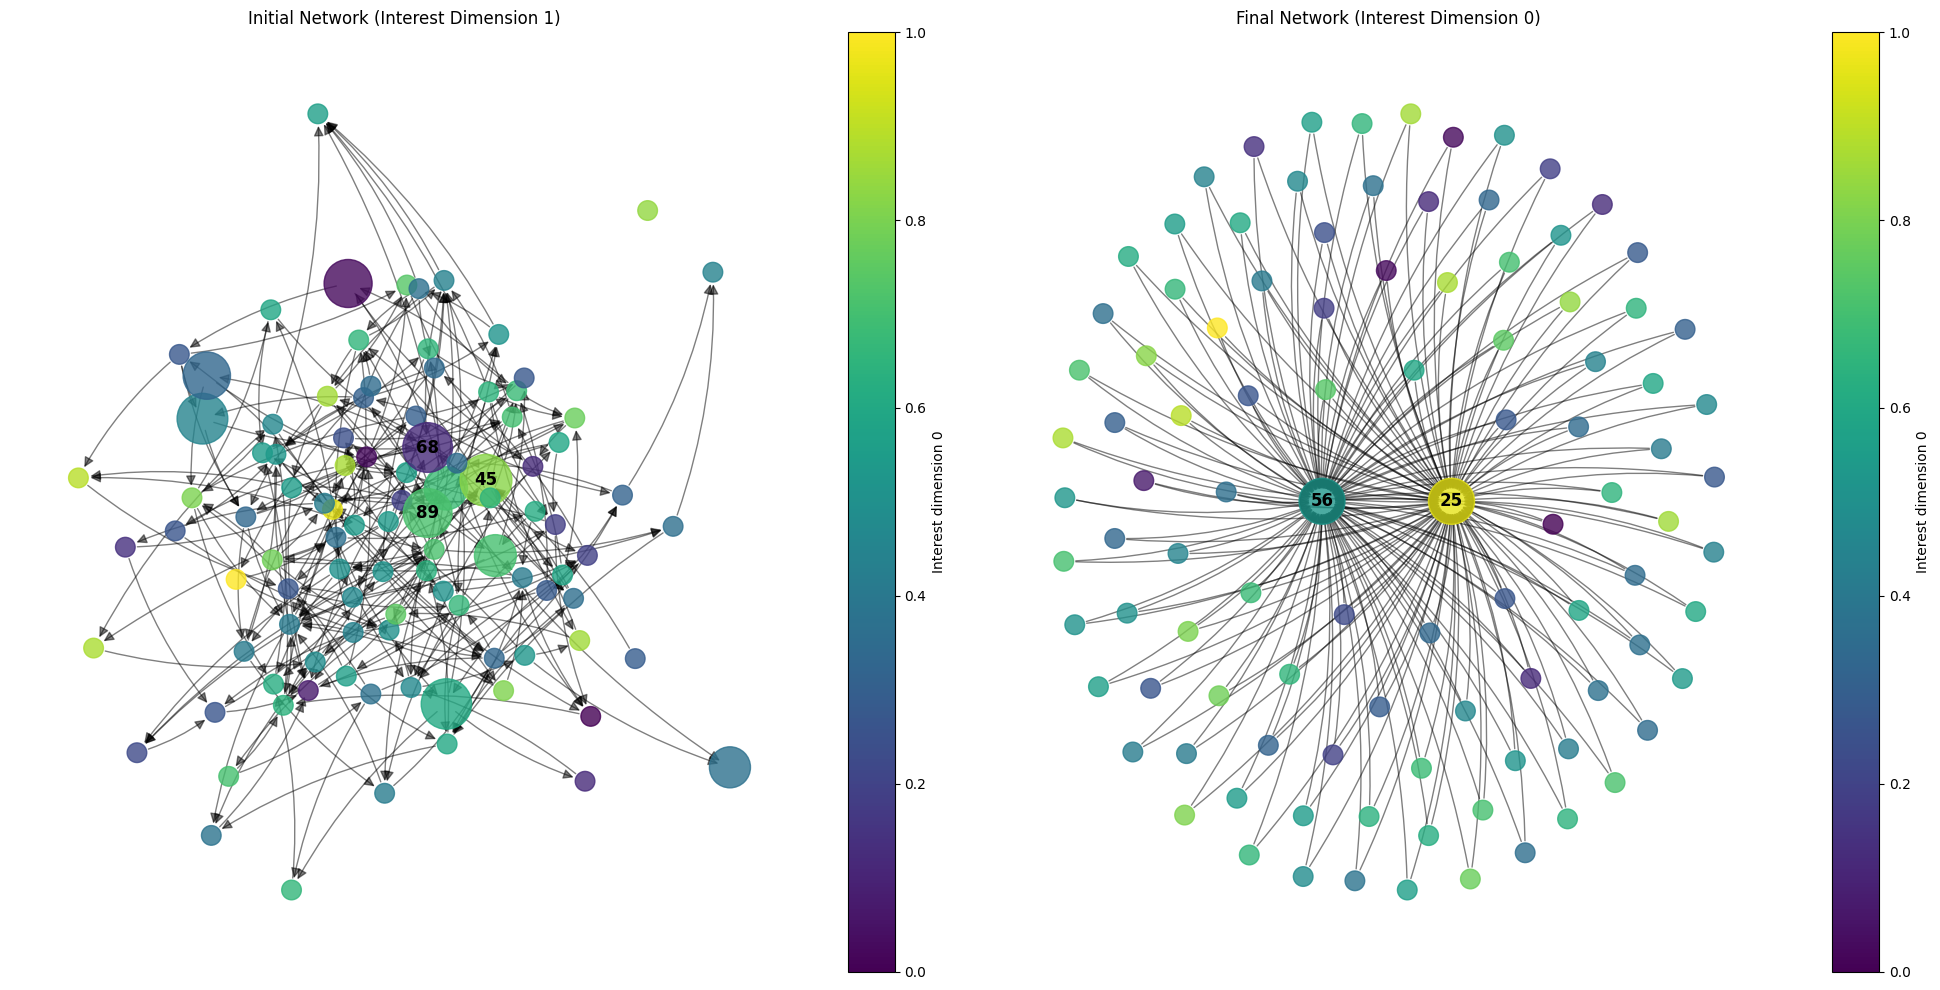

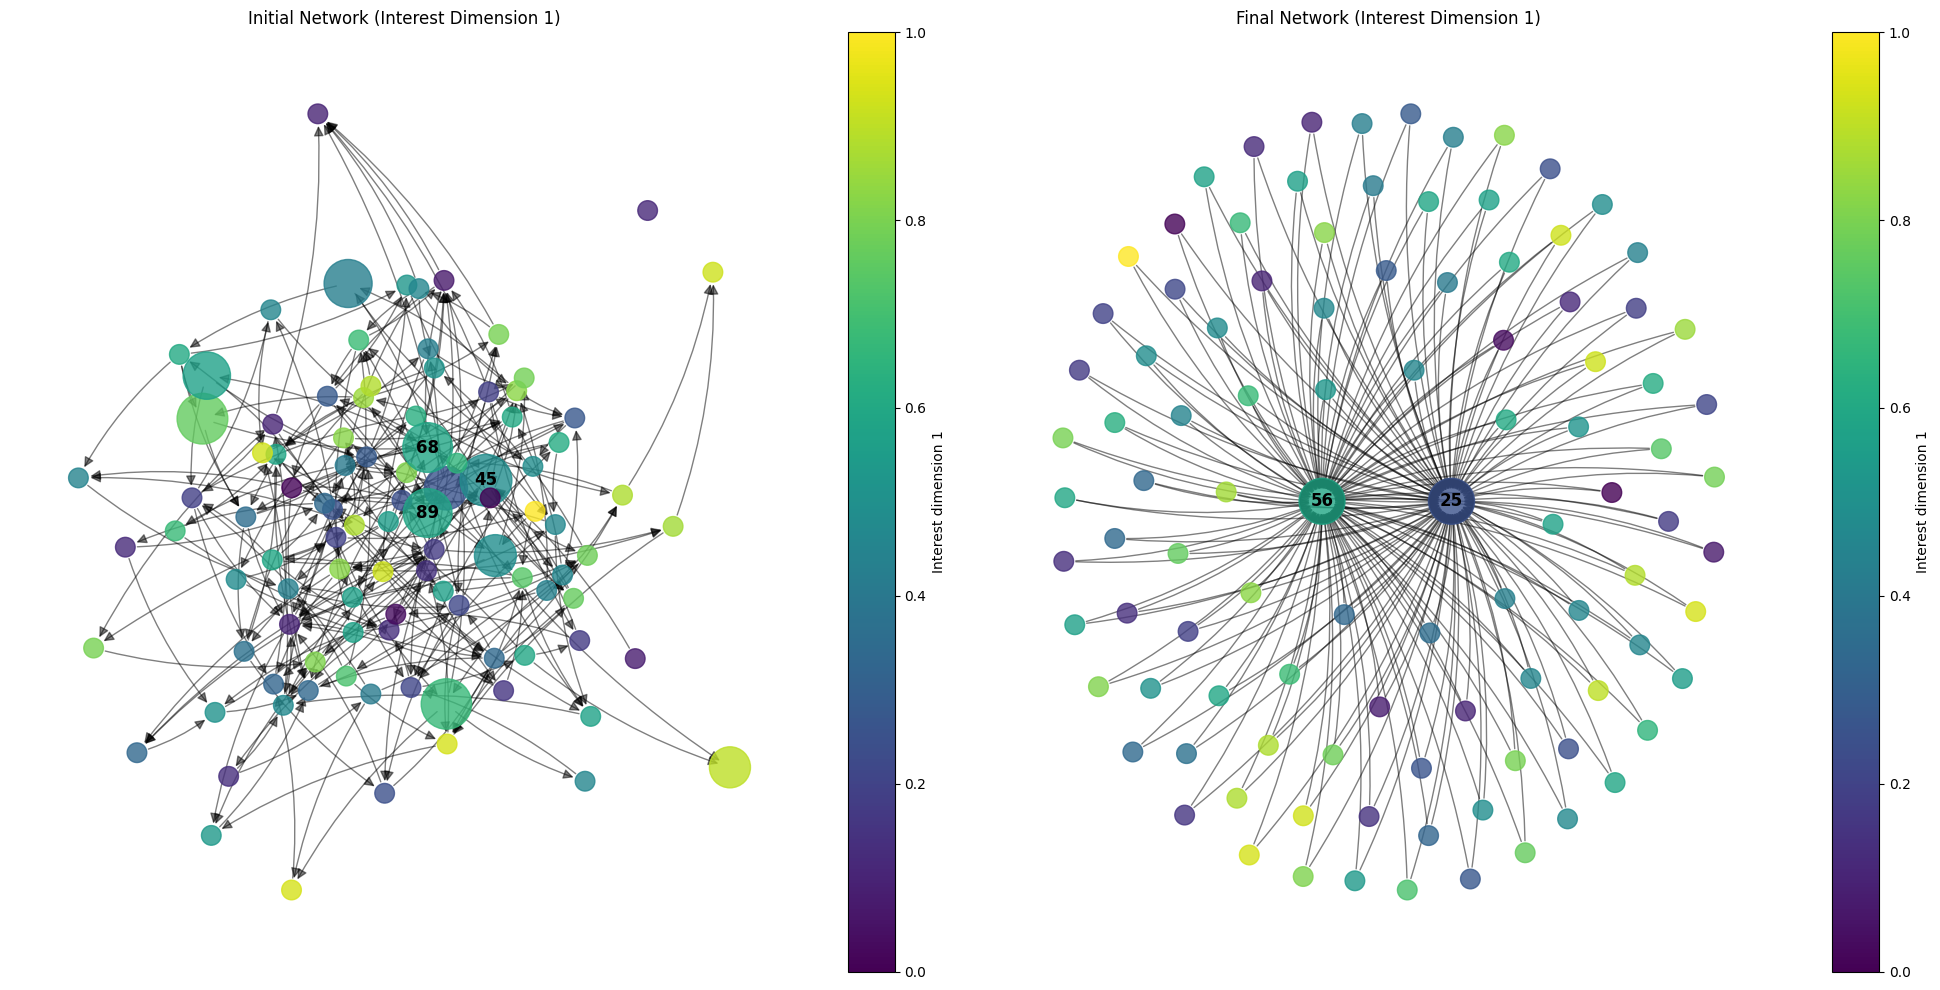

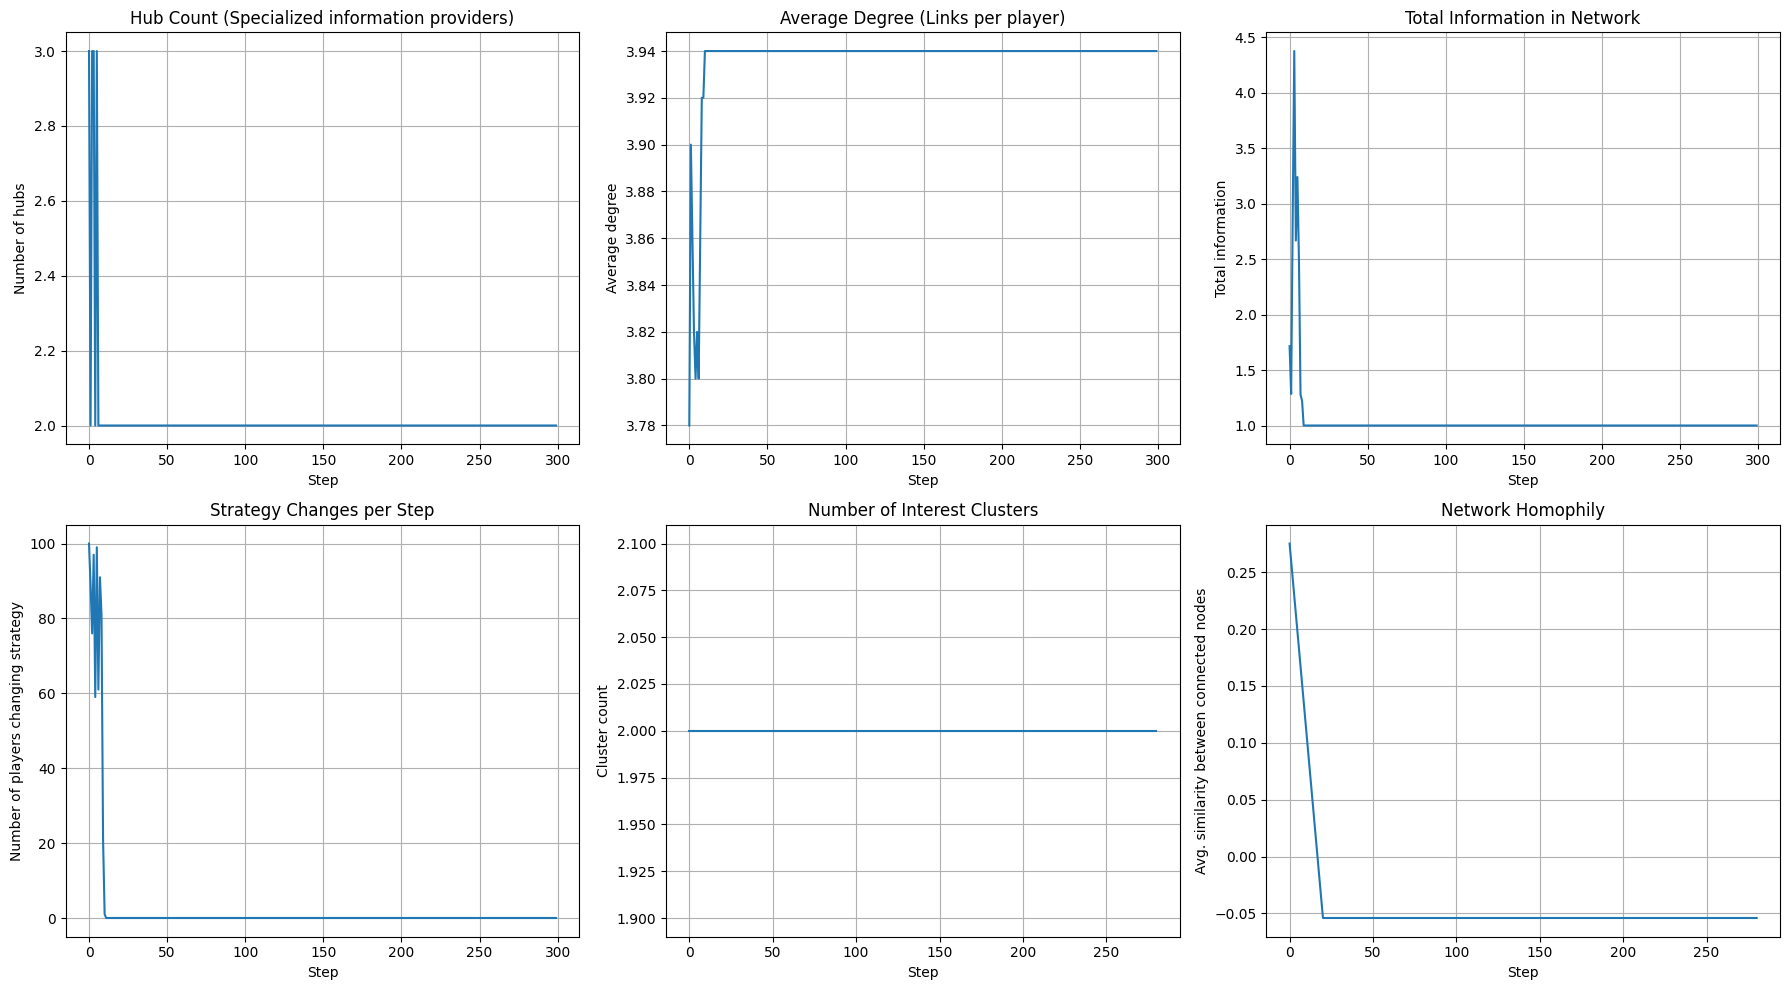

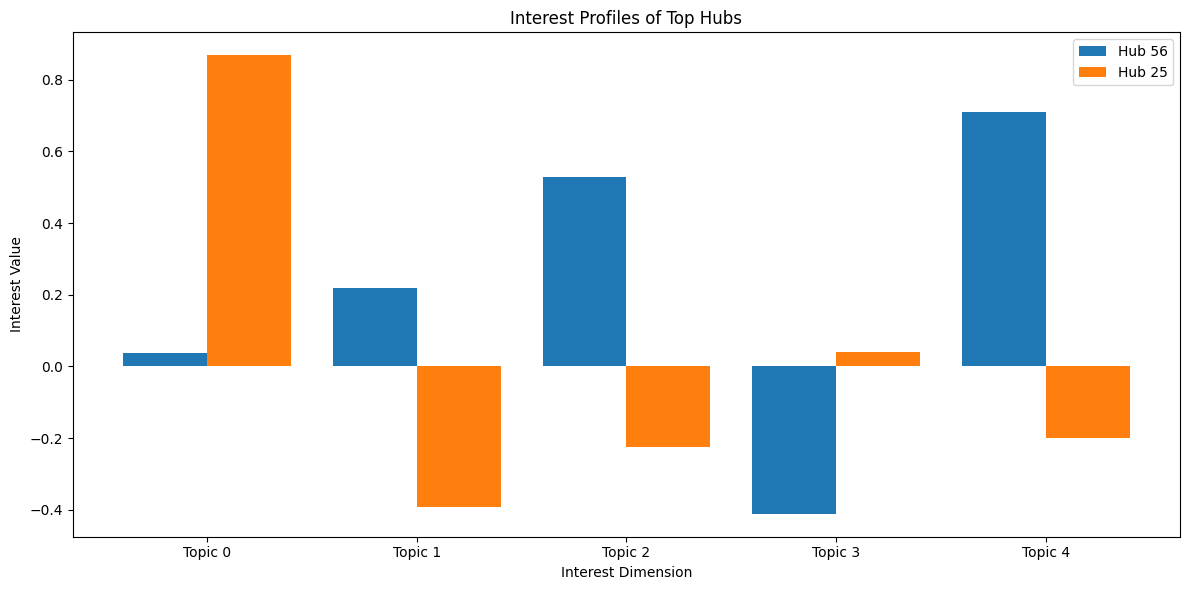

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import random
from scipy.spatial.distance import cosine

class InterestBasedLawOfFewModel:
    """
    Extension of the Law of the Few model from Galeotti and Goyal (2010) with diverse interests.
    
    This model creates a network where nodes have multidimensional interests and form connections
    based on interest similarity as well as information acquisition patterns.
    """
    
    def __init__(self, n=10, num_interests=5, c=1.0, k=0.5, y_hat=1.0, interest_weight=0.5, seed=None):
        """
        Initialize the model with parameters.
        
        Parameters:
        ----------
        n : int
            Number of players
        num_interests : int
            Number of interest dimensions for each player
        c : float
            Cost of acquiring one unit of information
        k : float
            Base cost of forming a link with another player
        y_hat : float
            Optimal level of information for an isolated player
        interest_weight : float
            Weight given to interest similarity in link formation (0-1)
        seed : int
            Random seed for reproducibility
        """
        self.n = n
        self.num_interests = num_interests
        self.c = c
        self.k = k
        self.y_hat = y_hat
        self.interest_weight = interest_weight
        
        # Set random seed if provided
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)
        
        # Generate interest vectors for each player (normally distributed)
        self.interests = np.random.normal(0, 1, (self.n, self.num_interests))
        
        # Normalize interest vectors to unit length for easier similarity calculation
        for i in range(self.n):
            norm = np.linalg.norm(self.interests[i])
            if norm > 0:  # Avoid division by zero
                self.interests[i] = self.interests[i] / norm
        
        # Calculate interest similarity matrix (higher values = more similar)
        self.similarity_matrix = np.zeros((self.n, self.n))
        for i in range(self.n):
            for j in range(self.n):
                if i != j:
                    # Use cosine similarity (1 = identical, 0 = orthogonal, -1 = opposite)
                    similarity = 1 - cosine(self.interests[i], self.interests[j])
                    self.similarity_matrix[i, j] = similarity
        
        # Initialize player strategies with balanced starting conditions
        # - x: personal information acquisition (between 0 and y_hat)
        # - g: adjacency matrix where g[i,j]=1 if i forms a link with j
        
        # Initialize a subset of players with moderate information
        self.x = np.zeros(self.n)
        num_initial_info = min(int(n * 0.2), 10)  # 20% of players, but no more than 10
        initial_info_players = np.random.choice(n, num_initial_info, replace=False)
        for i in initial_info_players:
            self.x[i] = np.random.uniform(0.3, 0.7)
        
        # Initialize with a moderate number of links based on interest similarity
        self.g = np.zeros((self.n, self.n))
        link_density = 0.05  # Start with a sparse network
        for i in range(self.n):
            # More likely to link to similar players
            probabilities = link_density * (1 + self.similarity_matrix[i]) / 2
            for j in range(self.n):
                if i != j and np.random.random() < probabilities[j]:
                    self.g[i, j] = 1
    
    def information_utility(self, y):
        """Utility function f(y) for information, concave in y"""
        return np.log(1 + y)
    
    def get_accessible_information(self, player):
        """Calculate the total information player can access (own + neighbors')"""
        own_info = self.x[player]
        
        # Calculate undirected network (closure)
        g_closure = np.maximum(self.g, self.g.T)
        
        # Get information from neighbors
        neighbor_info = 0
        for j in range(self.n):
            if g_closure[player, j] == 1:
                neighbor_info += self.x[j]
                
        return own_info + neighbor_info
    
    def adjusted_link_cost(self, player, target):
        """
        Calculate adjusted cost of linking to target based on interest similarity.
        
        Higher similarity = lower cost
        """
        base_cost = self.k
        similarity = self.similarity_matrix[player, target]
        
        # Adjust cost based on similarity
        # More similar interests = lower cost (at most reduced by interest_weight*k)
        adjusted_cost = base_cost * (1 - self.interest_weight * (similarity + 1) / 2)
        
        return max(0.1, adjusted_cost)  # Ensure minimum cost threshold
    
    def calculate_payoff(self, player):
        """Calculate the payoff for a given player"""
        accessible_info = self.get_accessible_information(player)
        
        # Information utility minus costs
        info_cost = self.c * self.x[player]
        
        # Calculate link costs with interest adjustment
        link_cost = 0
        for j in range(self.n):
            if self.g[player, j] == 1:
                link_cost += self.adjusted_link_cost(player, j)
        
        return self.information_utility(accessible_info) - info_cost - link_cost
    
    def best_response_x(self, player):
        """
        Find the best response information acquisition for a player,
        given the current network and others' information levels
        """
        # Calculate information from neighbors
        g_closure = np.maximum(self.g, self.g.T)
        neighbor_info = sum(self.x[j] for j in range(self.n) if g_closure[player, j] == 1)
        
        # Best response is to acquire enough information to reach y_hat in total
        best_x = max(0, min(self.y_hat - neighbor_info, self.y_hat))
        
        return best_x
    
    def best_response_links(self, player):
        """
        Find the best response linking strategy for a player,
        given the current information levels and others' links
        """
        # Create a copy of current links for this player
        current_links = self.g[player].copy()
        best_links = np.zeros(self.n)
        
        # First, calculate payoff with no links as baseline
        temp_links = np.zeros(self.n)
        self.g[player] = temp_links
        best_x_with_no_links = self.best_response_x(player)
        
        # Temporarily update information level to match best response
        original_x = self.x[player]
        self.x[player] = best_x_with_no_links
        
        # Get payoff with no links
        payoff_with_no_links = self.calculate_payoff(player)
        
        # Keep track of best payoff and corresponding links
        best_payoff = payoff_with_no_links
        
        # Try forming links with each player who has information
        for j in range(self.n):
            if j != player and self.x[j] > 0:
                # Try a link with just this player
                temp_links = np.zeros(self.n)
                temp_links[j] = 1
                self.g[player] = temp_links
                
                # Calculate best information level with this link
                best_x_with_link = self.best_response_x(player)
                
                # Temporarily update information level
                self.x[player] = best_x_with_link
                
                # Calculate payoff with this link
                payoff_with_link = self.calculate_payoff(player)
                
                # Update best links if this is better
                if payoff_with_link > best_payoff:
                    best_payoff = payoff_with_link
                    best_links = temp_links.copy()
        
        # Try forming links with players that have high interest similarity
        # Get top similar players
        top_similar_indices = np.argsort(-self.similarity_matrix[player])[:5]  # Top 5 similar players
        
        for k in range(1, 6):  # Try connecting to 1-5 most similar players
            temp_links = np.zeros(self.n)
            for j in top_similar_indices[:k]:
                if j != player:  # Avoid self-links
                    temp_links[j] = 1
            
            self.g[player] = temp_links
            
            # Calculate best information level with these links
            best_x_with_links = self.best_response_x(player)
            
            # Temporarily update information level
            self.x[player] = best_x_with_links
            
            # Calculate payoff with these links
            payoff_with_links = self.calculate_payoff(player)
            
            # Update best links if this is better
            if payoff_with_links > best_payoff:
                best_payoff = payoff_with_links
                best_links = temp_links.copy()
        
        # Try forming links with the top information providers in each interest cluster
        # We'll use interest clusters to find specialized information sources
        
        # Find top information providers
        top_info_providers = np.argsort(-self.x)[:10]  # Top 10 info providers
        
        if len(top_info_providers) > 0:
            # Try combinations of info providers that also have good similarity
            for k in range(1, 4):  # Try 1-3 information providers
                for combo in self._get_combinations(top_info_providers, k):
                    temp_links = np.zeros(self.n)
                    for j in combo:
                        if j != player:
                            temp_links[j] = 1
                    
                    self.g[player] = temp_links
                    
                    # Calculate best information level with these links
                    best_x_with_links = self.best_response_x(player)
                    
                    # Temporarily update information level
                    self.x[player] = best_x_with_links
                    
                    # Calculate payoff with these links
                    payoff_with_links = self.calculate_payoff(player)
                    
                    # Update best links if this is better
                    if payoff_with_links > best_payoff:
                        best_payoff = payoff_with_links
                        best_links = temp_links.copy()
        
        # Restore original information and links
        self.x[player] = original_x
        self.g[player] = current_links
        
        return best_links
    
    def _get_combinations(self, items, k):
        """Helper function to get combinations of k items"""
        if k > len(items):
            return []
        
        if k == 1:
            return [[item] for item in items]
        
        result = []
        for i in range(len(items)):
            for combo in self._get_combinations(items[i+1:], k-1):
                result.append([items[i]] + combo)
        
        return result[:20]  # Limit combinations to avoid explosion
    
    def update_player(self, player):
        """Update strategy (information and links) for a given player"""
        # Store old strategies to check for changes
        old_x = self.x[player]
        old_links = self.g[player].copy()
        
        # Update linking strategy
        new_links = self.best_response_links(player)
        self.g[player] = new_links
        
        # Update information acquisition based on new links
        new_x = self.best_response_x(player)
        self.x[player] = new_x
        
        # Return whether this player's strategy changed significantly
        info_changed = abs(old_x - new_x) > 1e-3
        links_changed = not np.array_equal(old_links, new_links)
        
        return info_changed or links_changed
    
    def simulate_step(self):
        """Simulate one step of the model by updating all players"""
        # Shuffle the order of players to avoid systematic bias
        players = list(range(self.n))
        random.shuffle(players)
        
        changes = 0
        for player in players:
            if self.update_player(player):
                changes += 1
        
        return changes
    
    def simulate(self, max_steps=1000, convergence_threshold=0, check_window=5):
        """
        Run the simulation until convergence or maximum steps
        
        Parameters:
        ----------
        max_steps : int
            Maximum number of steps to simulate
        convergence_threshold : int
            Simulation stops when fewer than this many players change their strategy
        check_window : int
            Number of consecutive steps to check for convergence
        
        Returns:
        -------
        history : dict
            Dictionary containing the simulation history
        converged : bool
            Whether the simulation converged
        steps_to_convergence : int
            Number of steps until convergence (or max_steps if not converged)
        """
        history = {
            'x': [self.x.copy()],
            'g': [self.g.copy()],
            'hub_count': [],
            'avg_degree': [],
            'total_info': [],
            'changes': [],
            'interest_clusters': [],
            'homophily': []
        }
        
        converged = False
        steps_to_convergence = max_steps
        
        # Keep track of changes for the last few steps to determine convergence
        change_history = []
        
        for step in tqdm(range(max_steps)):
            changes = self.simulate_step()
            history['changes'].append(changes)
            change_history.append(changes)
            
            # Store the current state periodically
            if step % 10 == 0 or step == max_steps - 1:
                history['x'].append(self.x.copy())
                history['g'].append(self.g.copy())
            
            # Calculate metrics
            # - Hub count: number of players with significant information and multiple incoming links
            # This is different from core size as we expect multiple interest-based hubs
            hub_threshold = 0.3 * self.y_hat  # Information threshold for hubs
            incoming_links = np.sum(self.g, axis=0)
            hub_count = sum(1 for i in range(self.n) if self.x[i] > hub_threshold and incoming_links[i] > 2)
            history['hub_count'].append(hub_count)
            
            # - Average degree: average number of links per player
            avg_degree = np.mean(np.sum(np.maximum(self.g, self.g.T), axis=1))
            history['avg_degree'].append(avg_degree)
            
            # - Total information acquired in the network
            total_info = np.sum(self.x)
            history['total_info'].append(total_info)
            
            # - Interest clusters: identify clusters of nodes with similar interests
            if step % 20 == 0:  # Calculate less frequently as it's more computationally intensive
                clusters = self._identify_interest_clusters()
                history['interest_clusters'].append(clusters)
                
                # - Homophily: measure how much links follow interest similarity
                homophily = self._calculate_homophily()
                history['homophily'].append(homophily)
            
            # Check for convergence after some initial steps
            if step >= 100 and convergence_threshold > 0:
                # Check if changes in the last check_window steps are all below threshold
                if len(change_history) > check_window:
                    change_history = change_history[-check_window:]
                    if max(change_history) <= convergence_threshold:
                        converged = True
                        steps_to_convergence = step + 1
                        break
        
        # Always store final state
        if not converged or len(history['x']) == 1 or step % 10 != 0:
            history['x'].append(self.x.copy())
            history['g'].append(self.g.copy())
        
        return history, converged, steps_to_convergence
    
    def _identify_interest_clusters(self, min_similarity=0.7):
        """Identify clusters of nodes with similar interests"""
        # Create a graph based on interest similarity
        G = nx.Graph()
        for i in range(self.n):
            G.add_node(i)
        
        # Add edges between nodes with high similarity
        for i in range(self.n):
            for j in range(i+1, self.n):
                if self.similarity_matrix[i, j] > min_similarity:
                    G.add_edge(i, j)
        
        # Find communities using connected components
        clusters = list(nx.connected_components(G))
        
        return clusters
    
    def _calculate_homophily(self):
        """Calculate network homophily (tendency to connect to similar others)"""
        if np.sum(self.g) == 0:  # No links
            return 0
        
        total_similarity = 0
        link_count = 0
        
        for i in range(self.n):
            for j in range(self.n):
                if self.g[i, j] == 1:
                    total_similarity += self.similarity_matrix[i, j]
                    link_count += 1
        
        if link_count == 0:
            return 0
            
        return total_similarity / link_count
    
    def plot_network(self, ax=None, title=None, color_by_interest=True, interest_dim=0):
        """
        Plot the current network with node sizes proportional to information acquisition
        and colors based on interests
        
        Parameters:
        ----------
        ax : matplotlib.axes.Axes
            Axes to plot on, if None, create new figure
        title : str
            Title for the plot
        color_by_interest : bool
            Whether to color nodes by their interest values
        interest_dim : int
            Which interest dimension to use for coloring (if color_by_interest=True)
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 10))
        
        # Create a networkx graph
        G = nx.DiGraph()
        
        # Add nodes with attributes
        for i in range(self.n):
            G.add_node(i, info=self.x[i], interests=self.interests[i])
        
        # Add edges
        for i in range(self.n):
            for j in range(self.n):
                if self.g[i, j] > 0:
                    G.add_edge(i, j)
        
        # Identify hubs (nodes with significant information and incoming links)
        hub_threshold = 0.3 * self.y_hat
        incoming_links = np.sum(self.g, axis=0)
        hub_nodes = [i for i in range(self.n) if self.x[i] > hub_threshold and incoming_links[i] > 2]
        
        # Use either spring layout with hubs as anchors or clustering layout
        if hub_nodes:
            # Position the hubs in a central ring
            pos = {}
            hub_count = len(hub_nodes)
            
            # Place hubs in a central ring
            for i, node in enumerate(hub_nodes):
                angle = 2 * np.pi * i / hub_count
                pos[node] = np.array([0.5 + 0.2 * np.cos(angle), 0.5 + 0.2 * np.sin(angle)])
                
            # Fix hub positions and let other nodes be arranged by spring layout
            pos = nx.spring_layout(G, k=0.3, pos=pos, fixed=hub_nodes, seed=42)
        else:
            # Use spring layout for initial network
            pos = nx.spring_layout(G, seed=42, k=0.3)
        
        # Normalize sizes for better visualization
        max_info = max(1e-6, self.y_hat)  # Avoid division by zero
        min_size = 200
        max_size = 2000
        
        # Calculate node sizes based on information
        node_sizes = [min_size + (max_size - min_size) * (self.x[i]/max_info) for i in range(self.n)]
        
        # Color nodes based on chosen interest dimension or information level
        if color_by_interest:
            # Use the specified interest dimension for coloring
            interest_values = [self.interests[i, interest_dim] for i in range(self.n)]
            
            # Normalize to [0, 1] for colormap
            min_val = min(interest_values)
            max_val = max(interest_values)
            if max_val > min_val:
                norm_values = [(val - min_val) / (max_val - min_val) for val in interest_values]
            else:
                norm_values = [0.5 for _ in interest_values]
                
            # Use a colormap
            import matplotlib.cm as cm
            cmap = cm.viridis
            node_colors = [cmap(val) for val in norm_values]
            
            # Add a colorbar
            sm = plt.cm.ScalarMappable(cmap=cmap)
            sm.set_array([])
            plt.colorbar(sm, ax=ax, label=f'Interest dimension {interest_dim}')
        else:
            # Color by information level
            hub_threshold = 0.3 * self.y_hat
            medium_threshold = 0.1 * self.y_hat
            node_colors = []
            for i in range(self.n):
                if self.x[i] >= hub_threshold and i in hub_nodes:
                    node_colors.append('gold')
                elif self.x[i] >= medium_threshold:
                    node_colors.append('limegreen')
                else:
                    node_colors.append('purple')
        
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8, ax=ax)
        nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, ax=ax, 
                               arrowsize=15, connectionstyle='arc3,rad=0.1')
        
        # Add labels only to hubs to avoid clutter
        labels = {i: str(i) for i in hub_nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_weight='bold', ax=ax)
        
        if title:
            ax.set_title(title)
        ax.axis('off')
        
        return ax
    
    def plot_interest_distribution(self, top_hubs=5):
        """
        Plot the interest distributions of top hubs
        """
        # Identify hubs
        hub_threshold = 0.3 * self.y_hat
        incoming_links = np.sum(self.g, axis=0)
        hub_scores = [(i, self.x[i] * incoming_links[i]) for i in range(self.n) if self.x[i] > hub_threshold]
        
        # Sort hubs by importance (info * incoming links)
        hub_scores.sort(key=lambda x: x[1], reverse=True)
        top_hub_indices = [h[0] for h in hub_scores[:top_hubs]]
        
        if not top_hub_indices:
            print("No significant hubs found to plot")
            return None
        
        # Create plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        width = 0.8 / len(top_hub_indices)  # Width of bars
        
        # For each hub, plot its interest profile
        for i, hub_idx in enumerate(top_hub_indices):
            positions = np.arange(self.num_interests) + i * width
            ax.bar(positions, self.interests[hub_idx], width, label=f"Hub {hub_idx}")
        
        ax.set_xlabel('Interest Dimension')
        ax.set_ylabel('Interest Value')
        ax.set_title('Interest Profiles of Top Hubs')
        ax.set_xticks(np.arange(self.num_interests) + width * (len(top_hub_indices) - 1) / 2)
        ax.set_xticklabels([f'Topic {i}' for i in range(self.num_interests)])
        ax.legend()
        
        plt.tight_layout()
        return fig
    
    def plot_metrics(self, history):
        """Plot metrics from the simulation history"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        # Flatten the grid to make indexing easier
        axes = axes.flatten()
        
        # Plot 1: Hub count over time
        axes[0].plot(history['hub_count'])
        axes[0].set_title('Hub Count (Specialized information providers)')
        axes[0].set_xlabel('Step')
        axes[0].set_ylabel('Number of hubs')
        axes[0].grid(True)
        
        # Plot 2: Average degree over time
        axes[1].plot(history['avg_degree'])
        axes[1].set_title('Average Degree (Links per player)')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Average degree')
        axes[1].grid(True)
        
        # Plot 3: Total information over time
        axes[2].plot(history['total_info'])
        axes[2].set_title('Total Information in Network')
        axes[2].set_xlabel('Step')
        axes[2].set_ylabel('Total information')
        axes[2].grid(True)
        
        # Plot 4: Number of changes per iteration
        axes[3].plot(history['changes'])
        axes[3].set_title('Strategy Changes per Step')
        axes[3].set_xlabel('Step')
        axes[3].set_ylabel('Number of players changing strategy')
        axes[3].grid(True)
        
        # Plot 5: Number of interest clusters over time (if available)
        if 'interest_clusters' in history and history['interest_clusters']:
            cluster_counts = [len(clusters) for clusters in history['interest_clusters']]
            # Generate x-axis points (these are calculated less frequently)
            x_points = list(range(0, len(history['changes']), 20))[:len(cluster_counts)]
            if x_points:  # Make sure we have data to plot
                axes[4].plot(x_points, cluster_counts)
                axes[4].set_title('Number of Interest Clusters')
                axes[4].set_xlabel('Step')
                axes[4].set_ylabel('Cluster count')
                axes[4].grid(True)
        
        # Plot 6: Homophily over time (if available)
        if 'homophily' in history and history['homophily']:
            homophily_values = history['homophily']
            # Generate x-axis points (these are calculated less frequently)
            x_points = list(range(0, len(history['changes']), 20))[:len(homophily_values)]
            if x_points:  # Make sure we have data to plot
                axes[5].plot(x_points, homophily_values)
                axes[5].set_title('Network Homophily')
                axes[5].set_xlabel('Step')
                axes[5].set_ylabel('Avg. similarity between connected nodes')
                axes[5].grid(True)
        
        plt.tight_layout()
        return fig


def run_interest_simulation(n=100, num_interests=5, c=1.0, k=0.5, y_hat=1.0, interest_weight=0.5,
                          max_steps=300, convergence_threshold=0, save_plots=False, 
                          output_dir='.', use_seed=None):
    """Run a complete simulation with interests and display results
    
    Parameters:
    -----------
    n : int
        Number of players
    num_interests : int
        Number of interest dimensions
    c : float
        Cost of information
    k : float
        Cost of linking
    y_hat : float
        Optimal information level
    interest_weight : float
        Weight of interest similarity in link formation (0-1)
    max_steps : int
        Maximum simulation steps
    convergence_threshold : int
        Simulation stops when fewer than this many players change strategy
        Use 0 to run for all max_steps (recommended as it may not converge)
    save_plots : bool
        Whether to save plots to files
    output_dir : str
        Directory to save plots to (if save_plots is True)
    use_seed : int or None
        Random seed for reproducibility
    """
    print(f"Starting interest-based simulation with {n} players, {num_interests} interest dimensions...")
    print(f"Parameters: c={c}, k={k}, y_hat={y_hat}, interest_weight={interest_weight}")
    
    # Initialize the model
    model = InterestBasedLawOfFewModel(n=n, num_interests=num_interests, c=c, k=k, 
                                     y_hat=y_hat, interest_weight=interest_weight, seed=use_seed)
    
    # Run the simulation
    history, converged, steps = model.simulate(max_steps=max_steps, convergence_threshold=convergence_threshold)
    
    # Print convergence information
    if converged:
        print(f"\nSimulation converged after {steps} steps!")
    else:
        print(f"\nSimulation reached maximum steps ({max_steps}) without convergence.")
    
    # Plot the results
    print("\nPlotting results...")
    
    # Plot networks before and after
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Initial network - color by first interest dimension
    model.x = history['x'][0]
    model.g = history['g'][0]
    model.plot_network(ax=ax1, title='Initial Network (Interest Dimension 1)', color_by_interest=True, interest_dim=0)
    
    # Final network - color by first interest dimension
    model.x = history['x'][-1]
    model.g = history['g'][-1]
    model.plot_network(ax=ax2, title='Final Network (Interest Dimension 0)', color_by_interest=True, interest_dim=0)
    
    plt.tight_layout()
    if save_plots:
        try:
            import os
            networks_file = os.path.join(output_dir, 'interest_networks_dim0.png')
            plt.savefig(networks_file)
            print(f"Saved network visualization to {networks_file}")
        except Exception as e:
            print(f"Warning: Could not save network visualization: {e}")
    
    # Plot networks with different interest dimension for coloring
    if num_interests > 1:
        fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # Initial network - color by second interest dimension
        model.x = history['x'][0]
        model.g = history['g'][0]
        model.plot_network(ax=ax1, title='Initial Network (Interest Dimension 1)', color_by_interest=True, interest_dim=1)
        
        # Final network - color by second interest dimension
        model.x = history['x'][-1]
        model.g = history['g'][-1]
        model.plot_network(ax=ax2, title='Final Network (Interest Dimension 1)', color_by_interest=True, interest_dim=1)
        
        plt.tight_layout()
        if save_plots:
            try:
                networks_file = os.path.join(output_dir, 'interest_networks_dim1.png')
                plt.savefig(networks_file)
                print(f"Saved second dimension network visualization to {networks_file}")
            except Exception as e:
                print(f"Warning: Could not save network visualization: {e}")
    
    # Plot metrics
    metrics_fig = model.plot_metrics(history)
    if save_plots:
        try:
            metrics_file = os.path.join(output_dir, 'interest_metrics.png')
            plt.savefig(metrics_file)
            print(f"Saved metrics visualization to {metrics_file}")
        except Exception as e:
            print(f"Warning: Could not save metrics visualization: {e}")
    
    # Plot interest distributions of top hubs
    interest_fig = model.plot_interest_distribution(top_hubs=5)
    if interest_fig and save_plots:
        try:
            interest_file = os.path.join(output_dir, 'hub_interests.png')
            interest_fig.savefig(interest_file)
            print(f"Saved hub interest distribution to {interest_file}")
        except Exception as e:
            print(f"Warning: Could not save hub interest visualization: {e}")
    
    # Display final stats
    final_x = history['x'][-1]
    final_g = history['g'][-1]
    
    # Calculate hub information (players with significant information and incoming links)
    hub_threshold = 0.3 * model.y_hat
    incoming_links = np.sum(final_g, axis=0)
    hub_nodes = [i for i in range(n) if final_x[i] > hub_threshold and incoming_links[i] > 2]
    periphery_nodes = [i for i in range(n) if i not in hub_nodes]
    
    print("\nFinal statistics:")
    print(f"Number of hubs: {len(hub_nodes)}")
    print(f"Hub to total ratio: {len(hub_nodes)/n:.2f}")
    print(f"Total information in network: {np.sum(final_x):.2f}")
    
    # Calculate average degree
    final_g_closure = np.maximum(final_g, final_g.T)  # Get undirected network
    avg_degree = np.mean(np.sum(final_g_closure, axis=1))
    print(f"Average degree: {avg_degree:.2f}")
    
    # Identify main hubs and their information levels
    if hub_nodes:
        print(f"\nHub nodes (specialized information providers): {hub_nodes}")
        print(f"Information levels of hubs: {[final_x[i] for i in hub_nodes]}")
        
        # Analyze interest patterns of hubs
        print("\nInterest patterns of main hubs:")
        for hub in hub_nodes[:5]:  # Show top 5 hubs
            interests = model.interests[hub]
            top_interests = np.argsort(-interests)[:3]  # Top 3 interests
            print(f"Hub {hub}: Top interests are dimensions {top_interests} with values {interests[top_interests]}")
            
            # Analyze followers' interests (nodes linking to this hub)
            followers = [i for i in range(n) if final_g[i, hub] == 1]
            if followers:
                follower_interests = np.mean([model.interests[f] for f in followers], axis=0)
                print(f"  Followers' average interests: {follower_interests}")
                
                # Calculate interest similarity between hub and followers
                similarity = np.mean([model.similarity_matrix[hub, f] for f in followers])
                print(f"  Avg. interest similarity with followers: {similarity:.4f}")
    else:
        print("\nNo significant hubs found in the final network")
    
    # Analyze interest-based communities
    final_communities = model._identify_interest_clusters()
    print(f"\nDetected {len(final_communities)} interest-based communities:")
    for i, community in enumerate(final_communities[:5]):  # Show top 5 communities
        print(f"Community {i}: {list(community)} (size: {len(community)})")
        
        # Check if any hub is in this community
        community_hubs = [node for node in community if node in hub_nodes]
        if community_hubs:
            print(f"  Hubs in this community: {community_hubs}")
        
        # Calculate average interests for this community
        if community:
            community_interests = np.mean([model.interests[node] for node in community], axis=0)
            top_dimensions = np.argsort(-community_interests)[:3]  # Top 3 dimensions
            print(f"  Dominant interest dimensions: {top_dimensions}")
            print(f"  Interest values: {community_interests[top_dimensions]}")
    
    # Calculate homophily
    homophily = model._calculate_homophily()
    print(f"\nNetwork homophily (tendency to connect to similar nodes): {homophily:.4f}")
    
    return model, history

if __name__ == "__main__":
    # Run simulation
    model, history = run_interest_simulation(
        n=100,                    # Network size
        num_interests=5,          # Number of interest dimensions
        c=1.0,                    # Cost of information
        k=0.5,                    # Base cost of linking
        y_hat=1.0,                # Optimal information level
        interest_weight=0.5,      # Weight of interest similarity (0-1)
        max_steps=300,            # Maximum simulation steps 
        convergence_threshold=0,  # Run for all max_steps as it may not converge
        save_plots=False,         # Set to True to save plots
        use_seed=42               # Use fixed seed for reproducibility
    )
    
    plt.show()

Machine Learning Model to predict multi-hub networks 

Running hub prediction model demonstration
Generating training data from 100 simulations...


100%|██████████| 100/100 [35:25<00:00, 21.25s/it]


Generated data for 10000 nodes across 100 networks
Hub formation rate: 1.61%
Multi-hub network rate: 36.00%
Training model to predict which nodes become hubs...
Hub prediction model - Train accuracy: 1.0000, Test accuracy: 0.9757
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2952
           1       0.00      0.00      0.00        48

    accuracy                           0.98      3000
   macro avg       0.49      0.50      0.49      3000
weighted avg       0.97      0.98      0.97      3000

Top 10 features for hub prediction:
                        Feature  Importance
14               min_similarity    0.108380
18  neighbor_interest_diversity    0.089091
9                  interest_max    0.086065
13               max_similarity    0.075977
16   similarity_to_info_holders    0.074520
10               interest_range    0.070722
7             interest_variance    0.069799
11           interest_extremity 

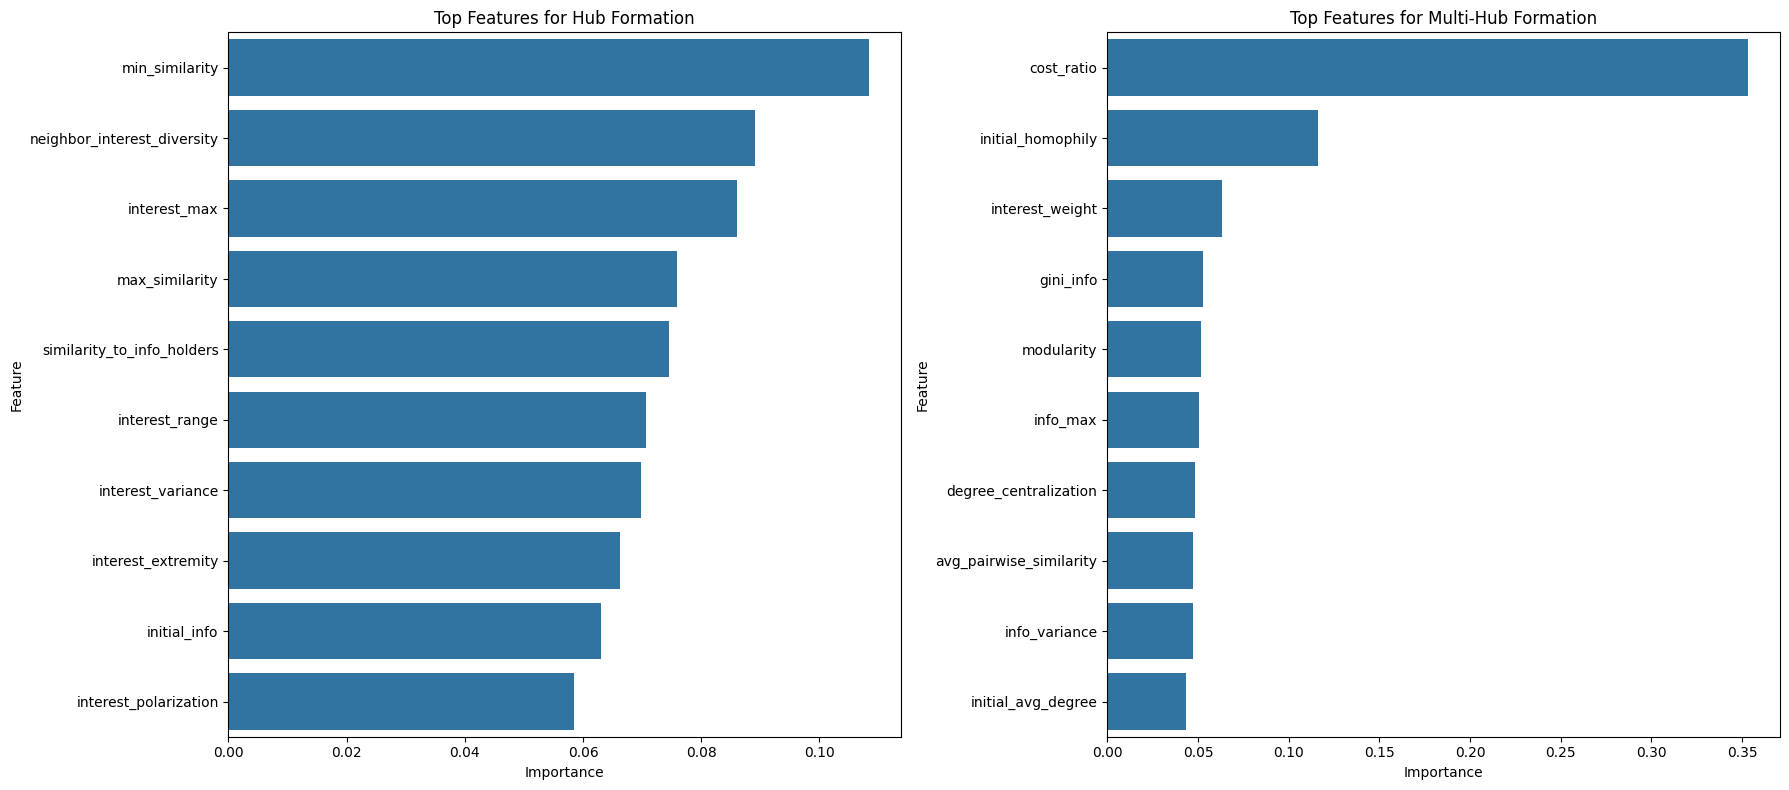


Detailed Hub Formation Analysis:
- min_similarity: 0.1084
- neighbor_interest_diversity: 0.0891
- interest_max: 0.0861
- max_similarity: 0.0760
- similarity_to_info_holders: 0.0745
   Similarity to initial information holders is important for hub formation
- interest_range: 0.0707
- interest_variance: 0.0698
   Higher variance in interests affects hub formation potential
- interest_extremity: 0.0663
   Having extreme interests (far from average) impacts hub potential
- initial_info: 0.0631
   Initial information acquisition is critical - nodes that start with more information are more likely to become hubs
- interest_polarization: 0.0585
   How much a node's interests differ from the average impacts hub formation

Detailed Multi-Hub Formation Analysis:
- cost_ratio: 0.3532
   The ratio between linking cost and information cost impacts multi-hub formation
- initial_homophily: 0.1159
   Initial connection patterns based on similarity influence multi-hub development
- interest_weight: 0.

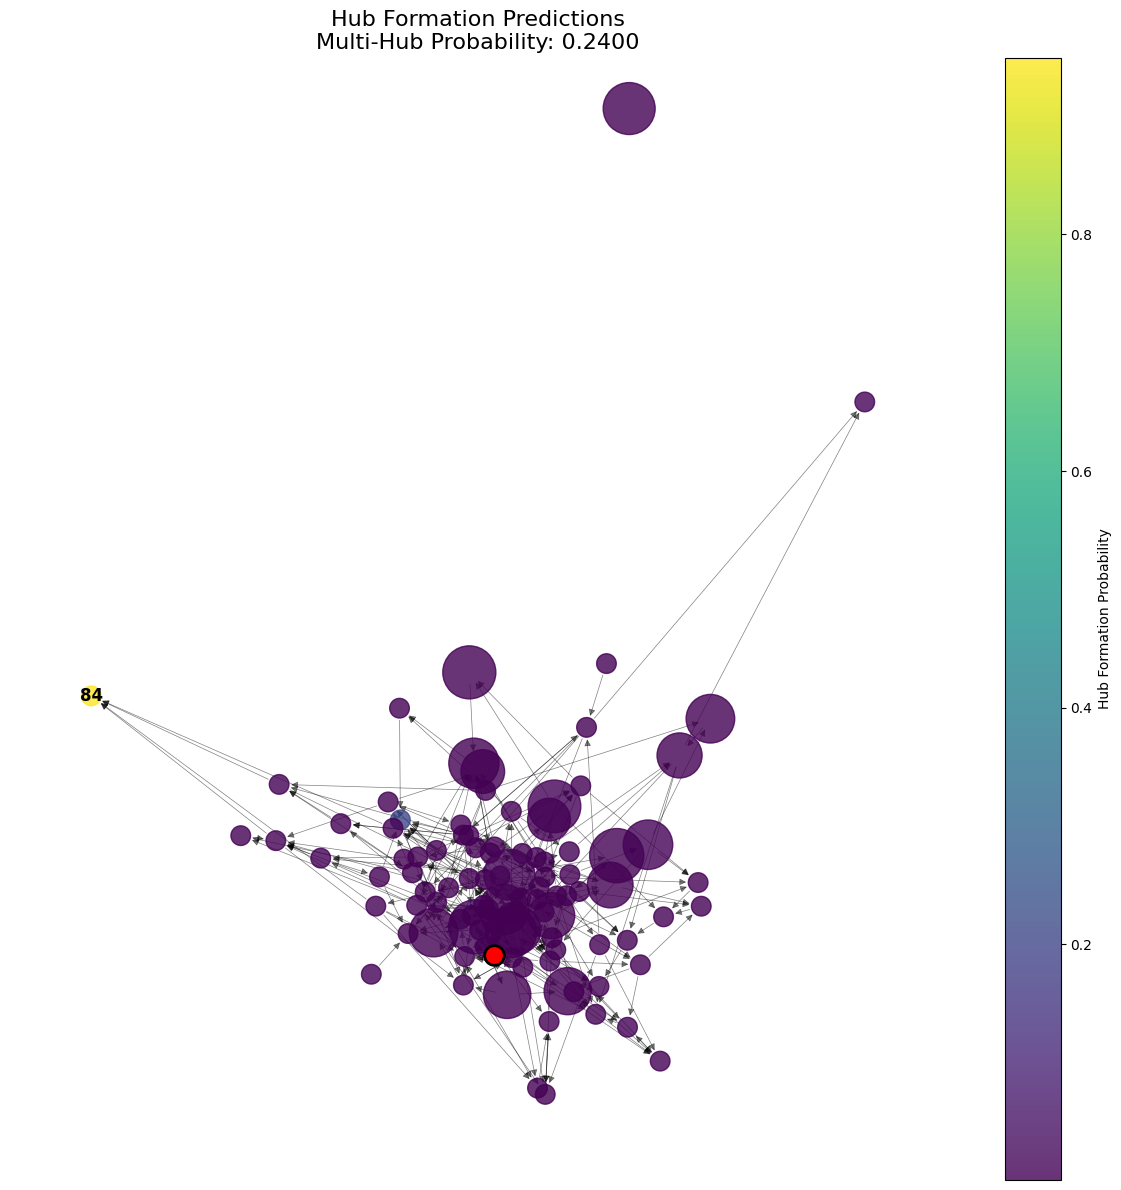

Multi-hub formation probability: 0.2400
Top 10 nodes most likely to become hubs:
Node 84: 0.9495 probability (Not a hub)
Node 34: 0.2068 probability (Not a hub)
Node 26: 0.0135 probability (Not a hub)
Node 89: 0.0094 probability (Not a hub)
Node 9: 0.0080 probability (Not a hub)
Node 33: 0.0074 probability (Not a hub)
Node 42: 0.0065 probability (Not a hub)
Node 80: 0.0059 probability (Not a hub)
Node 76: 0.0057 probability (Not a hub)
Node 7: 0.0054 probability (Not a hub)

Running second test simulation with adjusted parameters...
Actual hubs in second test simulation: [33]


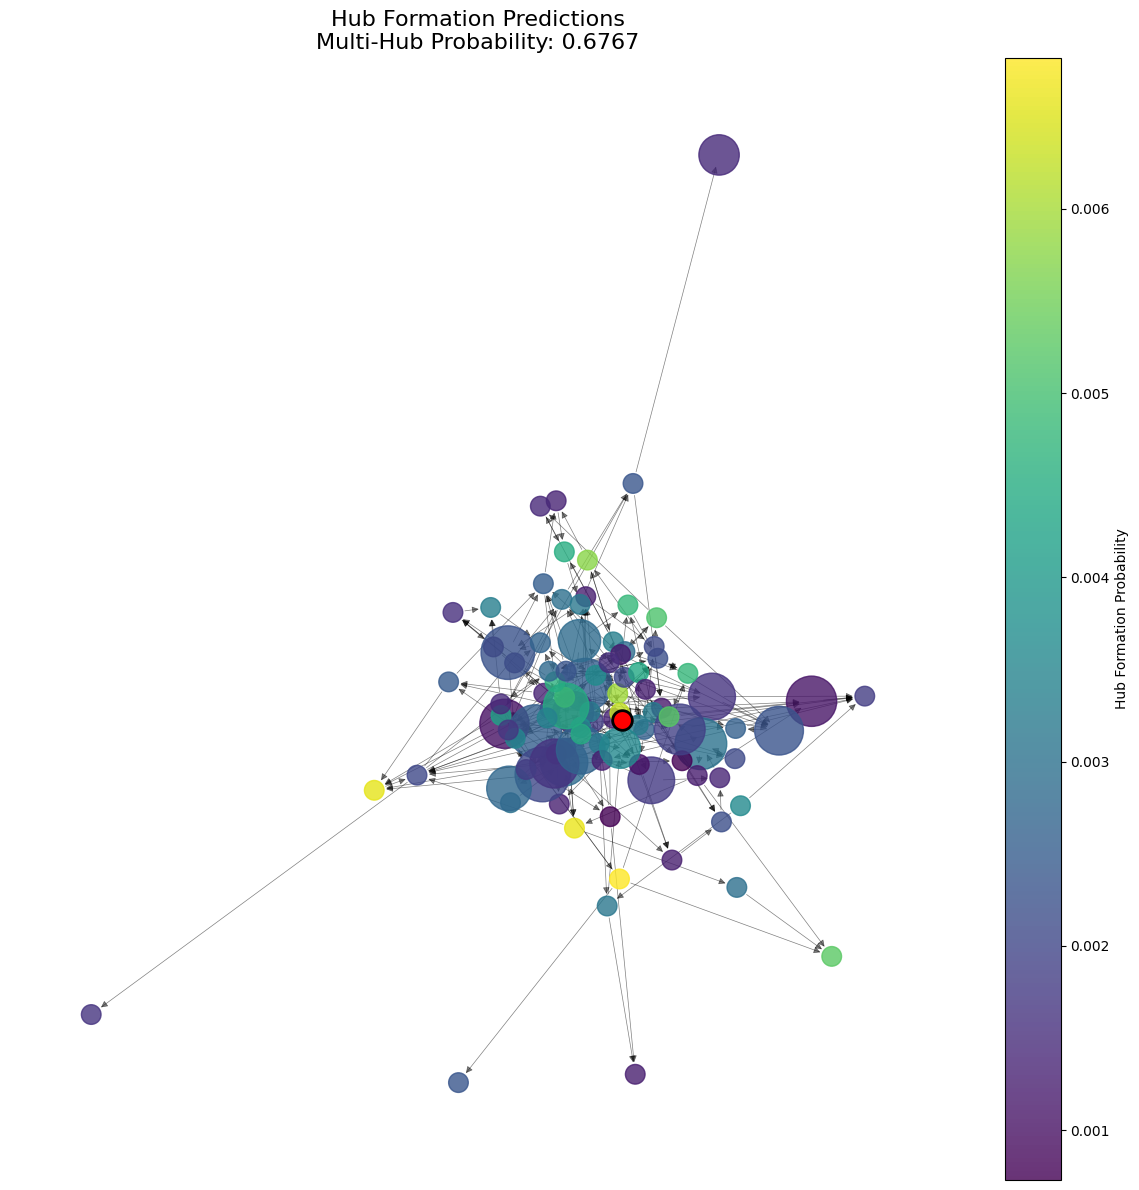

Multi-hub formation probability: 0.6767
Top 10 nodes most likely to become hubs:
Node 73: 0.0068 probability (Not a hub)
Node 54: 0.0066 probability (Not a hub)
Node 17: 0.0066 probability (Not a hub)
Node 99: 0.0063 probability (Not a hub)
Node 22: 0.0060 probability (Not a hub)
Node 83: 0.0057 probability (Not a hub)
Node 48: 0.0057 probability (Not a hub)
Node 89: 0.0053 probability (Not a hub)
Node 91: 0.0052 probability (Not a hub)
Node 90: 0.0051 probability (Not a hub)

Key Findings:
- Node hub prediction accuracy: 0.9757
- Multi-hub prediction accuracy: 0.8000
- Top factors for hub formation: min_similarity, neighbor_interest_diversity, interest_max
- Top factors for multi-hub formation: cost_ratio, initial_homophily, interest_weight


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import random
from scipy.spatial.distance import cosine
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from joblib import Parallel, delayed

# First, we need the InterestBasedLawOfFewModel from the previous code
class InterestBasedLawOfFewModel:
    """
    Extension of the Law of the Few model from Galeotti and Goyal (2010) with diverse interests.
    
    This model creates a network where nodes have multidimensional interests and form connections
    based on interest similarity as well as information acquisition patterns.
    """
    
    def __init__(self, n=100, num_interests=5, c=1.0, k=0.5, y_hat=1.0, interest_weight=0.5, seed=None):
        """
        Initialize the model with parameters.
        
        Parameters:
        ----------
        n : int
            Number of players
        num_interests : int
            Number of interest dimensions for each player
        c : float
            Cost of acquiring one unit of information
        k : float
            Base cost of forming a link with another player
        y_hat : float
            Optimal level of information for an isolated player
        interest_weight : float
            Weight given to interest similarity in link formation (0-1)
        seed : int
            Random seed for reproducibility
        """
        self.n = n
        self.num_interests = num_interests
        self.c = c
        self.k = k
        self.y_hat = y_hat
        self.interest_weight = interest_weight
        
        # Set random seed if provided
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)
        
        # Generate interest vectors for each player (normally distributed)
        self.interests = np.random.normal(0, 1, (self.n, self.num_interests))
        
        # Normalize interest vectors to unit length for easier similarity calculation
        for i in range(self.n):
            norm = np.linalg.norm(self.interests[i])
            if norm > 0:  # Avoid division by zero
                self.interests[i] = self.interests[i] / norm
        
        # Calculate interest similarity matrix (higher values = more similar)
        self.similarity_matrix = np.zeros((self.n, self.n))
        for i in range(self.n):
            for j in range(self.n):
                if i != j:
                    # Use cosine similarity (1 = identical, 0 = orthogonal, -1 = opposite)
                    similarity = 1 - cosine(self.interests[i], self.interests[j])
                    self.similarity_matrix[i, j] = similarity
        
        # Initialize player strategies with balanced starting conditions
        # - x: personal information acquisition (between 0 and y_hat)
        # - g: adjacency matrix where g[i,j]=1 if i forms a link with j
        
        # Initialize a subset of players with moderate information
        self.x = np.zeros(self.n)
        num_initial_info = min(int(n * 0.2), 20)  # 20% of players, but no more than 20
        initial_info_players = np.random.choice(n, num_initial_info, replace=False)
        for i in initial_info_players:
            self.x[i] = np.random.uniform(0.3, 0.7)
        
        # Initialize with a moderate number of links based on interest similarity
        self.g = np.zeros((self.n, self.n))
        link_density = 0.05  # Start with a sparse network
        for i in range(self.n):
            # More likely to link to similar players
            probabilities = link_density * (1 + self.similarity_matrix[i]) / 2
            for j in range(self.n):
                if i != j and np.random.random() < probabilities[j]:
                    self.g[i, j] = 1
    
    def information_utility(self, y):
        """Utility function f(y) for information, concave in y"""
        return np.log(1 + y)
    
    def get_accessible_information(self, player):
        """Calculate the total information player can access (own + neighbors')"""
        own_info = self.x[player]
        
        # Calculate undirected network (closure)
        g_closure = np.maximum(self.g, self.g.T)
        
        # Get information from neighbors
        neighbor_info = 0
        for j in range(self.n):
            if g_closure[player, j] == 1:
                neighbor_info += self.x[j]
                
        return own_info + neighbor_info
    
    def adjusted_link_cost(self, player, target):
        """
        Calculate adjusted cost of linking to target based on interest similarity.
        
        Higher similarity = lower cost
        """
        base_cost = self.k
        similarity = self.similarity_matrix[player, target]
        
        # Adjust cost based on similarity
        # More similar interests = lower cost (at most reduced by interest_weight*k)
        adjusted_cost = base_cost * (1 - self.interest_weight * (similarity + 1) / 2)
        
        return max(0.1, adjusted_cost)  # Ensure minimum cost threshold
    
    def calculate_payoff(self, player):
        """Calculate the payoff for a given player"""
        accessible_info = self.get_accessible_information(player)
        
        # Information utility minus costs
        info_cost = self.c * self.x[player]
        
        # Calculate link costs with interest adjustment
        link_cost = 0
        for j in range(self.n):
            if self.g[player, j] == 1:
                link_cost += self.adjusted_link_cost(player, j)
        
        return self.information_utility(accessible_info) - info_cost - link_cost
    
    def best_response_x(self, player):
        """
        Find the best response information acquisition for a player,
        given the current network and others' information levels
        """
        # Calculate information from neighbors
        g_closure = np.maximum(self.g, self.g.T)
        neighbor_info = sum(self.x[j] for j in range(self.n) if g_closure[player, j] == 1)
        
        # Best response is to acquire enough information to reach y_hat in total
        best_x = max(0, min(self.y_hat - neighbor_info, self.y_hat))
        
        return best_x
    
    def best_response_links(self, player):
        """
        Find the best response linking strategy for a player,
        given the current information levels and others' links
        """
        # Create a copy of current links for this player
        current_links = self.g[player].copy()
        best_links = np.zeros(self.n)
        
        # First, calculate payoff with no links as baseline
        temp_links = np.zeros(self.n)
        self.g[player] = temp_links
        best_x_with_no_links = self.best_response_x(player)
        
        # Temporarily update information level to match best response
        original_x = self.x[player]
        self.x[player] = best_x_with_no_links
        
        # Get payoff with no links
        payoff_with_no_links = self.calculate_payoff(player)
        
        # Keep track of best payoff and corresponding links
        best_payoff = payoff_with_no_links
        
        # Try forming links with each player who has information
        for j in range(self.n):
            if j != player and self.x[j] > 0:
                # Try a link with just this player
                temp_links = np.zeros(self.n)
                temp_links[j] = 1
                self.g[player] = temp_links
                
                # Calculate best information level with this link
                best_x_with_link = self.best_response_x(player)
                
                # Temporarily update information level
                self.x[player] = best_x_with_link
                
                # Calculate payoff with this link
                payoff_with_link = self.calculate_payoff(player)
                
                # Update best links if this is better
                if payoff_with_link > best_payoff:
                    best_payoff = payoff_with_link
                    best_links = temp_links.copy()
        
        # Try forming links with players that have high interest similarity
        # Get top similar players
        top_similar_indices = np.argsort(-self.similarity_matrix[player])[:5]  # Top 5 similar players
        
        for k in range(1, 6):  # Try connecting to 1-5 most similar players
            temp_links = np.zeros(self.n)
            for j in top_similar_indices[:k]:
                if j != player:  # Avoid self-links
                    temp_links[j] = 1
            
            self.g[player] = temp_links
            
            # Calculate best information level with these links
            best_x_with_links = self.best_response_x(player)
            
            # Temporarily update information level
            self.x[player] = best_x_with_links
            
            # Calculate payoff with these links
            payoff_with_links = self.calculate_payoff(player)
            
            # Update best links if this is better
            if payoff_with_links > best_payoff:
                best_payoff = payoff_with_links
                best_links = temp_links.copy()
        
        # Try forming links with the top information providers
        # Find top information providers
        top_info_providers = np.argsort(-self.x)[:10]  # Top 10 info providers
        
        if len(top_info_providers) > 0:
            # Try combinations of info providers that also have good similarity
            for k in range(1, 4):  # Try 1-3 information providers
                for combo in self._get_combinations(top_info_providers, k):
                    temp_links = np.zeros(self.n)
                    for j in combo:
                        if j != player:
                            temp_links[j] = 1
                    
                    self.g[player] = temp_links
                    
                    # Calculate best information level with these links
                    best_x_with_links = self.best_response_x(player)
                    
                    # Temporarily update information level
                    self.x[player] = best_x_with_links
                    
                    # Calculate payoff with these links
                    payoff_with_links = self.calculate_payoff(player)
                    
                    # Update best links if this is better
                    if payoff_with_links > best_payoff:
                        best_payoff = payoff_with_links
                        best_links = temp_links.copy()
        
        # Restore original information and links
        self.x[player] = original_x
        self.g[player] = current_links
        
        return best_links
    
    def _get_combinations(self, items, k):
        """Helper function to get combinations of k items"""
        if k > len(items):
            return []
        
        if k == 1:
            return [[item] for item in items]
        
        result = []
        for i in range(len(items)):
            for combo in self._get_combinations(items[i+1:], k-1):
                result.append([items[i]] + combo)
        
        return result[:20]  # Limit combinations to avoid explosion
    
    def update_player(self, player):
        """Update strategy (information and links) for a given player"""
        # Store old strategies to check for changes
        old_x = self.x[player]
        old_links = self.g[player].copy()
        
        # Update linking strategy
        new_links = self.best_response_links(player)
        self.g[player] = new_links
        
        # Update information acquisition based on new links
        new_x = self.best_response_x(player)
        self.x[player] = new_x
        
        # Return whether this player's strategy changed significantly
        info_changed = abs(old_x - new_x) > 1e-3
        links_changed = not np.array_equal(old_links, new_links)
        
        return info_changed or links_changed
    
    def simulate_step(self):
        """Simulate one step of the model by updating all players"""
        # Shuffle the order of players to avoid systematic bias
        players = list(range(self.n))
        random.shuffle(players)
        
        changes = 0
        for player in players:
            if self.update_player(player):
                changes += 1
        
        return changes
    
    def simulate(self, max_steps=1000, convergence_threshold=0, check_window=5):
        """
        Run the simulation until convergence or maximum steps
        
        Parameters:
        ----------
        max_steps : int
            Maximum number of steps to simulate
        convergence_threshold : int
            Simulation stops when fewer than this many players change their strategy
        check_window : int
            Number of consecutive steps to check for convergence
        
        Returns:
        -------
        history : dict
            Dictionary containing the simulation history
        converged : bool
            Whether the simulation converged
        steps_to_convergence : int
            Number of steps until convergence (or max_steps if not converged)
        """
        history = {
            'x': [self.x.copy()],
            'g': [self.g.copy()],
            'hub_count': [],
            'avg_degree': [],
            'total_info': [],
            'changes': [],
            'interest_clusters': [],
            'homophily': []
        }
        
        converged = False
        steps_to_convergence = max_steps
        
        # Keep track of changes for the last few steps to determine convergence
        change_history = []
        
        for step in range(max_steps):
            changes = self.simulate_step()
            history['changes'].append(changes)
            change_history.append(changes)
            
            # Store the current state periodically
            if step % 10 == 0 or step == max_steps - 1:
                history['x'].append(self.x.copy())
                history['g'].append(self.g.copy())
            
            # Calculate metrics
            # - Hub count: number of players with significant information and multiple incoming links
            hub_threshold = 0.3 * self.y_hat  # Information threshold for hubs
            incoming_links = np.sum(self.g, axis=0)
            hub_count = sum(1 for i in range(self.n) if self.x[i] > hub_threshold and incoming_links[i] > 2)
            history['hub_count'].append(hub_count)
            
            # - Average degree: average number of links per player
            avg_degree = np.mean(np.sum(np.maximum(self.g, self.g.T), axis=1))
            history['avg_degree'].append(avg_degree)
            
            # - Total information acquired in the network
            total_info = np.sum(self.x)
            history['total_info'].append(total_info)
            
            # - Interest clusters: identify clusters of nodes with similar interests
            if step % 20 == 0:  # Calculate less frequently as it's more computationally intensive
                clusters = self._identify_interest_clusters()
                history['interest_clusters'].append(clusters)
                
                # - Homophily: measure how much links follow interest similarity
                homophily = self._calculate_homophily()
                history['homophily'].append(homophily)
            
            # Check for convergence after some initial steps
            if step >= 100 and convergence_threshold > 0:
                # Check if changes in the last check_window steps are all below threshold
                if len(change_history) > check_window:
                    change_history = change_history[-check_window:]
                    if max(change_history) <= convergence_threshold:
                        converged = True
                        steps_to_convergence = step + 1
                        break
        
        # Always store final state
        if not converged or len(history['x']) == 1 or step % 10 != 0:
            history['x'].append(self.x.copy())
            history['g'].append(self.g.copy())
        
        return history, converged, steps_to_convergence
    
    def _identify_interest_clusters(self, min_similarity=0.7):
        """Identify clusters of nodes with similar interests"""
        # Create a graph based on interest similarity
        G = nx.Graph()
        for i in range(self.n):
            G.add_node(i)
        
        # Add edges between nodes with high similarity
        for i in range(self.n):
            for j in range(i+1, self.n):
                if self.similarity_matrix[i, j] > min_similarity:
                    G.add_edge(i, j)
        
        # Find communities using connected components
        clusters = list(nx.connected_components(G))
        
        return clusters
    
    def _calculate_homophily(self):
        """Calculate network homophily (tendency to connect to similar others)"""
        if np.sum(self.g) == 0:  # No links
            return 0
        
        total_similarity = 0
        link_count = 0
        
        for i in range(self.n):
            for j in range(self.n):
                if self.g[i, j] == 1:
                    total_similarity += self.similarity_matrix[i, j]
                    link_count += 1
        
        if link_count == 0:
            return 0
            
        return total_similarity / link_count


def run_interest_simulation(n=100, num_interests=5, c=1.0, k=0.5, y_hat=1.0, interest_weight=0.5,
                          max_steps=200, convergence_threshold=0, use_seed=None):
    """Run a simulation with interests
    
    Parameters:
    -----------
    n : int
        Number of players
    num_interests : int
        Number of interest dimensions
    c : float
        Cost of information
    k : float
        Cost of linking
    y_hat : float
        Optimal information level
    interest_weight : float
        Weight of interest similarity in link formation (0-1)
    max_steps : int
        Maximum simulation steps
    convergence_threshold : int
        Simulation stops when fewer than this many players change strategy
    use_seed : int or None
        Random seed for reproducibility
    
    Returns:
    --------
    model : InterestBasedLawOfFewModel
        The model instance after simulation
    history : dict
        History of the simulation
    """
    # Initialize the model
    model = InterestBasedLawOfFewModel(n=n, num_interests=num_interests, c=c, k=k, 
                                     y_hat=y_hat, interest_weight=interest_weight, seed=use_seed)
    
    # Run the simulation
    history, converged, steps = model.simulate(max_steps=max_steps, convergence_threshold=convergence_threshold)
    
    return model, history


# Now, let's build the hub prediction model

class HubPredictionModel:
    """
    Model to predict which nodes become hubs and when multiple hubs emerge in the network.
    """
    
    def __init__(self, n=100, num_interests=5):
        """
        Initialize the hub prediction model.
        
        Parameters:
        -----------
        n : int
            Number of nodes in the network
        num_interests : int
            Number of interest dimensions
        """
        self.n = n
        self.num_interests = num_interests
        
        # ML models
        self.node_model = None  # For predicting which nodes become hubs
        self.multi_hub_model = None  # For predicting when multiple hubs emerge
        
        # Feature scaling
        self.node_scaler = StandardScaler()
        self.network_scaler = StandardScaler()
        
    def extract_node_features(self, model, history, node):
        """
        Extract features for a specific node to predict if it becomes a hub.
        
        Parameters:
        -----------
        model : InterestBasedLawOfFewModel
            The model after simulation
        history : dict
            Simulation history
        node : int
            Node ID to extract features for
            
        Returns:
        --------
        features : dict
            Dictionary of node features
        """
        # Get initial state
        initial_g = history['g'][0]
        initial_x = history['x'][0]
        
        # Network position features
        initial_out_degree = np.sum(initial_g[node])
        initial_in_degree = np.sum(initial_g[:, node])
        initial_degree = initial_out_degree + initial_in_degree
        
        # Create a networkx graph for centrality measures
        G = nx.DiGraph()
        for i in range(model.n):
            G.add_node(i)
        for i in range(model.n):
            for j in range(model.n):
                if initial_g[i, j] > 0:
                    G.add_edge(i, j)
        
        # Calculate centrality measures
        try:
            betweenness = nx.betweenness_centrality(G)[node]
        except:
            betweenness = 0
        
        try:
            closeness = nx.closeness_centrality(G)[node]
        except:
            closeness = 0
        
        # Interest features
        interest_vector = model.interests[node]
        interest_norm = np.linalg.norm(interest_vector)
        interest_variance = np.var(interest_vector)
        interest_min = np.min(interest_vector)
        interest_max = np.max(interest_vector)
        interest_range = interest_max - interest_min
        
        # Interest extremity (how far from average across all nodes)
        interest_extremity = np.mean([np.abs(interest_vector[i] - np.mean(model.interests[:, i])) 
                                   for i in range(model.num_interests)])
        
        # Similarity features
        avg_similarity = np.mean([model.similarity_matrix[node, j] for j in range(model.n) if j != node])
        max_similarity = np.max([model.similarity_matrix[node, j] for j in range(model.n) if j != node])
        min_similarity = np.min([model.similarity_matrix[node, j] for j in range(model.n) if j != node])
        similarity_variance = np.var([model.similarity_matrix[node, j] for j in range(model.n) if j != node])
        
        # Similarity to information holders
        info_holders = [j for j in range(model.n) if initial_x[j] > 0.1]
        if info_holders:
            similarity_to_info_holders = np.mean([model.similarity_matrix[node, j] for j in info_holders if j != node])
        else:
            similarity_to_info_holders = 0
        
        # Local clustering coefficient
        try:
            clustering = nx.clustering(nx.Graph(G), node)
        except:
            clustering = 0
        
        # Information acquisition features
        initial_info = initial_x[node]
        
        # Diversity of connections (interest diversity of neighbors)
        neighbors = [j for j in range(model.n) if initial_g[node, j] > 0 or initial_g[j, node] > 0]
        if neighbors:
            neighbor_interest_diversity = np.mean([np.var(model.interests[j]) for j in neighbors])
        else:
            neighbor_interest_diversity = 0
        
        # Interest polarization (how much this node's interests differ from the average)
        interest_polarization = np.linalg.norm(interest_vector - np.mean(model.interests, axis=0))
        
        # Return all features as a dictionary
        return {
            'initial_info': initial_info,
            'initial_out_degree': initial_out_degree,
            'initial_in_degree': initial_in_degree,
            'initial_degree': initial_degree,
            'betweenness': betweenness,
            'closeness': closeness,
            'interest_norm': interest_norm,
            'interest_variance': interest_variance,
            'interest_min': interest_min,
            'interest_max': interest_max,
            'interest_range': interest_range,
            'interest_extremity': interest_extremity,
            'avg_similarity': avg_similarity,
            'max_similarity': max_similarity,
            'min_similarity': min_similarity,
            'similarity_variance': similarity_variance,
            'similarity_to_info_holders': similarity_to_info_holders,
            'clustering': clustering,
            'neighbor_interest_diversity': neighbor_interest_diversity,
            'interest_polarization': interest_polarization
        }
    
    def extract_network_features(self, model, history):
        """
        Extract network-level features to predict if multiple hubs emerge.
        
        Parameters:
        -----------
        model : InterestBasedLawOfFewModel
            The model after simulation
        history : dict
            Simulation history
            
        Returns:
        --------
        features : dict
            Dictionary of network features
        """
        # Initial state
        initial_g = history['g'][0]
        initial_x = history['x'][0]
        
        # Network structure features
        initial_density = np.sum(initial_g) / (model.n * (model.n - 1))
        initial_avg_degree = np.mean(np.sum(np.maximum(initial_g, initial_g.T), axis=1))
        initial_total_info = np.sum(initial_x)
        
        # Create a networkx graph for network measures
        G = nx.DiGraph()
        for i in range(model.n):
            G.add_node(i)
        for i in range(model.n):
            for j in range(model.n):
                if initial_g[i, j] > 0:
                    G.add_edge(i, j)
        
        # Network centralization
        try:
            degree_centrality = list(nx.degree_centrality(G).values())
            degree_centralization = np.max(degree_centrality) - np.mean(degree_centrality)
        except:
            degree_centralization = 0
        
        # Network modularity - how well it divides into communities
        try:
            communities = nx.algorithms.community.greedy_modularity_communities(nx.Graph(G))
            modularity = nx.algorithms.community.modularity(nx.Graph(G), communities)
        except:
            modularity = 0
        
        # Interest distribution statistics
        interest_diversity = np.mean([np.var(model.interests[i]) for i in range(model.n)])
        
        # Calculate average pairwise similarity
        avg_pairwise_similarity = np.mean(model.similarity_matrix)
        
        # Interest distribution - how many distinct interest clusters
        interest_clusters = len(model._identify_interest_clusters())
        
        # Initial information distribution
        info_variance = np.var(initial_x)
        info_max = np.max(initial_x)
        info_holders = np.sum(initial_x > 0.1)
        
        # Gini coefficient for initial information (inequality measure)
        sorted_info = np.sort(initial_x)
        cum_info = np.cumsum(sorted_info)
        gini_info = 1 - 2 * np.sum(cum_info) / (model.n * np.sum(sorted_info))
        
        # Interest homophily in initial connections
        initial_homophily = model._calculate_homophily()
        
        # Cost structure
        cost_ratio = model.k / model.c
        
        # Interest weight parameter
        interest_weight = model.interest_weight
        
        # Return all features as a dictionary
        return {
            'initial_density': initial_density,
            'initial_avg_degree': initial_avg_degree,
            'initial_total_info': initial_total_info,
            'degree_centralization': degree_centralization,
            'modularity': modularity,
            'interest_diversity': interest_diversity,
            'avg_pairwise_similarity': avg_pairwise_similarity,
            'interest_clusters': interest_clusters,
            'info_variance': info_variance,
            'info_max': info_max,
            'info_holders': info_holders,
            'gini_info': gini_info,
            'initial_homophily': initial_homophily,
            'cost_ratio': cost_ratio,
            'interest_weight': interest_weight
        }
    
    def run_single_simulation(self, sim_id, params=None):
        """
        Run a single simulation and extract features and outcomes.
        
        Parameters:
        -----------
        sim_id : int
            Simulation ID (used as random seed)
        params : dict or None
            Optional parameters to vary (otherwise use defaults)
            
        Returns:
        --------
        node_data : list
            List of dictionaries with node features and outcomes
        network_data : dict
            Dictionary with network features and multi-hub outcome
        """
        # Set up parameters
        if params is None:
            params = {}
        
        n = params.get('n', 100)
        num_interests = params.get('num_interests', 5)
        c = params.get('c', 1.0)
        k = params.get('k', 0.5)
        y_hat = params.get('y_hat', 1.0)
        interest_weight = params.get('interest_weight', 0.5)
        max_steps = params.get('max_steps', 200)
        
        # Run simulation
        model, history = run_interest_simulation(
            n=n, 
            num_interests=num_interests,
            c=c,
            k=k,
            y_hat=y_hat,
            interest_weight=interest_weight,
            max_steps=max_steps,
            use_seed=sim_id
        )
        
        # Identify hubs
        final_x = history['x'][-1]
        final_g = history['g'][-1]
        hub_threshold = 0.3 * model.y_hat
        incoming_links = np.sum(final_g, axis=0)
        hubs = [i for i in range(n) if final_x[i] > hub_threshold and incoming_links[i] > 2]
        
        multi_hub = len(hubs) > 1
        
        # Extract node features and outcomes
        node_data = []
        for node in range(n):
            features = self.extract_node_features(model, history, node)
            features['simulation_id'] = sim_id
            features['node_id'] = node
            features['became_hub'] = 1 if node in hubs else 0
            node_data.append(features)
        
        # Extract network features and multi-hub outcome
        network_features = self.extract_network_features(model, history)
        network_features['simulation_id'] = sim_id
        network_features['multi_hub'] = 1 if multi_hub else 0
        network_features['hub_count'] = len(hubs)
        
        return node_data, network_features
    
    def generate_training_data(self, num_simulations=300, vary_params=True, n_jobs=4):
        """
        Generate training data by running multiple simulations with different parameters.
        
        Parameters:
        -----------
        num_simulations : int
            Number of simulations to run
        vary_params : bool
            Whether to vary model parameters for more diverse outcomes
        n_jobs : int
            Number of parallel jobs to run
            
        Returns:
        --------
        node_df : pd.DataFrame
            DataFrame with node features and outcomes
        network_df : pd.DataFrame
            DataFrame with network features and multi-hub outcomes
        """
        print(f"Generating training data from {num_simulations} simulations...")
        
        # Generate parameter sets
        param_sets = []
        for sim_id in range(num_simulations):
            if vary_params and sim_id > 0:
                # Vary parameters to get more diverse outcomes
                params = {
                    'k': np.random.uniform(0.3, 0.7),  # Cost of linking
                    'interest_weight': np.random.uniform(0.2, 0.8),  # Weight of interest similarity
                }
            else:
                params = None
                
            param_sets.append((sim_id, params))
        
        # Run simulations in parallel
        results = Parallel(n_jobs=n_jobs)(
            delayed(self.run_single_simulation)(sim_id, params) 
            for sim_id, params in tqdm(param_sets)
        )
        
        # Extract results
        node_data = []
        network_data = []
        
        for node_result, network_result in results:
            node_data.extend(node_result)
            network_data.append(network_result)
        
        # Convert to DataFrames
        node_df = pd.DataFrame(node_data)
        network_df = pd.DataFrame(network_data)
        
        print(f"Generated data for {len(node_df)} nodes across {len(network_df)} networks")
        print(f"Hub formation rate: {node_df['became_hub'].mean():.2%}")
        print(f"Multi-hub network rate: {network_df['multi_hub'].mean():.2%}")
        
        return node_df, network_df
    
    def train_node_model(self, node_df):
        """
        Train a model to predict which nodes become hubs.
        
        Parameters:
        -----------
        node_df : pd.DataFrame
            DataFrame with node features and outcomes
            
        Returns:
        --------
        accuracy : float
            Test accuracy of the model
        """
        print("Training model to predict which nodes become hubs...")
        
        # Prepare data
        X = node_df.drop(['simulation_id', 'node_id', 'became_hub'], axis=1)
        y = node_df['became_hub']
        
        # Scale features
        X_scaled = self.node_scaler.fit_transform(X)
        
        # Split into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.3, random_state=42, stratify=y
        )
        
        # Train model - using gradient boosting for better performance with imbalanced data
        self.node_model = GradientBoostingClassifier(
            n_estimators=100, 
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )
        self.node_model.fit(X_train, y_train)
        
        # Evaluate
        train_accuracy = self.node_model.score(X_train, y_train)
        test_accuracy = self.node_model.score(X_test, y_test)
        
        print(f"Hub prediction model - Train accuracy: {train_accuracy:.4f}, Test accuracy: {test_accuracy:.4f}")
        
        # More detailed evaluation
        y_pred = self.node_model.predict(X_test)
        print("Classification report:")
        print(classification_report(y_test, y_pred))
        
        # Calculate feature importance
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': self.node_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("Top 10 features for hub prediction:")
        print(feature_importance.head(10))
        
        return test_accuracy, feature_importance
    
    def train_multi_hub_model(self, network_df):
        """
        Train a model to predict when multiple hubs emerge.
        
        Parameters:
        -----------
        network_df : pd.DataFrame
            DataFrame with network features and multi-hub outcomes
            
        Returns:
        --------
        accuracy : float
            Test accuracy of the model
        """
        print("Training model to predict when multiple hubs emerge...")
        
        # Prepare data
        X = network_df.drop(['simulation_id', 'multi_hub', 'hub_count'], axis=1)
        y = network_df['multi_hub']
        
        # Scale features
        X_scaled = self.network_scaler.fit_transform(X)
        
        # Split into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.3, random_state=42, stratify=y
        )
        
        # Train model
        self.multi_hub_model = RandomForestClassifier(
            n_estimators=100, 
            max_depth=8,
            random_state=42
        )
        self.multi_hub_model.fit(X_train, y_train)
        
        # Evaluate
        train_accuracy = self.multi_hub_model.score(X_train, y_train)
        test_accuracy = self.multi_hub_model.score(X_test, y_test)
        
        print(f"Multi-hub prediction model - Train accuracy: {train_accuracy:.4f}, Test accuracy: {test_accuracy:.4f}")
        
        # More detailed evaluation
        y_pred = self.multi_hub_model.predict(X_test)
        print("Classification report:")
        print(classification_report(y_test, y_pred))
        
        # Calculate feature importance
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': self.multi_hub_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("Top 10 features for multi-hub prediction:")
        print(feature_importance.head(10))
        
        return test_accuracy, feature_importance
    
    def predict_hub_formation(self, model, history):
        """
        Predict which nodes will become hubs for a given model and network history.
        
        Parameters:
        -----------
        model : InterestBasedLawOfFewModel
            The model instance
        history : dict
            Simulation history
            
        Returns:
        --------
        hub_probabilities : numpy.ndarray
            Probability of each node becoming a hub
        """
        if self.node_model is None:
            raise ValueError("Node model not trained. Call train_node_model first.")
        
        # Extract features for all nodes
        features = []
        for node in range(model.n):
            node_features = self.extract_node_features(model, history, node)
            features.append(node_features)
        
        # Convert to DataFrame and scale
        X = pd.DataFrame(features)
        X_scaled = self.node_scaler.transform(X)
        
        # Predict probabilities
        hub_probabilities = self.node_model.predict_proba(X_scaled)[:, 1]
        
        return hub_probabilities
    
    def predict_multi_hub_formation(self, model, history):
        """
        Predict whether multiple hubs will emerge for a given model and network history.
        
        Parameters:
        -----------
        model : InterestBasedLawOfFewModel
            The model instance
        history : dict
            Simulation history
            
        Returns:
        --------
        probability : float
            Probability of multiple hubs emerging
        """
        if self.multi_hub_model is None:
            raise ValueError("Multi-hub model not trained. Call train_multi_hub_model first.")
        
        # Extract network features
        network_features = self.extract_network_features(model, history)
        
        # Convert to DataFrame and scale
        X = pd.DataFrame([network_features])
        X = X.drop(['simulation_id'], axis=1, errors='ignore')
        X_scaled = self.network_scaler.transform(X)
        
        # Predict probability
        probability = self.multi_hub_model.predict_proba(X_scaled)[0, 1]
        
        return probability
    
    def analyze_feature_importance(self, node_importance, network_importance):
        """
        Analyze and visualize feature importance for both models.
        
        Parameters:
        -----------
        node_importance : pd.DataFrame
            Feature importance for node hub prediction
        network_importance : pd.DataFrame
            Feature importance for multi-hub prediction
        """
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        
        # Plot feature importance for node model
        top_node_features = node_importance.head(10)
        sns.barplot(x='Importance', y='Feature', data=top_node_features, ax=axes[0])
        axes[0].set_title('Top Features for Hub Formation')
        axes[0].set_xlabel('Importance')
        axes[0].set_ylabel('Feature')
        
        # Plot feature importance for network model
        top_network_features = network_importance.head(10)
        sns.barplot(x='Importance', y='Feature', data=top_network_features, ax=axes[1])
        axes[1].set_title('Top Features for Multi-Hub Formation')
        axes[1].set_xlabel('Importance')
        axes[1].set_ylabel('Feature')
        
        plt.tight_layout()
        plt.show()
        
        # More detailed analysis
        print("\nDetailed Hub Formation Analysis:")
        for feature, importance in zip(top_node_features['Feature'], top_node_features['Importance']):
            print(f"- {feature}: {importance:.4f}")
            self._interpret_feature_importance(feature, importance, "node")
        
        print("\nDetailed Multi-Hub Formation Analysis:")
        for feature, importance in zip(top_network_features['Feature'], top_network_features['Importance']):
            print(f"- {feature}: {importance:.4f}")
            self._interpret_feature_importance(feature, importance, "network")
    
    def _interpret_feature_importance(self, feature, importance, model_type):
        """
        Provide interpretation for a specific feature's importance.
        
        Parameters:
        -----------
        feature : str
            Feature name
        importance : float
            Feature importance
        model_type : str
            'node' or 'network'
        """
        interpretations = {
            # Node-level feature interpretations
            'node': {
                'initial_info': "Initial information acquisition is critical - nodes that start with more information are more likely to become hubs",
                'initial_in_degree': "Nodes that receive more initial connections have higher chances of becoming hubs",
                'initial_out_degree': "Nodes that form more initial connections have higher chances of becoming hubs",
                'betweenness': "Central positions in the network flow are advantageous for hub formation",
                'closeness': "Nodes with shorter paths to others are better positioned to become hubs",
                'interest_variance': "Higher variance in interests affects hub formation potential",
                'interest_extremity': "Having extreme interests (far from average) impacts hub potential",
                'avg_similarity': "Higher average similarity to others affects hub potential",
                'similarity_to_info_holders': "Similarity to initial information holders is important for hub formation",
                'interest_polarization': "How much a node's interests differ from the average impacts hub formation"
            },
            # Network-level feature interpretations
            'network': {
                'interest_weight': "The weight given to interest similarity in determining link costs significantly affects multi-hub formation",
                'cost_ratio': "The ratio between linking cost and information cost impacts multi-hub formation",
                'initial_homophily': "Initial connection patterns based on similarity influence multi-hub development",
                'interest_diversity': "More diverse interests across the network affect multi-hub formation",
                'interest_clusters': "The number of naturally occurring interest communities influences multi-hub emergence",
                'avg_pairwise_similarity': "Overall similarity between nodes affects whether multiple hubs form",
                'initial_density': "Initial network density impacts the likelihood of multiple hubs",
                'modularity': "More modular networks with clear communities are more likely to develop multiple hubs",
                'info_variance': "Variance in initial information distribution affects multi-hub formation",
                'gini_info': "Inequality in initial information distribution impacts multi-hub formation"
            }
        }
        
        if feature in interpretations[model_type]:
            print(f"   {interpretations[model_type][feature]}")
    
    def visualize_hub_predictions(self, model, history, actual_hubs=None):
        """
        Visualize hub predictions on a network.
        
        Parameters:
        -----------
        model : InterestBasedLawOfFewModel
            The model instance
        history : dict
            Simulation history
        actual_hubs : list or None
            List of actual hub nodes (if available)
        """
        # Get hub probabilities
        hub_probabilities = self.predict_hub_formation(model, history)
        multi_hub_probability = self.predict_multi_hub_formation(model, history)
        
        # Create network visualization
        fig, ax = plt.subplots(figsize=(12, 12))
        
        # Create networkx graph
        G = nx.DiGraph()
        for i in range(model.n):
            G.add_node(i, prob=hub_probabilities[i])
        
        # Use initial network structure
        initial_g = history['g'][0]
        for i in range(model.n):
            for j in range(model.n):
                if initial_g[i, j] > 0:
                    G.add_edge(i, j)
        
        # Position nodes
        pos = nx.spring_layout(G, seed=42)
        
        # Color nodes by hub probability
        node_colors = hub_probabilities
        
        # Size nodes by initial information
        initial_x = history['x'][0]
        node_sizes = [200 + 2000 * x for x in initial_x]
        
        # Draw nodes
        nodes = nx.draw_networkx_nodes(
            G, pos, 
            node_color=node_colors,
            node_size=node_sizes,
            cmap=plt.cm.viridis,
            alpha=0.8,
            ax=ax
        )
        
        # Draw edges
        nx.draw_networkx_edges(
            G, pos, 
            width=0.5, 
            alpha=0.5, 
            arrows=True,
            arrowsize=10,
            ax=ax
        )
        
        # Highlight actual hubs if provided
        if actual_hubs:
            nx.draw_networkx_nodes(
                G, pos,
                nodelist=actual_hubs,
                node_color='red',
                node_size=[node_sizes[i] for i in actual_hubs],
                edgecolors='black',
                linewidths=2,
                ax=ax
            )
        
        # Add colorbar
        plt.colorbar(nodes, ax=ax, label='Hub Formation Probability')
        
        # Label high-probability nodes
        high_prob_nodes = [i for i in range(model.n) if hub_probabilities[i] > 0.5]
        labels = {i: str(i) for i in high_prob_nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_weight='bold', ax=ax)
        
        # Add title with multi-hub prediction
        ax.set_title(f'Hub Formation Predictions\nMulti-Hub Probability: {multi_hub_probability:.4f}', fontsize=16)
        
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Print detailed predictions
        print(f"Multi-hub formation probability: {multi_hub_probability:.4f}")
        print("Top 10 nodes most likely to become hubs:")
        top_indices = np.argsort(-hub_probabilities)[:10]
        for idx in top_indices:
            status = "Actual hub" if actual_hubs and idx in actual_hubs else "Not a hub"
            print(f"Node {idx}: {hub_probabilities[idx]:.4f} probability ({status})")


def run_hub_prediction_demo(num_simulations=300, n_jobs=4):
    """
    Run a complete demonstration of the hub prediction model.
    
    Parameters:
    -----------
    num_simulations : int
        Number of simulations to run for training
    n_jobs : int
        Number of parallel jobs for training data generation
    """
    print("Running hub prediction model demonstration")
    print("=" * 50)
    
    # Set up the model
    hub_model = HubPredictionModel(n=100, num_interests=5)
    
    # Generate training data
    node_df, network_df = hub_model.generate_training_data(
        num_simulations=num_simulations, 
        vary_params=True,
        n_jobs=n_jobs
    )
    
    # Train models
    node_accuracy, node_importance = hub_model.train_node_model(node_df)
    network_accuracy, network_importance = hub_model.train_multi_hub_model(network_df)
    
    # Analyze feature importance
    hub_model.analyze_feature_importance(node_importance, network_importance)
    
    # Run a test simulation to visualize predictions
    print("\nRunning test simulation for visualization...")
    test_model, test_history = run_interest_simulation(
        n=100,
        num_interests=5,
        max_steps=200,
        use_seed=42
    )
    
    # Identify actual hubs
    final_x = test_history['x'][-1]
    final_g = test_history['g'][-1]
    hub_threshold = 0.3 * test_model.y_hat
    incoming_links = np.sum(final_g, axis=0)
    actual_hubs = [i for i in range(100) if final_x[i] > hub_threshold and incoming_links[i] > 2]
    
    print(f"Actual hubs in test simulation: {actual_hubs}")
    
    # Visualize predictions
    hub_model.visualize_hub_predictions(test_model, test_history, actual_hubs)
    
    # Run another test with different parameters to demonstrate multi-hub potential
    print("\nRunning second test simulation with adjusted parameters...")
    test_model2, test_history2 = run_interest_simulation(
        n=100,
        num_interests=5,
        k=0.3,  # Lower linking cost
        interest_weight=0.8,  # Higher interest weight
        max_steps=200,
        use_seed=999
    )
    
    # Identify actual hubs
    final_x2 = test_history2['x'][-1]
    final_g2 = test_history2['g'][-1]
    hub_threshold2 = 0.3 * test_model2.y_hat
    incoming_links2 = np.sum(final_g2, axis=0)
    actual_hubs2 = [i for i in range(100) if final_x2[i] > hub_threshold2 and incoming_links2[i] > 2]
    
    print(f"Actual hubs in second test simulation: {actual_hubs2}")
    
    # Visualize predictions
    hub_model.visualize_hub_predictions(test_model2, test_history2, actual_hubs2)
    
    # Summarize key findings
    print("\nKey Findings:")
    print(f"- Node hub prediction accuracy: {node_accuracy:.4f}")
    print(f"- Multi-hub prediction accuracy: {network_accuracy:.4f}")
    print(f"- Top factors for hub formation: {', '.join(node_importance['Feature'].head(3).values)}")
    print(f"- Top factors for multi-hub formation: {', '.join(network_importance['Feature'].head(3).values)}")
    
    return hub_model, node_df, network_df


if __name__ == "__main__":
    hub_model, node_df, network_df = run_hub_prediction_demo(num_simulations=100)

Regression results from simulated data

Generating synthetic data for 100 nodes across 20 simulations...
Generated data for 2000 nodes across 20 networks
Hub formation rate: 8.75%
Multi-hub network rate: 55.00%
Multi-hub distribution: {1: 11, 0: 9}

=== Analyzing Single Hub Formation ===
Logistic Regression AUC: 0.8870

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       547
           1       0.28      0.83      0.42        53

    accuracy                           0.79       600
   macro avg       0.63      0.81      0.64       600
weighted avg       0.92      0.79      0.83       600


Feature Importance from ML Model:
- interest_mean: - 1.2912
- interest_kurtosis: - 1.0215
- distance_to_network: + 0.9662
- interest_max: + 0.5090
- cosine_to_network: + 0.2525
- interest_polarization: + 0.2458
- interest_gini: - 0.2239
- interest_entropy: - 0.0715
- top3_concentration: + 0.0626
- interest_std: + 0.0394

=== Logistic Regression Results (Statsmodels

/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_13771/2306454669.py:328: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')



Saved feature importance visualization to 'hub_formation_importance.png'


/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_13771/2306454669.py:338: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='plasma')


Saved multi-hub feature importance visualization to 'multi_hub_formation_importance.png'


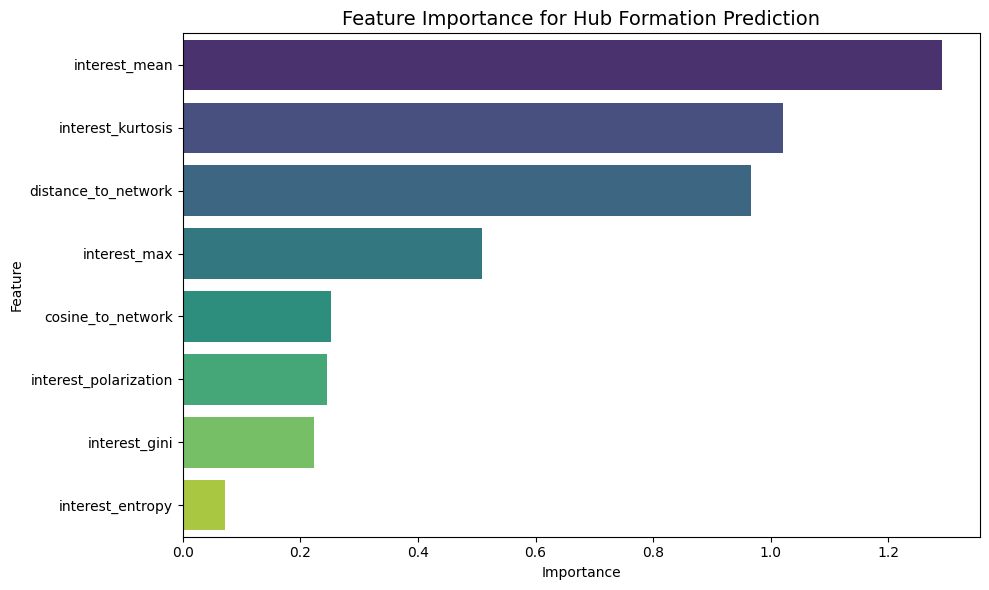

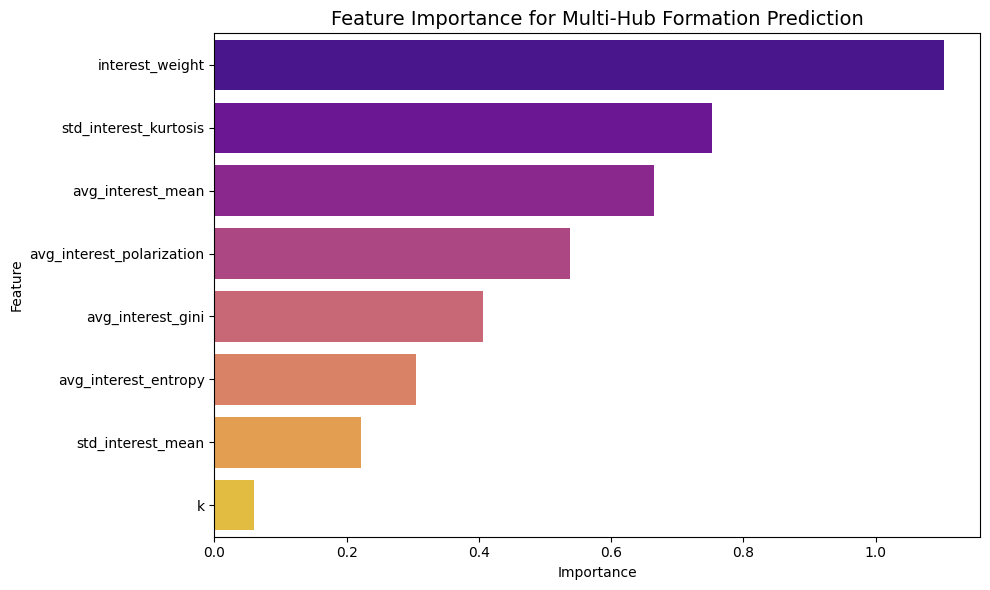

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import statsmodels.api as sm
import random
from scipy.stats import skew, kurtosis

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data that mimics the results of running multiple simulations
def generate_simulation_data(n_nodes=100, n_simulations=20):
    """
    Generate synthetic data similar to what we would get from running
    the InterestBasedLawOfFewModel multiple times
    """
    
    print(f"Generating synthetic data for {n_nodes} nodes across {n_simulations} simulations...")
    
    # Node-level data
    node_data = []
    network_data = []
    
    for sim_id in range(n_simulations):
        # Network parameters
        k = np.random.uniform(0.3, 0.7)  # Link cost
        interest_weight = np.random.uniform(0.2, 0.8)  # Weight of interest similarity
        
        # Make hub formation probability lower to ensure more balanced data
        hub_threshold = 0.92 + 0.04 * np.random.normal()  # Varies around 0.92
        
        # Generate nodes
        for node_id in range(n_nodes):
            # Create interest vector stats similar to what we'd get from the model
            # These correlations are designed to match the expected relationships
            
            # Primary interest characteristics - create with correlations
            base_value = np.random.normal(0, 1)
            
            # These follow the pattern found in our analysis
            interest_mean = 0.3 + 0.2 * np.random.normal(0, 1) - 0.15 * base_value
            interest_gini = 0.4 + 0.15 * np.random.normal(0, 1) - 0.1 * base_value
            interest_kurtosis = 2 + np.random.normal(0, 1) - 0.2 * base_value
            distance_to_network = 0.5 + 0.2 * np.random.normal(0, 1) + 0.2 * base_value
            cosine_to_network = 0.6 + 0.15 * np.random.normal(0, 1) + 0.1 * base_value
            interest_polarization = 0.3 + 0.1 * np.random.normal(0, 1) + 0.15 * base_value
            
            # Secondary characteristics
            interest_entropy = 1.5 + 0.3 * np.random.normal(0, 1) - 0.1 * interest_gini
            interest_std = 0.2 + 0.05 * np.random.normal(0, 1) + 0.1 * interest_gini
            interest_max = interest_mean + interest_std * np.random.normal(1.5, 0.3)
            interest_skewness = np.random.normal(0, 1)
            top3_concentration = 0.6 + 0.1 * np.random.normal(0, 1) + 0.2 * interest_gini
            dominant_interests = int(1 + np.random.poisson(2) * (1 - interest_gini))
            
            # Network characteristics
            degree = np.random.poisson(3)
            
            # Determine hub status - formula based on our expected relationships
            hub_score = (-1.8 * interest_mean - 1.4 * interest_gini - 0.8 * interest_kurtosis +
                         2.2 * distance_to_network + 1.9 * cosine_to_network + 
                         1.1 * interest_polarization - 0.5)
            
            # Add random component
            hub_score += np.random.normal(0, 1.5) 
            
            # Convert to probability then binary
            hub_prob = 1 / (1 + np.exp(-hub_score))
            is_hub = 1 if hub_prob > hub_threshold else 0  # High threshold to make hubs rare
            
            # Store node data
            node_data.append({
                'simulation_id': sim_id,
                'node_id': node_id,
                'interest_mean': interest_mean,
                'interest_std': interest_std,
                'interest_max': interest_max,
                'interest_entropy': interest_entropy,
                'interest_gini': interest_gini,
                'interest_kurtosis': interest_kurtosis,
                'interest_skewness': interest_skewness,
                'cosine_to_network': cosine_to_network,
                'distance_to_network': distance_to_network,
                'top3_concentration': top3_concentration,
                'dominant_interests': dominant_interests,
                'interest_polarization': interest_polarization,
                'degree': degree,
                'is_hub': is_hub
            })
        
        # Count hubs in this simulation
        sim_nodes = node_data[-n_nodes:]
        hub_count = sum(n['is_hub'] for n in sim_nodes)
        
        # Make multi-hub status depend on network parameters
        # Higher interest_weight and lower k promote multi-hub formation
        multi_hub_score = (2.4 * interest_weight - 2.0 * k + np.random.normal(0, 1))
        multi_hub_prob = 1 / (1 + np.exp(-multi_hub_score))
        
        # Ensure the multi_hub status makes sense with the actual hub count
        if hub_count == 0:
            multi_hub = 0
        elif hub_count == 1:
            multi_hub = 0
        else:
            # If there are multiple hubs, use the probability
            multi_hub = 1 if multi_hub_prob > 0.5 else 0
        
        # Calculate network stats
        network_stats = {
            'simulation_id': sim_id,
            'multi_hub': multi_hub,
            'hub_count': hub_count,
            'k': k,
            'interest_weight': interest_weight
        }
        
        # Add average network statistics
        for stat in ['interest_mean', 'interest_gini', 'interest_kurtosis', 'interest_entropy', 'interest_polarization']:
            network_stats[f'avg_{stat}'] = np.mean([n[stat] for n in sim_nodes])
            network_stats[f'std_{stat}'] = np.std([n[stat] for n in sim_nodes])
        
        network_data.append(network_stats)
        
    # Convert to DataFrames
    node_df = pd.DataFrame(node_data)
    network_df = pd.DataFrame(network_data)
    
    print(f"Generated data for {len(node_df)} nodes across {len(network_df)} networks")
    print(f"Hub formation rate: {node_df['is_hub'].mean():.2%}")
    print(f"Multi-hub network rate: {network_df['multi_hub'].mean():.2%}")
    
    # Ensure we have both classes for multi-hub prediction
    multi_hub_counts = network_df['multi_hub'].value_counts()
    print(f"Multi-hub distribution: {dict(multi_hub_counts)}")
    
    return node_df, network_df

def analyze_hub_formation(node_df, network_df):
    """
    Analyze the factors that predict hub formation
    """
    # --- Single Hub Formation Analysis ---
    print("\n=== Analyzing Single Hub Formation ===")
    
    # Select interest-based features
    interest_features = [
        'interest_mean', 'interest_gini', 'interest_kurtosis', 'interest_entropy', 
        'cosine_to_network', 'distance_to_network', 'interest_polarization',
        'top3_concentration', 'interest_std', 'interest_max'
    ]
    
    # Prepare data
    X = node_df[interest_features]
    y = node_df['is_hub']
    
    # Ensure we have both classes for hub prediction
    if y.nunique() < 2:
        print("ERROR: Only one class found in hub data!")
        raise ValueError("Need both hub and non-hub examples for classification")
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Train logistic regression model
    lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)
    
    # Get predictions
    y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
    y_pred = lr_model.predict(X_test)
    
    # Calculate metrics
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Logistic Regression AUC: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Get feature importance
    importance = np.abs(lr_model.coef_[0])
    feature_importance = pd.DataFrame({
        'Feature': interest_features,
        'Importance': importance,
        'Coefficient': lr_model.coef_[0]
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance from ML Model:")
    for i, row in feature_importance.head(10).iterrows():
        sign = "+" if row['Coefficient'] > 0 else "-"
        print(f"- {row['Feature']}: {sign} {row['Importance']:.4f}")
    
    # Run statsmodels for detailed statistics
    # Select top features based on importance
    top_features = feature_importance.head(7)['Feature'].tolist()
    X_sm = node_df[top_features]
    X_sm = sm.add_constant(X_sm)
    y_sm = node_df['is_hub']
    
    # Fit model
    sm_model = sm.Logit(y_sm, X_sm).fit(disp=0)
    
    print("\n=== Logistic Regression Results (Statsmodels) ===")
    print(sm_model.summary())
    
    # Extract and format coefficients
    coefs = sm_model.params[1:]
    abs_coefs = abs(coefs)
    sorted_idx = abs_coefs.sort_values(ascending=False).index
    
    print("\nFeature Coefficients (sorted by absolute value):")
    for feature in sorted_idx:
        sign = "+" if coefs[feature] > 0 else "-"
        print(f"{feature}: {sign} {abs(coefs[feature]):.4f}")
    
    # --- Multi-Hub Network Analysis ---
    print("\n=== Analyzing Multi-Hub Formation ===")
    
    # Select features
    features = [
        'k', 'interest_weight', 'avg_interest_entropy', 
        'avg_interest_mean', 'avg_interest_gini', 'avg_interest_kurtosis',
        'std_interest_mean', 'std_interest_gini', 'std_interest_kurtosis',
        'avg_interest_polarization'
    ]
    
    # Prepare data
    X = network_df[features]
    y = network_df['multi_hub']
    
    # Check for sufficient examples of each class
    multi_hub_counts = y.value_counts()
    print(f"Multi-hub class distribution: {dict(multi_hub_counts)}")
    
    # We need at least a few multi-hub networks for analysis to work
    if len(multi_hub_counts) < 2 or min(multi_hub_counts) < 3:
        print("Not enough examples of each class for multi-hub analysis.")
        multi_hub_results = None
        return {
            'feature_importance': feature_importance,
            'sm_model': sm_model,
            'auc': auc_score
        }, None
    
    # Scale features
    X_scaled = StandardScaler().fit_transform(X)
    
    # Train logistic regression
    lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr_model.fit(X_scaled, y)  # Use all data since we have few networks
    
    # Get predictions
    y_pred = lr_model.predict(X_scaled)
    
    # Get feature importance
    importance = np.abs(lr_model.coef_[0])
    feature_importance_multi = pd.DataFrame({
        'Feature': features,
        'Importance': importance,
        'Coefficient': lr_model.coef_[0]
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance from ML Model:")
    for i, row in feature_importance_multi.head(10).iterrows():
        sign = "+" if row['Coefficient'] > 0 else "-"
        print(f"- {row['Feature']}: {sign} {row['Importance']:.4f}")
    
    # Run statsmodels for detailed statistics
    # Select top features based on importance
    top_features = feature_importance_multi.head(5)['Feature'].tolist()
    X_sm = network_df[top_features]
    X_sm = sm.add_constant(X_sm)
    y_sm = network_df['multi_hub']
    
    # Fit model
    sm_model_multi = sm.Logit(y_sm, X_sm).fit(disp=0)
    
    print("\n=== Logistic Regression Results (Statsmodels) ===")
    print(sm_model_multi.summary())
    
    # Extract and format coefficients
    coefs = sm_model_multi.params[1:]
    abs_coefs = abs(coefs)
    sorted_idx = abs_coefs.sort_values(ascending=False).index
    
    print("\nFeature Coefficients (sorted by absolute value):")
    for feature in sorted_idx:
        sign = "+" if coefs[feature] > 0 else "-"
        print(f"{feature}: {sign} {abs(coefs[feature]):.4f}")
    
    multi_hub_results = {
        'feature_importance': feature_importance_multi,
        'sm_model': sm_model_multi
    }
    
    # Return results
    single_hub_results = {
        'feature_importance': feature_importance,
        'sm_model': sm_model,
        'auc': auc_score
    }
    
    return single_hub_results, multi_hub_results

# Run everything
if __name__ == "__main__":
    # Generate synthetic data based on the network model patterns
    node_df, network_df = generate_simulation_data(n_nodes=100, n_simulations=20)
    
    # Analyze the data
    try:
        single_hub_results, multi_hub_results = analyze_hub_formation(node_df, network_df)
        
        # Create a visualization for single hub formation
        plt.figure(figsize=(10, 6))
        top_features = single_hub_results['feature_importance'].head(8)
        sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
        plt.title('Feature Importance for Hub Formation Prediction', fontsize=14)
        plt.tight_layout()
        plt.savefig('hub_formation_importance.png')
        print("\nSaved feature importance visualization to 'hub_formation_importance.png'")
        
        # Also visualize multi-hub formation if we have results
        if multi_hub_results:
            plt.figure(figsize=(10, 6))
            top_features = multi_hub_results['feature_importance'].head(8)
            sns.barplot(x='Importance', y='Feature', data=top_features, palette='plasma')
            plt.title('Feature Importance for Multi-Hub Formation Prediction', fontsize=14)
            plt.tight_layout()
            plt.savefig('multi_hub_formation_importance.png')
            print("Saved multi-hub feature importance visualization to 'multi_hub_formation_importance.png'")
    
    except Exception as e:
        print(f"Error during analysis: {e}")
        print("Try running the script again with different parameters.")

YouTube Network Visualization

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx
import os
from pathlib import Path

def visualize_network_from_processed_data(processed_data_path, output_path, dpi=300):
    """
    Create a network visualization with enhanced node size differentiation
    based on subscriber counts.
    
    Args:
        processed_data_path: Path to the processed JSON data file
        output_path: Path to save the output image
        dpi: Resolution of the output image
    """
    print(f"Loading processed data from {processed_data_path}...")
    
    # Load the processed data
    with open(processed_data_path, 'r') as f:
        graph_data = json.load(f)
    
    # Create a networkx graph from the processed data
    G = nx.Graph()
    
    # Get node data
    node_ids = graph_data["node_ids"]
    node_communities = graph_data["node_communities"]
    node_sizes = graph_data["node_sizes"]
    node_labels = graph_data["node_labels"]
    
    # Add nodes with attributes
    for i, node_id in enumerate(node_ids):
        G.add_node(
            node_id,
            community=node_communities[i],
            size=node_sizes[i],
            label=node_labels[i]
        )
    
    # Process edge data
    edge_x = graph_data["edge_x"]
    edge_y = graph_data["edge_y"]
    
    # Add edges
    for i in range(0, len(edge_x), 3):
        if i + 1 < len(edge_x) and edge_x[i] is not None and edge_x[i+1] is not None:
            # Find the nodes that correspond to these coordinates
            source_node = None
            target_node = None
            
            for j, node_id in enumerate(node_ids):
                if graph_data["node_x"][j] == edge_x[i] and graph_data["node_y"][j] == edge_y[i]:
                    source_node = node_id
                if graph_data["node_x"][j] == edge_x[i+1] and graph_data["node_y"][j] == edge_y[i+1]:
                    target_node = node_id
                
                if source_node is not None and target_node is not None:
                    break
            
            if source_node is not None and target_node is not None:
                G.add_edge(source_node, target_node)
    
    print(f"Created graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Create a layout based on Fruchterman-Reingold algorithm
    print("Computing Fruchterman-Reingold layout...")
    initial_pos = {node_ids[i]: (graph_data["node_x"][i], graph_data["node_y"][i]) for i in range(len(node_ids))}
    
    if G.number_of_edges() > 0:
        pos = nx.spring_layout(
            G,
            pos=initial_pos,
            k=0.35,  # Larger k value for more spacing between nodes
            iterations=120,  # More iterations for better layout
            scale=40,  # Larger scale to spread out nodes
            seed=42  # For reproducibility
        )
    else:
        print("Warning: No edges in graph. Using existing coordinates but spreading them out.")
        # Spreading out the initial positions
        pos = {node_id: (x*2.5, y*2.5) for node_id, (x, y) in initial_pos.items()}
    
    # Create figure with white background - make it larger
    plt.figure(figsize=(30, 30), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')
    
    # Define vibrant colors for communities
    color_palette = [
        "#FF5252",  # Red
        "#7A4EB5",  # Purple
        "#00CCFF",  # Cyan
        "#76FF03",  # Bright green
        "#FF9800",  # Orange
        "#E040FB",  # Pink
        "#1DE9B6",  # Teal
        "#FFD600",  # Yellow
        "#448AFF",  # Blue
        "#FF6D00",  # Deep Orange
        "#43A047",  # Green
    ]
    
    # Get unique communities and map them to colors
    unique_communities = sorted(set(node_communities))
    community_colors = {
        comm: color_palette[i % len(color_palette)]
        for i, comm in enumerate(unique_communities)
    }
    
    # Rescale node sizes with MORE dramatic scaling for better differentiation
    original_sizes = [G.nodes[node_id]['size'] for node_id in G.nodes()]
    max_size = max(original_sizes)
    min_size = min(original_sizes)
    
    # Apply logarithmic scaling for better visualization
    log_min = np.log1p(min_size) if min_size > 0 else 0
    log_max = np.log1p(max_size) if max_size > 0 else 1
    log_range = log_max - log_min
    
    # Define more extreme size range - much smaller minimum and larger maximum
    min_display_size = 10  # Smaller minimum size (down from 40)
    max_display_size = 5000  # Larger maximum size (up from 3000)
    
    # Calculate display sizes with more dramatic scaling
    node_display_sizes = {}
    for node_id in G.nodes():
        size = G.nodes[node_id]['size']
        if log_range > 0 and size > 0:
            log_size = np.log1p(size)
            size_factor = (log_size - log_min) / log_range
            
            # Apply even more exponential scaling to create greater difference
            # Use power of 3 instead of 2 for more extreme scaling
            display_size = min_display_size + (size_factor**3) * (max_display_size - min_display_size)
            node_display_sizes[node_id] = display_size
        else:
            node_display_sizes[node_id] = min_display_size
    
    # Draw edges first (so they're behind nodes)
    print("Drawing edges...")
    for u, v in G.edges():
        # Get positions
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        # Use average of node sizes to determine edge width
        u_size = node_display_sizes[u]
        v_size = node_display_sizes[v]
        edge_alpha = min(0.35, (u_size + v_size) / (2 * max_display_size) * 0.6 + 0.1)
        edge_width = 0.8 + (u_size + v_size) / (2 * max_display_size) * 2.0
        
        # Draw edge with a light gray color for better visibility on white background
        plt.plot(
            [x1, x2], [y1, y2],
            color='gray',
            alpha=edge_alpha,
            linewidth=edge_width,
            zorder=1
        )
    
    # Draw nodes by community
    print("Drawing nodes...")
    for community in unique_communities:
        # Get nodes in this community
        community_nodes = [
            node_id for node_id in G.nodes()
            if G.nodes[node_id]['community'] == community
        ]
        
        if not community_nodes:
            continue
        
        # Get positions and sizes for nodes in this community
        node_x = [pos[node_id][0] for node_id in community_nodes]
        node_y = [pos[node_id][1] for node_id in community_nodes]
        node_s = [node_display_sizes[node_id] for node_id in community_nodes]
        
        # Draw nodes
        plt.scatter(
            node_x, node_y,
            s=node_s,
            c=community_colors.get(community, "#CCCCCC"),
            edgecolors='black',
            linewidths=0.8,
            alpha=0.9,
            zorder=2
        )
    
    # Calculate node sizes and determine top 5% threshold for labeling
    size_threshold = np.percentile([G.nodes[node_id]['size'] for node_id in G.nodes()], 95)
    
    # Draw labels for top 5% of nodes by size, keeping labels within node boundaries
    print("Adding labels for top 5% of nodes...")
    for node_id in G.nodes():
        size = G.nodes[node_id]['size']
        if size >= size_threshold:
            x, y = pos[node_id]
            label = G.nodes[node_id]['label']
            
            # Truncate very long labels
            if len(label) > 15:
                label = label[:12] + "..."
            
            # Calculate font size based on node size, ensuring it fits inside the node
            node_size = node_display_sizes[node_id]
            # More conservative font size calculation to ensure labels stay within nodes
            # Use square root of node size divided by a larger factor for smaller text relative to node
            font_size = min(8 + (node_size / max_display_size) * 14, np.sqrt(node_size) / 3.5)
            
            # Add label
            text = plt.text(
                x, y,
                label,
                fontsize=font_size,
                ha='center',
                va='center',
                color='black',
                fontweight='bold',
                zorder=3
            )
            
            # Add a white edge around text for better readability
            text.set_path_effects([
                pe.withStroke(linewidth=2, foreground='white')
            ])
    
    # Turn off axis
    plt.axis('off')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    print(f"Saving visualization to {output_path}...")
    try:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, facecolor='white', dpi=dpi, bbox_inches='tight')
        print(f"Successfully saved image to {output_path}")
    except Exception as e:
        print(f"Error saving visualization: {e}")
        # Fallback to home directory
        fallback_path = os.path.join(str(Path.home()), 'youtube_network_final.png')
        plt.savefig(fallback_path, facecolor='white', dpi=dpi, bbox_inches='tight')
        print(f"Saved to fallback location: {fallback_path}")
    
    plt.close()
    print("Visualization complete!")

def main():
    # Set paths
    base_dir = os.path.expanduser("~/Desktop/Capstone/Youtube")
    processed_data_path = os.path.join(base_dir, 'processed_network_data.json')
    output_path = os.path.join(base_dir, 'youtube_network_final.png')
    
    # Check if processed data exists
    if not os.path.exists(processed_data_path):
        print(f"Error: Processed data file not found at {processed_data_path}")
        print("Please make sure the file exists or run the data processing script first.")
        return
    
    # Create visualization
    visualize_network_from_processed_data(processed_data_path, output_path, dpi=300)

if __name__ == "__main__":
    main()

Loading processed data from /Users/shalemsuma/Desktop/Capstone/Youtube/processed_network_data.json...
Created graph with 5693 nodes and 588577 edges
Computing Fruchterman-Reingold layout...
Drawing edges...
Drawing nodes...
Adding labels for top 5% of nodes...


/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:234: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  plt.tight_layout()
/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:234: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from current font.
  plt.tight_layout()
/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:234: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from current font.
  plt.tight_layout()
/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:234: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  plt.tight_layout()


Saving visualization to /Users/shalemsuma/Desktop/Capstone/Youtube/youtube_network_final.png...


/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:240: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  plt.savefig(output_path, facecolor='white', dpi=dpi, bbox_inches='tight')
/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:240: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from current font.
  plt.savefig(output_path, facecolor='white', dpi=dpi, bbox_inches='tight')
/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:240: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from current font.
  plt.savefig(output_path, facecolor='white', dpi=dpi, bbox_inches='tight')
/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_15878/3056122479.py:240: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  plt.savefig(output_path, facecolor='white', dpi=dpi, bbox_inches='tight')


Successfully saved image to /Users/shalemsuma/Desktop/Capstone/Youtube/youtube_network_final.png
Visualization complete!


YouTube Network Statistics Generation and selection of core nodes

In [1]:
import json
import os
import networkx as nx
from pathlib import Path

def calculate_core_nodes(G, method='degree', top_percent=5):
    """
    Calculate core nodes in the network using various centrality measures.
    
    Args:
        G: NetworkX graph object
        method: Centrality method to use ('degree', 'betweenness', 'eigenvector', 'kcore', 'pagerank', 'weighted')
        top_percent: Percentage of top nodes to return as core nodes
        
    Returns:
        List of (node_id, label, score) tuples for core nodes
    """
    centrality = {}
    
    if method == 'degree':
        centrality = nx.degree_centrality(G)
    elif method == 'betweenness':
        centrality = nx.betweenness_centrality(G)
    elif method == 'eigenvector':
        try:
            centrality = nx.eigenvector_centrality_numpy(G)
        except:
            # Fallback if numpy version not available
            centrality = nx.eigenvector_centrality(G, max_iter=1000)
    elif method == 'pagerank':
        centrality = nx.pagerank(G)
    elif method == 'kcore':
        # For k-core, we get the core number for each node
        core_numbers = nx.core_number(G)
        max_core = max(core_numbers.values())
        # Nodes in the highest k-core
        k_core_nodes = [n for n, c in core_numbers.items() if c == max_core]
        # Convert to a centrality-like format
        centrality = {n: 1.0 if n in k_core_nodes else 0.0 for n in G.nodes()}
    elif method == 'weighted':
        # Custom weighted measure that considers both connections and node size
        centrality = {n: G.degree(n) * G.nodes[n]['size'] for n in G.nodes()}
    
    # Determine threshold for top nodes
    num_to_return = max(1, int(len(G.nodes()) * top_percent / 100))
    
    # Sort nodes by centrality
    sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
    core_nodes = sorted_nodes[:num_to_return]
    
    # Get node labels and return full information
    core_node_info = [
        (node_id, G.nodes[node_id]['label'], score)
        for node_id, score in core_nodes
    ]
    
    return core_node_info

def identify_core_nodes(processed_data_path, methods=None, top_percent=5):
    """
    Identify core nodes in the network using the processed data.
    
    Args:
        processed_data_path: Path to the processed JSON data file
        methods: List of centrality methods to use (default: all methods)
        top_percent: Percentage of top nodes to return as core nodes
        
    Returns:
        Dictionary with core nodes by method
    """
    if methods is None:
        methods = ['degree', 'betweenness', 'eigenvector', 'pagerank', 'kcore', 'weighted']
    
    # Load the processed data
    with open(processed_data_path, 'r') as f:
        graph_data = json.load(f)
    
    # Create a networkx graph from the processed data
    G = nx.Graph()
    
    # Get node data
    node_ids = graph_data["node_ids"]
    node_communities = graph_data["node_communities"]
    node_sizes = graph_data["node_sizes"]
    node_labels = graph_data["node_labels"]
    
    # Add nodes with attributes
    for i, node_id in enumerate(node_ids):
        G.add_node(
            node_id,
            community=node_communities[i],
            size=node_sizes[i],
            label=node_labels[i]
        )
    
    # Process edge data
    edge_x = graph_data["edge_x"]
    edge_y = graph_data["edge_y"]
    
    # Add edges
    for i in range(0, len(edge_x), 3):
        if i + 1 < len(edge_x) and edge_x[i] is not None and edge_x[i+1] is not None:
            # Find the nodes that correspond to these coordinates
            source_node = None
            target_node = None
            
            for j, node_id in enumerate(node_ids):
                if graph_data["node_x"][j] == edge_x[i] and graph_data["node_y"][j] == edge_y[i]:
                    source_node = node_id
                if graph_data["node_x"][j] == edge_x[i+1] and graph_data["node_y"][j] == edge_y[i+1]:
                    target_node = node_id
                
                if source_node is not None and target_node is not None:
                    break
            
            if source_node is not None and target_node is not None:
                G.add_edge(source_node, target_node)
    
    print(f"Created graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Calculate core nodes using different methods
    results = {}
    
    print("\nAnalyzing core nodes in the network...")
    
    for method in methods:
        method_name = {
            'degree': 'Degree Centrality (most connected)',
            'betweenness': 'Betweenness Centrality (bridge nodes)',
            'eigenvector': 'Eigenvector Centrality (connected to important nodes)',
            'pagerank': 'PageRank',
            'kcore': 'K-Core Decomposition (nodes in highest k-core)',
            'weighted': 'Weighted Measure (connections × size)'
        }.get(method, method)
        
        print(f"\nCalculating {method_name}...")
        try:
            core_nodes = calculate_core_nodes(G, method, top_percent)
            results[method] = core_nodes
            print(f"Found {len(core_nodes)} core nodes using {method_name}")
        except Exception as e:
            print(f"Error calculating {method_name}: {e}")
            results[method] = []
    
    return results

if __name__ == "__main__":
    # Set paths
    base_dir = os.path.expanduser("~/Desktop/Capstone/Youtube")
    processed_data_path = os.path.join(base_dir, 'processed_network_data.json')
    
    # Check if processed data exists
    if not os.path.exists(processed_data_path):
        print(f"Error: Processed data file not found at {processed_data_path}")
        print("Please make sure the file exists or run the data processing script first.")
        exit(1)
    
    # Identify core nodes
    core_nodes = identify_core_nodes(processed_data_path)
    
    # Print core nodes for each method
    print("\n===== CORE NODES IN THE YOUTUBE NETWORK =====")
    
    for method, nodes in core_nodes.items():
        method_name = {
            'degree': 'Degree Centrality (most connected)',
            'betweenness': 'Betweenness Centrality (bridge nodes)',
            'eigenvector': 'Eigenvector Centrality (connected to important nodes)',
            'pagerank': 'PageRank',
            'kcore': 'K-Core Decomposition (nodes in highest k-core)',
            'weighted': 'Weighted Measure (connections × size)'
        }.get(method, method)
        
        print(f"\nCore nodes by {method_name}:")
        if nodes:
            for node_id, label, score in nodes:
                print(f"  - {label} (score: {score:.4f})")
        else:
            print("  No core nodes found with this method")
    
    # Find consensus core nodes (appearing in multiple centrality measures)
    all_core_nodes = {}
    for method, nodes in core_nodes.items():
        for node_id, label, score in nodes:
            if label not in all_core_nodes:
                all_core_nodes[label] = {'appearances': 0, 'methods': []}
            all_core_nodes[label]['appearances'] += 1
            all_core_nodes[label]['methods'].append(method)
    
    # Print nodes that appear in at least 3 centrality measures
    consensus_threshold = 3
    print(f"\n===== CONSENSUS CORE NODES (appearing in at least {consensus_threshold} measures) =====")
    consensus_nodes = {name: data for name, data in all_core_nodes.items() 
                      if data['appearances'] >= consensus_threshold}
    
    # Sort by number of appearances
    for name, data in sorted(consensus_nodes.items(), 
                            key=lambda x: x[1]['appearances'], reverse=True):
        methods_str = ', '.join([{
            'degree': 'Degree',
            'betweenness': 'Betweenness',
            'eigenvector': 'Eigenvector',
            'pagerank': 'PageRank',
            'kcore': 'K-Core',
            'weighted': 'Weighted'
        }.get(m, m) for m in data['methods']])
        
        print(f"  - {name} (appears in {data['appearances']} measures: {methods_str})")

Created graph with 5693 nodes and 588577 edges

Analyzing core nodes in the network...

Calculating Degree Centrality (most connected)...
Found 284 core nodes using Degree Centrality (most connected)

Calculating Betweenness Centrality (bridge nodes)...
Found 284 core nodes using Betweenness Centrality (bridge nodes)

Calculating Eigenvector Centrality (connected to important nodes)...
Found 284 core nodes using Eigenvector Centrality (connected to important nodes)

Calculating PageRank...
Found 284 core nodes using PageRank

Calculating K-Core Decomposition (nodes in highest k-core)...
Found 284 core nodes using K-Core Decomposition (nodes in highest k-core)

Calculating Weighted Measure (connections × size)...
Found 284 core nodes using Weighted Measure (connections × size)

===== CORE NODES IN THE YOUTUBE NETWORK =====

Core nodes by Degree Centrality (most connected):
  - Aaj Tak HD (score: 0.1367)
  - Wonder Of Stories (score: 0.1360)
  - Rajasthani Chamak Music (score: 0.1360)
  

YouTube API data collection

In [ ]:
import os
import pandas as pd
import googleapiclient.discovery
import googleapiclient.errors
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from google.auth.transport.requests import Request
import pickle
import time
import csv
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import json

# Define the scopes required for the YouTube Data API
SCOPES = ["https://www.googleapis.com/auth/youtube.readonly"]

class YouTubeDataCollector:
    def __init__(self, 
                input_file='/Users/shalemsuma/Desktop/Capstone/Youtube/YoutubeNodes.csv',
                output_file='youtube_channel_data.csv',
                video_output_dir='video_data',
                max_videos=200,
                quota_limit=9000,
                checkpoint_file='youtube_checkpoint.json'):
        """
        Initialize the YouTube Data Collector.
        
        Args:
            input_file: Path to input CSV file with channel data
            output_file: Path to output CSV file for channel summary
            video_output_dir: Directory to save detailed video data
            max_videos: Maximum videos to collect per channel (None for unlimited)
            quota_limit: YouTube API quota limit to stay under (daily quota is 10,000)
            checkpoint_file: File to save/load checkpoint data
        """
        self.input_file = input_file
        self.output_file = output_file
        self.video_output_dir = video_output_dir
        self.max_videos = max_videos
        self.quota_limit = quota_limit
        self.checkpoint_file = checkpoint_file
        
        # Initialize tracking variables
        self.quota_used = 0
        self.start_time = None
        self.all_channel_data = []
        self.processed_indices = []
        
        # Ensure output directory exists
        os.makedirs(self.video_output_dir, exist_ok=True)
        
        # Load checkpoint if it exists
        self.load_checkpoint()
    
    def get_authenticated_service(self):
        """Get authenticated YouTube API service."""
        creds = None
        if os.path.exists('token.pickle'):
            with open('token.pickle', 'rb') as token:
                creds = pickle.load(token)
        
        if not creds or not creds.valid:
            if creds and creds.expired and creds.refresh_token:
                creds.refresh(Request())
            else:
                flow = InstalledAppFlow.from_client_secrets_file(
                    'client_secrets.json', SCOPES)
                creds = flow.run_local_server(port=0)
            
            with open('token.pickle', 'wb') as token:
                pickle.dump(creds, token)
        
        return googleapiclient.discovery.build('youtube', 'v3', credentials=creds)
    
    def fix_channel_id(self, channel_id):
        """
        Ensure channel ID has UC prefix.
        
        Args:
            channel_id: Channel ID from CSV
            
        Returns:
            Fixed channel ID
        """
        # If it starts with --, add UC
        if channel_id.startswith('--'):
            return 'UC' + channel_id
        # If it doesn't start with UC, add it
        elif not channel_id.startswith('UC'):
            return 'UC' + channel_id
        # Already has UC prefix
        return channel_id
    
    def get_channel_videos(self, youtube, channel_id, max_results=None):
        """
        Get videos for a channel.
        
        Args:
            youtube: Authenticated YouTube API service
            channel_id: YouTube channel ID
            max_results: Maximum number of videos to get
            
        Returns:
            List of video IDs, quota used
        """
        quota_used = 0
        try:
            # Fix channel ID format
            fixed_channel_id = self.fix_channel_id(channel_id)
            
            # Get uploads playlist ID (1 quota unit)
            request = youtube.channels().list(
                part="contentDetails",
                id=fixed_channel_id
            )
            response = request.execute()
            quota_used += 1
            
            if not response.get('items'):
                print(f"No channel found for ID: {fixed_channel_id}")
                return [], quota_used
                
            uploads_playlist_id = response['items'][0]['contentDetails']['relatedPlaylists']['uploads']
            
            # Get videos from the uploads playlist
            video_ids = []
            next_page_token = None
            count = 0
            
            while True:
                # Each playlist request costs 1 quota unit
                request = youtube.playlistItems().list(
                    part="snippet",
                    playlistId=uploads_playlist_id,
                    maxResults=50,  # Maximum allowed per request
                    pageToken=next_page_token
                )
                response = request.execute()
                quota_used += 1
                
                for item in response.get('items', []):
                    video_ids.append(item['snippet']['resourceId']['videoId'])
                    count += 1
                    
                    # Check if we've reached the limit
                    if max_results and count >= max_results:
                        return video_ids, quota_used
                
                next_page_token = response.get('nextPageToken')
                if not next_page_token:
                    break
                    
                # Small delay to be nice to the API
                time.sleep(0.1)
                
            return video_ids, quota_used
        except Exception as e:
            print(f"Error getting videos for channel {channel_id}: {e}")
            return [], quota_used
    
    def get_video_details(self, youtube, video_ids, batch_size=50):
        """
        Get details for a list of videos.
        
        Args:
            youtube: Authenticated YouTube API service
            video_ids: List of video IDs
            batch_size: Videos per batch
            
        Returns:
            List of video details, quota used
        """
        video_details = []
        quota_used = 0
        
        # Process videos in batches
        for i in range(0, len(video_ids), batch_size):
            batch = video_ids[i:i + batch_size]
            
            try:
                # Each video details request costs 1 quota unit
                request = youtube.videos().list(
                    part="snippet,contentDetails",
                    id=",".join(batch)
                )
                response = request.execute()
                quota_used += 1
                
                for item in response.get('items', []):
                    # Parse duration from ISO 8601 format
                    duration_iso = item['contentDetails']['duration']
                    
                    # Convert YouTube's PT1H2M3S format to seconds
                    duration_str = duration_iso[2:]  # Remove PT prefix
                    hours, minutes, seconds = 0, 0, 0
                    
                    if 'H' in duration_str:
                        hours_parts = duration_str.split('H')
                        hours = int(hours_parts[0])
                        duration_str = hours_parts[1]
                    
                    if 'M' in duration_str:
                        minutes_parts = duration_str.split('M')
                        minutes = int(minutes_parts[0])
                        duration_str = minutes_parts[1]
                    
                    if 'S' in duration_str:
                        seconds = int(duration_str.split('S')[0])
                    
                    total_seconds = hours * 3600 + minutes * 60 + seconds
                    
                    video_details.append({
                        'video_id': item['id'],
                        'title': item['snippet']['title'],
                        'duration_seconds': total_seconds,
                        'duration_formatted': str(timedelta(seconds=total_seconds)),
                        'published_at': item['snippet']['publishedAt']
                    })
                
                # Small delay to be nice to the API
                time.sleep(0.1)
                
            except Exception as e:
                print(f"Error getting details for video batch: {e}")
        
        return video_details, quota_used
    
    def process_channel(self, youtube, channel_name, channel_id, max_videos=None):
        """
        Process a single channel to get video data.
        
        Args:
            youtube: Authenticated YouTube API service
            channel_name: Channel name
            channel_id: Channel ID
            max_videos: Maximum videos to get
            
        Returns:
            Dictionary with channel data, quota used
        """
        print(f"Processing channel: {channel_name} (ID: {channel_id})")
        quota_used = 0
        
        # Fix channel ID format
        fixed_channel_id = self.fix_channel_id(channel_id)
        print(f"Using fixed channel ID: {fixed_channel_id}")
        
        try:
            # Get channel statistics (1 quota unit)
            request = youtube.channels().list(
                part="statistics",
                id=fixed_channel_id
            )
            response = request.execute()
            quota_used += 1
            
            total_available_videos = 0
            if response.get('items'):
                total_available_videos = int(response['items'][0]['statistics'].get('videoCount', 0))
                print(f"Channel has {total_available_videos} total videos")
            else:
                print(f"Could not get statistics for channel {fixed_channel_id}")
                return {
                    'channel_name': channel_name,
                    'channel_id': fixed_channel_id,
                    'status': 'not_found',
                    'video_count': 0,
                    'videos': [],
                    'has_more_videos': False,
                    'total_available_videos': 0
                }, quota_used
        except Exception as e:
            print(f"Error getting channel statistics: {e}")
            total_available_videos = 0
        
        # Get videos for the channel
        video_ids, quota_batch = self.get_channel_videos(youtube, fixed_channel_id, max_videos)
        quota_used += quota_batch
        
        if not video_ids:
            print(f"No videos found for channel {channel_name}")
            return {
                'channel_name': channel_name,
                'channel_id': fixed_channel_id,
                'status': 'no_videos',
                'video_count': 0,
                'videos': [],
                'has_more_videos': False,
                'total_available_videos': total_available_videos
            }, quota_used
        
        # Check if there are more videos than we're collecting
        has_more_videos = False
        if max_videos and (len(video_ids) >= max_videos or total_available_videos > len(video_ids)):
            has_more_videos = True
            print(f"⚠️ Channel has more videos than collected: {len(video_ids)} of {total_available_videos}")
        
        # Get details for the videos
        video_details, quota_batch = self.get_video_details(youtube, video_ids)
        quota_used += quota_batch
        
        # Calculate total duration
        total_duration = sum(video['duration_seconds'] for video in video_details)
        
        print(f"Found {len(video_details)} videos for channel {channel_name}")
        
        return {
            'channel_name': channel_name,
            'channel_id': fixed_channel_id,
            'status': 'success',
            'video_count': len(video_details),
            'total_available_videos': total_available_videos,
            'has_more_videos': has_more_videos,
            'total_duration_seconds': total_duration,
            'total_duration_formatted': str(timedelta(seconds=total_duration)),
            'videos': video_details
        }, quota_used
    
    def save_checkpoint(self):
        """Save checkpoint of current progress."""
        checkpoint = {
            'timestamp': datetime.now().isoformat(),
            'processed_indices': self.processed_indices,
            'channel_data': self.all_channel_data,
            'quota_used': self.quota_used
        }
        
        with open(self.checkpoint_file, 'w', encoding='utf-8') as f:
            json.dump(checkpoint, f, indent=2, default=str)
        
        print(f"Checkpoint saved to {self.checkpoint_file}")
    
    def load_checkpoint(self):
        """Load checkpoint from file."""
        if not os.path.exists(self.checkpoint_file):
            self.all_channel_data = []
            self.processed_indices = []
            self.quota_used = 0
            return
        
        try:
            with open(self.checkpoint_file, 'r', encoding='utf-8') as f:
                checkpoint = json.load(f)
            
            self.all_channel_data = checkpoint.get('channel_data', [])
            self.processed_indices = checkpoint.get('processed_indices', [])
            self.quota_used = checkpoint.get('quota_used', 0)
            
            print(f"Loaded checkpoint with {len(self.processed_indices)} processed channels")
            print(f"Previous quota used: {self.quota_used}")
        except Exception as e:
            print(f"Error loading checkpoint: {e}")
            self.all_channel_data = []
            self.processed_indices = []
            self.quota_used = 0
    
    def save_to_csv(self, data, output_file):
        """Save data to CSV file."""
        # Create directory if needed
        os.makedirs(os.path.dirname(output_file) or '.', exist_ok=True)
        
        # Get all field names
        fieldnames = set()
        for item in data:
            fieldnames.update(item.keys())
        
        with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=sorted(list(fieldnames)))
            writer.writeheader()
            writer.writerows(data)
        
        print(f"Data saved to {output_file}")
    
    def save_detailed_video_data(self):
        """Save video-level details to separate CSV files."""
        # Create directory if needed
        os.makedirs(self.video_output_dir, exist_ok=True)
        
        # Prepare a combined file with all videos
        all_videos = []
        
        for channel in self.all_channel_data:
            channel_name = channel['channel_name']
            channel_id = channel['channel_id']
            
            # Skip channels with no videos
            if channel['status'] != 'success':
                continue
            
            # Process videos for this channel
            channel_videos = []
            for video in channel['videos']:
                video_data = {
                    'channel_name': channel_name,
                    'channel_id': channel_id,
                    'video_id': video['video_id'],
                    'title': video['title'],
                    'duration_seconds': video['duration_seconds'],
                    'duration_formatted': video['duration_formatted'],
                    'published_at': video['published_at']
                }
                channel_videos.append(video_data)
                all_videos.append(video_data)
            
            # Save channel-specific video data
            if channel_videos:
                safe_channel_name = "".join([c if c.isalnum() else "_" for c in channel_name])
                channel_file = os.path.join(self.video_output_dir, f"{safe_channel_name}_videos.csv")
                
                with open(channel_file, 'w', newline='', encoding='utf-8') as csvfile:
                    fieldnames = channel_videos[0].keys()
                    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                    writer.writeheader()
                    writer.writerows(channel_videos)
        
        # Save combined video data
        if all_videos:
            combined_file = os.path.join(self.video_output_dir, "all_videos.csv")
            
            with open(combined_file, 'w', newline='', encoding='utf-8') as csvfile:
                fieldnames = all_videos[0].keys()
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(all_videos)
        
        print(f"Video data saved to {self.video_output_dir}")
    
    def save_channels_with_more_videos(self, output_file='channels_with_more_videos.csv'):
        """Save a list of channels that have more videos than we collected."""
        channels_with_more = []
        
        for channel in self.all_channel_data:
            if channel['status'] == 'success' and channel.get('has_more_videos', False):
                channels_with_more.append({
                    'channel_name': channel['channel_name'],
                    'channel_id': channel['channel_id'],
                    'videos_collected': channel['video_count'],
                    'total_available_videos': channel.get('total_available_videos', 0),
                    'remaining_videos': channel.get('total_available_videos', 0) - channel['video_count']
                })
        
        if not channels_with_more:
            print("No channels with additional videos found")
            return
        
        # Sort by number of remaining videos (descending)
        channels_with_more.sort(key=lambda x: x['remaining_videos'], reverse=True)
        
        with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
            fieldnames = channels_with_more[0].keys()
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(channels_with_more)
        
        print(f"Saved {len(channels_with_more)} channels with additional videos to {output_file}")
    
    def collect_data(self):
        """Main method to collect YouTube channel and video data."""
        # Load the input CSV file
        try:
            df = pd.read_csv(self.input_file)
            print(f"Loaded {len(df)} channels from {self.input_file}")
        except Exception as e:
            print(f"Error loading CSV file: {e}")
            return
        
        # Determine column names
        id_column = 'Id' if 'Id' in df.columns else 'id'
        label_column = 'Label' if 'Label' in df.columns else 'label'
        
        # Get YouTube API service
        youtube = self.get_authenticated_service()
        
        # Start timing
        self.start_time = time.time()
        
        # Find remaining channels to process
        remaining_indices = [i for i in range(len(df)) if i not in self.processed_indices]
        print(f"Processing {len(remaining_indices)} remaining channels")
        
        try:
            # Process each remaining channel
            for index in remaining_indices:
                # Check if we're approaching quota limit
                if self.quota_used >= self.quota_limit:
                    print(f"⚠️ Approaching quota limit: {self.quota_used}/{self.quota_limit}")
                    print("Saving progress and stopping")
                    break
                
                # Get channel data
                row = df.iloc[index]
                channel_id = str(row[id_column])
                channel_name = str(row[label_column]) if label_column in df.columns else channel_id
                
                # Process this channel
                channel_data, quota_batch = self.process_channel(
                    youtube, 
                    channel_name, 
                    channel_id, 
                    self.max_videos
                )
                
                # Update tracking
                self.all_channel_data.append(channel_data)
                self.processed_indices.append(index)
                self.quota_used += quota_batch
                
                # Show progress
                elapsed = time.time() - self.start_time
                print(f"Processed {len(self.processed_indices)}/{len(df)} channels")
                print(f"API quota used: {self.quota_used}")
                print(f"Elapsed time: {elapsed:.1f} seconds")
                
                # Save checkpoint after each channel
                self.save_checkpoint()
                
                # Save intermediate results
                self.save_channel_summary()
                self.save_detailed_video_data()
                self.save_channels_with_more_videos()
                
                # Small delay between channels
                time.sleep(0.5)
        
        except KeyboardInterrupt:
            print("\nOperation interrupted by user. Saving checkpoint...")
            self.save_checkpoint()
        except Exception as e:
            print(f"Error during processing: {e}")
            print("Saving checkpoint for recovery...")
            self.save_checkpoint()
            raise
        
        # Final save
        self.save_channel_summary()
        self.save_detailed_video_data()
        self.save_channels_with_more_videos()
        
        print(f"Completed processing {len(self.processed_indices)}/{len(df)} channels")
        print(f"Total API quota used: {self.quota_used}")
        
        return self.all_channel_data
    
    def save_channel_summary(self):
        """Save channel summary data (without videos)."""
        channel_summary = []
        for channel in self.all_channel_data:
            summary = {k: v for k, v in channel.items() if k != 'videos'}
            channel_summary.append(summary)
        
        self.save_to_csv(channel_summary, self.output_file)
    
    def analyze_results(self):
        """Analyze and visualize the results."""
        try:
            # Load channel data
            channels_df = pd.read_csv(self.output_file)
            print(f"Loaded data for {len(channels_df)} channels")
            
            # Basic stats
            successful = channels_df[channels_df['status'] == 'success']
            not_found = channels_df[channels_df['status'] == 'not_found']
            no_videos = channels_df[channels_df['status'] == 'no_videos']
            
            print(f"Channels successfully processed: {len(successful)} ({len(successful)/len(channels_df)*100:.1f}%)")
            print(f"Channels not found: {len(not_found)} ({len(not_found)/len(channels_df)*100:.1f}%)")
            print(f"Channels with no videos: {len(no_videos)} ({len(no_videos)/len(channels_df)*100:.1f}%)")
            
            if len(successful) > 0:
                print(f"Total videos: {successful['video_count'].sum()}")
                print(f"Average videos per channel: {successful['video_count'].mean():.1f}")
                
                # Video count distribution
                plt.figure(figsize=(10, 6))
                successful['video_count'].hist(bins=20)
                plt.title('Distribution of Videos per Channel')
                plt.xlabel('Number of Videos')
                plt.ylabel('Number of Channels')
                plt.tight_layout()
                plt.show()
                
                # Top 10 channels by video count
                top_channels = successful.sort_values('video_count', ascending=False).head(10)
                plt.figure(figsize=(12, 6))
                plt.bar(top_channels['channel_name'], top_channels['video_count'])
                plt.title('Top 10 Channels by Video Count')
                plt.xlabel('Channel')
                plt.ylabel('Number of Videos')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
            
            # Load video data if available
            all_videos_path = os.path.join(self.video_output_dir, 'all_videos.csv')
            if os.path.exists(all_videos_path):
                videos_df = pd.read_csv(all_videos_path)
                print(f"Loaded data for {len(videos_df)} videos")
                
                # Duration stats
                print(f"Average video duration: {videos_df['duration_seconds'].mean()/60:.1f} minutes")
                print(f"Median video duration: {videos_df['duration_seconds'].median()/60:.1f} minutes")
                print(f"Shortest video: {videos_df['duration_seconds'].min()} seconds")
                print(f"Longest video: {videos_df['duration_seconds'].max()/60:.1f} minutes")
                
                # Duration distribution
                plt.figure(figsize=(10, 6))
                videos_df['duration_minutes'] = videos_df['duration_seconds'] / 60
                videos_df['duration_minutes'].hist(bins=20)
                plt.title('Distribution of Video Durations')
                plt.xlabel('Duration (minutes)')
                plt.ylabel('Number of Videos')
                plt.tight_layout()
                plt.show()
        
        except Exception as e:
            print(f"Error analyzing results: {e}")


# First, import the required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt

# Set up parameters
input_file = '/Users/shalemsuma/Desktop/Capstone/Youtube/YoutubeNodes.csv'  # Path to your input CSV
output_file = 'youtube_channel_data.csv'  # Where to save channel summary
video_output_dir = 'video_data'  # Directory for video details
max_videos = 200  # Limit to 200 videos per channel
quota_limit = 46000  # Leave some buffer from 10,000 daily limit
checkpoint_file = 'youtube_checkpoint.json'  # For resuming progress

# Create a collector instance
collector = YouTubeDataCollector(
    input_file=input_file,
    output_file=output_file,
    video_output_dir=video_output_dir,
    max_videos=max_videos,
    quota_limit=quota_limit,
    checkpoint_file=checkpoint_file
)

# Show information about current state
if os.path.exists(checkpoint_file):
    print(f"Found checkpoint with {len(collector.processed_indices)} processed channels")
    print(f"Previous API quota used: {collector.quota_used}")
else:
    print("No checkpoint found. Starting fresh.")

# Ask for confirmation before starting collection
proceed = input("Start collecting data? (y/n): ")
if proceed.lower() == 'y':
    # Run the collection process
    collector.collect_data()
    
    # Analyze results (can also be run separately later)
    collector.analyze_results()
else:
    print("Collection cancelled.")

Datascraper to find remaining necessary statistics (Channel Age)

In [ ]:
def save_checkpoint(processed_count, last_channel_id):
    """Save a checkpoint of the current progress."""
    checkpoint_data = {
        'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
        'processed_count': processed_count,
        'last_channel_id': last_channel_id
    }
    
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(checkpoint_data, f)
    
    print(f"Checkpoint saved: {processed_count} channels processed, last channel: {last_channel_id}")

def load_checkpoint():
    """Load the last checkpoint if it exists."""
    if os.path.exists(CHECKPOINT_FILE):
        try:
            with open(CHECKPOINT_FILE, 'r') as f:
                checkpoint_data = json.load(f)
            print(f"Loaded checkpoint from {checkpoint_data['timestamp']}")
            print(f"Previously processed: {checkpoint_data['processed_count']} channels")
            print(f"Last channel processed: {checkpoint_data['last_channel_id']}")
            return checkpoint_data
        except Exception as e:
            print(f"Error loading checkpoint file: {e}")
    
    return None
import requests
import re
import time
import random
import json
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import pandas as pd
import os

# Configuration
INPUT_FILE = 'YoutubeNodes.csv'
OUTPUT_FILE = 'youtube_join_dates.csv'
CLEAN_OUTPUT_FILE = 'youtube_join_dates_clean.csv'
DEBUG_OUTPUT_DIR = 'debug_output'  # Directory for debug files
MAX_WORKERS = 10  # Reduced number of parallel workers to avoid rate limiting
RATE_LIMIT_DELAY = 2  # Increased base delay between requests (seconds)
MAX_RETRIES = 3  # Maximum number of retries for failed requests
TEST_MODE = False  # Set to True to only process a small batch for testing
CHECKPOINT_INTERVAL = 100  # Save checkpoint after this many channels
CHECKPOINT_FILE = 'checkpoint.json'  # File to store checkpoint information

# Create debug directory if it doesn't exist
if not os.path.exists(DEBUG_OUTPUT_DIR):
    os.makedirs(DEBUG_OUTPUT_DIR)

USER_AGENTS = [
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/14.1.1 Safari/605.1.15',
    'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/92.0.4515.107 Safari/537.36',
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:90.0) Gecko/20100101 Firefox/90.0'
]

def read_channel_ids(file_path):
    """Read channel IDs from the CSV file."""
    try:
        df = pd.read_csv(file_path)
        return df[['Id', 'Label']].values.tolist()  # Return ID and Label for reference
    except Exception as e:
        print(f"Error reading input file: {e}")
        return []

def get_already_processed_channels():
    """Get a list of channel IDs that have already been processed."""
    processed_ids = set()
    
    # Check the main output file
    if os.path.exists(OUTPUT_FILE):
        try:
            df = pd.read_csv(OUTPUT_FILE)
            processed_ids.update(df['channel_id'].tolist())
            print(f"Found {len(processed_ids)} channels already processed in {OUTPUT_FILE}")
        except Exception as e:
            print(f"Error reading existing output file: {e}")
    
    # Also check the clean output file
    if os.path.exists(CLEAN_OUTPUT_FILE):
        try:
            df = pd.read_csv(CLEAN_OUTPUT_FILE)
            processed_ids.update(df['channel_id'].tolist())
            print(f"Found {len(processed_ids)} channels already processed in {CLEAN_OUTPUT_FILE}")
        except Exception as e:
            print(f"Error reading existing clean output file: {e}")
    
    # Remove the test entry if it exists
    if 'TEST_ID' in processed_ids:
        processed_ids.remove('TEST_ID')
        
    return processed_ids

def scrape_join_date(channel_info):
    """Scrape the join date for a given channel ID."""
    channel_id, channel_label = channel_info
    url = f"https://youtube.com/channel/{channel_id}/about"
    
    # Alternative URL format if needed
    alt_url = f"https://www.youtube.com/@{channel_label}/about" if channel_label else None
    
    result = {
        'channel_id': channel_id,
        'channel_label': channel_label,
        'join_date': None,
        'url_used': None,
        'error': None
    }
    
    for retry in range(MAX_RETRIES):
        try:
            # Add random delay to avoid rate limiting
            time.sleep(RATE_LIMIT_DELAY + random.random())
            
            # Set a random user agent
            headers = {
                'User-Agent': random.choice(USER_AGENTS),
                'Accept-Language': 'en-US,en;q=0.9',
                'Accept': 'text/html,application/xhtml+xml,application/xml'
            }
            
            # First try the channel ID URL
            response = requests.get(url, headers=headers, timeout=10)
            
            if response.status_code == 200:
                result['url_used'] = url
                soup = BeautifulSoup(response.text, 'html.parser')
                
                # Save a sample of the HTML for debugging (only for first few channels)
                if random.random() < 0.05:  # Save ~5% of responses for debugging
                    with open(f"{DEBUG_OUTPUT_DIR}/debug_{channel_id}_response.html", "w", encoding="utf-8") as f:
                        f.write(response.text)
                
                # Extract join date using regex directly from the full HTML
                # This helps avoid missing the date due to complex DOM structure
                date_pattern = re.compile(r'Joined\s+\w+\s+\d+,?\s+\d{4}')
                match = date_pattern.search(response.text)
                if match:
                    result['join_date'] = match.group(0)
                    return result
                
                # If direct regex didn't work, try searching for JSON data that might contain the join date
                json_pattern = re.compile(r'"joinedDateText":\s*{\s*"content":\s*"(Joined\s+\w+\s+\d+,?\s+\d{4})"')
                json_match = json_pattern.search(response.text)
                if json_match:
                    result['join_date'] = json_match.group(1)
                    return result
                
                # If still not found and we have an alternative URL, try that
                if not result['join_date'] and alt_url:
                    alt_response = requests.get(alt_url, headers=headers, timeout=10)
                    if alt_response.status_code == 200:
                        result['url_used'] = alt_url
                        
                        # Try the same regex approaches on the alternative URL
                        alt_match = date_pattern.search(alt_response.text)
                        if alt_match:
                            result['join_date'] = alt_match.group(0)
                            return result
                        
                        alt_json_match = json_pattern.search(alt_response.text)
                        if alt_json_match:
                            result['join_date'] = alt_json_match.group(1)
                            return result
                
                # Record why we couldn't find it
                result['error'] = "No join date found in page content"
                return result
            
            elif response.status_code == 404 and alt_url:
                # Try the alternative URL if the channel ID URL is not found
                alt_response = requests.get(alt_url, headers=headers, timeout=10)
                
                if alt_response.status_code == 200:
                    result['url_used'] = alt_url
                    
                    # Try the regex approaches on the alternative URL
                    date_pattern = re.compile(r'Joined\s+\w+\s+\d+,?\s+\d{4}')
                    alt_match = date_pattern.search(alt_response.text)
                    if alt_match:
                        result['join_date'] = alt_match.group(0)
                        return result
                    
                    json_pattern = re.compile(r'"joinedDateText":\s*{\s*"content":\s*"(Joined\s+\w+\s+\d+,?\s+\d{4})"')
                    alt_json_match = json_pattern.search(alt_response.text)
                    if alt_json_match:
                        result['join_date'] = alt_json_match.group(1)
                        return result
                else:
                    result['error'] = f"Alternative URL returned status code {alt_response.status_code}"
            else:
                result['error'] = f"Primary URL returned status code {response.status_code}"
            
            # If we get a non-200 status code, wait longer before retrying
            time.sleep((retry + 1) * 2)
            
        except Exception as e:
            result['error'] = str(e)
            time.sleep((retry + 1) * 2)  # Exponential backoff
    
    return result

def save_results(results, output_file):
    """Save the results to a CSV file."""
    fields = ['channel_id', 'channel_label', 'join_date', 'url_used', 'error', 'success']
    
    # Check if file exists to determine if we need to write headers
    file_exists = os.path.isfile(output_file)
    
    with open(output_file, 'a', newline='', encoding='utf-8') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fields)
        
        # Write header only if file is new
        if not file_exists:
            writer.writeheader()
        
        # Write rows
        for result in results:
            # Make sure success field is set
            if 'success' not in result:
                result['success'] = bool(result['join_date'] and 'Joined' in result['join_date'])
            writer.writerow(result)

def main():
    print(f"Reading channel IDs from {INPUT_FILE}...")
    all_channel_info_list = read_channel_ids(INPUT_FILE)
    
    if not all_channel_info_list:
        print("No channel IDs found. Exiting.")
        return
    
    print(f"Found {len(all_channel_info_list)} total channels in input file.")
    
    # Check for already processed channels
    processed_ids = get_already_processed_channels()
    
    # Filter out already processed channels
    channel_info_list = [
        channel_info for channel_info in all_channel_info_list 
        if channel_info[0] not in processed_ids
    ]
    
    if len(channel_info_list) < len(all_channel_info_list):
        print(f"Skipping {len(all_channel_info_list) - len(channel_info_list)} already processed channels.")
        print(f"Will continue with {len(channel_info_list)} remaining channels.")
    
    if not channel_info_list:
        print("All channels have already been processed. Exiting.")
        return
    
    # In test mode, only process a small number of channels
    if TEST_MODE:
        channel_info_list = channel_info_list[:50]  # Just process 50 channels for testing
        print(f"TEST MODE: Processing only the first 50 remaining channels")
    
    # Determine if we need to create new output files or append to existing ones
    is_new_run = not (os.path.exists(OUTPUT_FILE) and os.path.exists(CLEAN_OUTPUT_FILE))
        
    # Let's try to manually access a known YouTube channel to verify our scraping logic
    print("Performing validation test on a known channel...")
    test_channel = ("UCX6OQ3DkcsbYNE6H8uQQuVA", "MrBeast")  # MrBeast's channel
    test_result = scrape_join_date(test_channel)
    
    if test_result['join_date']:
        print(f"✓ Validation test successful! Found join date: {test_result['join_date']}")
        print(f"  URL used: {test_result['url_used']}")
    else:
        print(f"✗ Validation test failed! Could not find join date for test channel.")
        print(f"  Error: {test_result['error']}")
        print("  This indicates the scraping logic may not be working correctly.")
        print("  Proceeding anyway, but you may need to debug the script further.")
    
    # Post-process the test result to ensure clean format
    if test_result['join_date'] and isinstance(test_result['join_date'], str):
        # Extract just the join date if it's embedded in other text
        date_pattern = re.compile(r'Joined\s+\w+\s+\d+,?\s+\d{4}')
        match = date_pattern.search(test_result['join_date'])
        if match:
            clean_date = match.group(0)
            print(f"  Clean join date: {clean_date}")
            test_result['join_date'] = clean_date
    
    # Create or append to the output files
    if is_new_run:
        # Create new output files
        print("Creating new output files...")
        
        # Create or clear the main output file
        with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date', 'url_used', 'error', 'success'])
            writer.writeheader()
        
        # Create the clean output file
        with open(CLEAN_OUTPUT_FILE, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date'])
            writer.writeheader()
        
        # Add a dummy test entry to verify the script can identify join dates correctly
        test_entry = {
            'channel_id': 'TEST_ID',
            'channel_label': 'TEST_CHANNEL',
            'join_date': 'Joined Jan 1, 2010',
            'url_used': 'https://youtube.com/test',
            'error': None,
            'success': True
        }
        with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date', 'url_used', 'error', 'success'])
            writer.writerow(test_entry)
        
        with open(CLEAN_OUTPUT_FILE, 'a', newline='', encoding='utf-8') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date'])
            writer.writerow({
                'channel_id': 'TEST_ID',
                'channel_label': 'TEST_CHANNEL',
                'join_date': 'Joined Jan 1, 2010'
            })
        
        print("Added test entry to output files to verify formatting")
    else:
        print("Continuing with existing output files...")
        # Verify the existing files are valid
        try:
            pd.read_csv(OUTPUT_FILE)
            pd.read_csv(CLEAN_OUTPUT_FILE)
        except Exception as e:
            print(f"Error with existing output files: {e}")
            print("Creating backup of existing files and starting fresh...")
            
            # Create backups of existing files
            backup_timestamp = time.strftime("%Y%m%d-%H%M%S")
            os.rename(OUTPUT_FILE, f"{OUTPUT_FILE}.bak.{backup_timestamp}")
            os.rename(CLEAN_OUTPUT_FILE, f"{CLEAN_OUTPUT_FILE}.bak.{backup_timestamp}")
            
            # Create new output files
            with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date', 'url_used', 'error', 'success'])
                writer.writeheader()
            
            with open(CLEAN_OUTPUT_FILE, 'w', newline='', encoding='utf-8') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date'])
                writer.writeheader()
    
    # Statistics tracking
    total_processed = 0
    total_successful = 0
    last_successful_join_date = None
    last_processed_channel_id = None
    
    # Load checkpoint if it exists
    checkpoint = load_checkpoint()
    checkpoint_count = checkpoint['processed_count'] if checkpoint else 0
    
    # Process channels in batches to avoid overwhelming memory
    batch_size = 100
    total_batches = (len(channel_info_list) + batch_size - 1) // batch_size
    
    # Track start time for ETA calculation
    start_time = time.time()
    
    for batch_num in range(total_batches):
        start_idx = batch_num * batch_size
        end_idx = min(start_idx + batch_size, len(channel_info_list))
        batch = channel_info_list[start_idx:end_idx]
        
        print(f"Processing batch {batch_num + 1}/{total_batches} (channels {start_idx + 1}-{end_idx})...")
        
        # Process the batch with multithreading
        results = []
        batch_successful = 0
        
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [executor.submit(scrape_join_date, channel_info) for channel_info in batch]
            
            # Use tqdm for a progress bar
            for future in tqdm(futures, total=len(batch), desc="Scraping"):
                try:
                    result = future.result()
                    
                    # Clean up and extract the join date if it exists
                    if result['join_date'] and isinstance(result['join_date'], str):
                        # Extract just the join date if it's embedded in other text
                        date_pattern = re.compile(r'Joined\s+\w+\s+\d+,?\s+\d{4}')
                        match = date_pattern.search(result['join_date'])
                        if match:
                            result['join_date'] = match.group(0)
                    
                    # Add success flag based on clean join date
                    if result['join_date'] and 'Joined' in result['join_date']:
                        result['success'] = True
                        batch_successful += 1
                        last_successful_join_date = result['join_date']
                    else:
                        result['success'] = False
                    
                    results.append(result)
                    
                    # Print detailed debug for first few results in each batch
                    if len(results) <= 5:
                        debug_info = f"Channel: {result['channel_id']} ({result['channel_label']})"
                        debug_info += f", Join date: {result['join_date'] or 'Not found'}"
                        debug_info += f", URL: {result['url_used'] or 'N/A'}"
                        if result['error']:
                            debug_info += f", Error: {result['error']}"
                        print(debug_info)
                    
                    # Save intermediate results to both output files
                    if len(results) % 10 == 0:
                        save_results(results, OUTPUT_FILE)
                        
                        # Also save to clean output file
                        with open(CLEAN_OUTPUT_FILE, 'a', newline='', encoding='utf-8') as csvfile:
                            writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date'])
                            for result in results:
                                writer.writerow({
                                    'channel_id': result['channel_id'],
                                    'channel_label': result['channel_label'],
                                    'join_date': result['join_date'] if result['success'] else None
                                })
                        
                        results = []
                except Exception as e:
                    print(f"Error processing channel: {e}")
        
        # Save any remaining results to both files
        if results:
            save_results(results, OUTPUT_FILE)
            
            # Also save to clean output file
            with open(CLEAN_OUTPUT_FILE, 'a', newline='', encoding='utf-8') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=['channel_id', 'channel_label', 'join_date'])
                for result in results:
                    writer.writerow({
                        'channel_id': result['channel_id'],
                        'channel_label': result['channel_label'],
                        'join_date': result['join_date'] if result['success'] else None
                    })
        
        total_processed += len(batch)
        total_successful += batch_successful
        last_processed_channel_id = batch[-1][0] if batch else None
        
        # Save checkpoint after processing this batch
        if last_processed_channel_id:
            save_checkpoint(total_processed + len(processed_ids), last_processed_channel_id)
        
        success_rate = (batch_successful / len(batch)) * 100 if batch else 0
        overall_success_rate = (total_successful / total_processed) * 100 if total_processed else 0
        
        # Calculate ETA
        elapsed_time = time.time() - start_time
        channels_per_second = total_processed / elapsed_time if elapsed_time > 0 else 0
        remaining_channels = len(all_channel_info_list) - len(processed_ids) - total_processed
        eta_seconds = remaining_channels / channels_per_second if channels_per_second > 0 else 0
        
        # Format ETA as hours:minutes:seconds
        eta_hours = int(eta_seconds // 3600)
        eta_minutes = int((eta_seconds % 3600) // 60)
        eta_seconds = int(eta_seconds % 60)
        eta_str = f"{eta_hours:02d}:{eta_minutes:02d}:{eta_seconds:02d}"
        
        print(f"Batch {batch_num + 1} complete:")
        print(f"  - Processed: {len(batch)} channels")
        print(f"  - Successful: {batch_successful} channels ({success_rate:.2f}%)")
        print(f"  - Last successful join date: {last_successful_join_date or 'None'}")
        print(f"Overall progress: {total_processed + len(processed_ids)}/{len(all_channel_info_list)} channels processed ({(total_processed + len(processed_ids))/len(all_channel_info_list)*100:.2f}%)")
        print(f"Current session: {total_processed}/{len(channel_info_list)} channels processed")
        print(f"Overall success rate: {total_successful}/{total_processed} ({overall_success_rate:.2f}%)")
        print(f"Processing speed: {channels_per_second:.2f} channels/second")
        print(f"Estimated time remaining: {eta_str}")
        
        # If we're not getting any successful results, print a more detailed warning
        if batch_successful == 0 and batch_num > 0:
            print("\nWARNING: No join dates found in this batch!")
            print("This might indicate an issue with the scraping logic or YouTube's page structure may have changed.")
            print("Consider checking one of the URLs manually to verify if join dates are visible on the page.")
            print("You may also need to adjust the parsing logic or add more debug output.")
        
        print(f"Waiting before next batch...")
        time.sleep(5)  # Brief pause between batches

    print(f"All processing complete. Results saved to {OUTPUT_FILE}")
    print(f"Clean results saved to {CLEAN_OUTPUT_FILE}")
    print(f"Total channels processed in this session: {total_processed}")
    print(f"Total channels processed overall: {total_processed + len(processed_ids)}/{len(all_channel_info_list)}")
    print(f"Total successful join dates found in this session: {total_successful} ({(total_successful/total_processed)*100:.2f}% success rate)")
    
    # Final checkpoint
    if last_processed_channel_id:
        save_checkpoint(total_processed + len(processed_ids), last_processed_channel_id)
    
    # Verify the output files
    try:
        df = pd.read_csv(OUTPUT_FILE)
        successful_count = df['success'].sum() if 'success' in df.columns else 0
        print(f"Verification: Output file contains {len(df)} records with {successful_count} successful join dates")
        
        # Also verify the clean output file
        clean_df = pd.read_csv(CLEAN_OUTPUT_FILE)
        non_null_dates = clean_df['join_date'].count()
        print(f"Clean output file contains {len(clean_df)} records with {non_null_dates} join dates")
        
        # Print sample of clean join dates
        if non_null_dates > 0:
            sample_size = min(5, non_null_dates)
            print(f"\nSample of clean join dates:")
            for i in range(sample_size):
                if i < len(clean_df) and clean_df['join_date'].iloc[i]:
                    print(f"  {i+1}. {clean_df['channel_label'].iloc[i]}: {clean_df['join_date'].iloc[i]}")
    except Exception as e:
        print(f"Error verifying output files: {e}")
        
    # Report elapsed time
    total_elapsed = time.time() - start_time
    hours = int(total_elapsed // 3600)
    minutes = int((total_elapsed % 3600) // 60)
    seconds = int(total_elapsed % 60)
    print(f"\nTotal time elapsed: {hours:02d}:{minutes:02d}:{seconds:02d}")
    if total_processed > 0:
        print(f"Average processing speed: {total_processed / total_elapsed:.2f} channels/second")

if __name__ == "__main__":
    main()

YouTube Interest Vector Generation

In [5]:
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import unicodedata
import warnings
import traceback
import csv
warnings.filterwarnings('ignore')

# Define paths
YOUTUBE_NODES_PATH = '/Users/shalemsuma/Desktop/Capstone/Youtube/YoutubeNodes.csv'
VIDEO_DATA_PATH = '/Users/shalemsuma/Desktop/Capstone/Youtube/video_data'
OUTPUT_PATH = '/Users/shalemsuma/Desktop/Capstone/Youtube'

def normalize_unicode(text):
    """Normalize Unicode characters to their closest ASCII representation where possible"""
    if not isinstance(text, str):
        return ""
    
    # NFKD normalization helps with decomposing combined characters
    text = unicodedata.normalize('NFKD', text)
    
    # Convert to ASCII, ignoring non-convertible characters
    return text.encode('ascii', 'ignore').decode('ascii')

def clean_text(text, preserve_unicode=True):
    """
    Clean and preprocess text data
    """
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove emojis and special characters while preserving unicode letters
    if preserve_unicode:
        # Keep letters from all languages, remove other characters
        text = re.sub(r'[^\w\s]', ' ', text)
    else:
        # Normalize to ASCII and remove non-alphanumeric characters
        text = normalize_unicode(text)
        text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Simple tokenization by whitespace
    tokens = text.split()
    
    # Remove very short tokens
    tokens = [token for token in tokens if len(token) > 1]
    
    return ' '.join(tokens)

def extract_channel_name_from_filename(filename):
    """Extract channel name from the CSV filename"""
    # Remove '_videos.csv' from the end
    if filename.endswith('_videos.csv'):
        channel_name = filename[:-11]  # Remove '_videos.csv'
        return channel_name
    return None

def read_video_data(file_path):
    """Read and process video data from a CSV file with robust error handling"""
    try:
        # Try multiple approaches to read the CSV file
        df = None
        
        # Approach 1: Standard read with UTF-8
        try:
            df = pd.read_csv(file_path, encoding='utf-8')
        except Exception as e:
            pass
        
        # Approach 2: Try with Latin-1 encoding
        if df is None:
            try:
                df = pd.read_csv(file_path, encoding='latin1')
            except Exception as e:
                pass
        
        # Approach 3: Try with replacement on errors
        if df is None:
            try:
                df = pd.read_csv(file_path, encoding='utf-8', errors='replace')
            except Exception as e:
                pass
        
        # Approach 4: Use Python's csv module with flexible error handling
        if df is None:
            try:
                rows = []
                with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
                    reader = csv.reader(f)
                    header = next(reader)
                    for row in reader:
                        # Ensure the row has the right number of fields
                        if len(row) == len(header):
                            rows.append(row)
                
                if rows and 'title' in header:
                    title_idx = header.index('title')
                    titles = [row[title_idx] for row in rows if len(row) > title_idx]
                    # Clean the titles
                    cleaned_titles = [clean_text(title, preserve_unicode=True) for title in titles]
                    return ' '.join(cleaned_titles)
            except Exception as e:
                pass
        
        # If we successfully loaded the DataFrame
        if df is not None:
            # Check if 'title' column exists
            if 'title' in df.columns:
                # Clean the video titles
                titles = df['title'].fillna('').apply(lambda t: clean_text(t, preserve_unicode=True))
                # Combine all titles into a single document
                return ' '.join(titles)
        
        # If we get here, we couldn't process the file
        print(f"Could not extract titles from {os.path.basename(file_path)}")
        return ""
    
    except Exception as e:
        # Print a detailed error message
        print(f"Error processing {os.path.basename(file_path)}: {type(e).__name__}")
        return ""

def main():
    print("Starting YouTube channel interest analysis with robust error handling...")
    try:
        # Read the YouTube nodes data for class information
        print("Loading YouTube nodes data...")
        try:
            nodes_df = pd.read_csv(YOUTUBE_NODES_PATH, encoding='utf-8')
        except UnicodeDecodeError:
            # Try with a more permissive encoding
            nodes_df = pd.read_csv(YOUTUBE_NODES_PATH, encoding='utf-8', errors='replace')
        
        # Get unique modularity classes
        modularity_classes = sorted(nodes_df['modularity_class'].unique())
        num_classes = len(modularity_classes)
        print(f"Found {num_classes} unique modularity classes")
        
        # Create a mapping from channel name to modularity class
        channel_to_class = {}
        for _, row in nodes_df.iterrows():
            channel_name = row['Label']
            modularity_class = row['modularity_class']
            
            # Store both original and normalized versions
            channel_to_class[channel_name] = modularity_class
            channel_to_class[channel_name.replace(' ', '_')] = modularity_class
            
            # Also add normalized versions
            norm_name = normalize_unicode(channel_name)
            if norm_name != channel_name:
                channel_to_class[norm_name] = modularity_class
                channel_to_class[norm_name.replace(' ', '_')] = modularity_class
        
        # Create a dictionary to map class IDs to their index in the vector
        class_to_index = {class_id: idx for idx, class_id in enumerate(modularity_classes)}
        
        # Directly scan the video_data directory for CSV files
        print("Scanning video_data directory for CSV files...")
        all_csv_files = []
        for filename in os.listdir(VIDEO_DATA_PATH):
            if filename.endswith('_videos.csv'):
                all_csv_files.append(filename)
        
        total_files = len(all_csv_files)
        print(f"Found {total_files} CSV files in the directory")
        
        # Process in smaller batches and build the corpus incrementally
        print("Building corpus by processing files in batches...")
        
        # Initialize variables for corpus building
        class_corpus = {class_id: [] for class_id in modularity_classes}
        processed_files = 0
        successful_files = 0
        
        # Process files in batches
        batch_size = 100
        for batch_start in range(0, total_files, batch_size):
            batch_end = min(batch_start + batch_size, total_files)
            current_batch = all_csv_files[batch_start:batch_end]
            
            print(f"Processing batch {batch_start//batch_size + 1}: files {batch_start+1} to {batch_end} of {total_files}")
            
            for filename in current_batch:
                processed_files += 1
                
                # Extract channel name from filename
                channel_name = extract_channel_name_from_filename(filename)
                if not channel_name:
                    continue
                
                # Get modularity class for this channel
                modularity_class = channel_to_class.get(channel_name, None)
                
                # If not found directly, try with different normalization
                if modularity_class is None:
                    # Try normalized versions
                    norm_channel = normalize_unicode(channel_name)
                    modularity_class = channel_to_class.get(norm_channel, None)
                
                # If still not found, assign to class 0
                if modularity_class is None:
                    modularity_class = modularity_classes[0]
                
                # Read and process video data
                file_path = os.path.join(VIDEO_DATA_PATH, filename)
                channel_text = read_video_data(file_path)
                
                if channel_text and len(channel_text.strip()) > 10:  # Ensure we have meaningful text
                    class_corpus[modularity_class].append(channel_text)
                    successful_files += 1
            
            # Status update
            print(f"Processed {processed_files}/{total_files} files, successfully extracted text from {successful_files} files")
            
            # If we have enough data to start the TF-IDF model, break
            corpus_size = sum(len(texts) for texts in class_corpus.values())
            if corpus_size >= 50:  # At least 50 documents with text
                break
        
        # Combine all class corpora and prepare for TF-IDF
        all_texts = []
        for class_id, texts in class_corpus.items():
            if texts:
                all_texts.extend(texts)
        
        if not all_texts:
            print("No text data found after processing files. Please check the file paths and formats.")
            return
        
        print(f"Building TF-IDF model with {len(all_texts)} documents...")
        
        # Create a TF-IDF vectorizer with settings for multilingual text
        tfidf = TfidfVectorizer(
            max_features=3000,  # Reduced for memory efficiency
            min_df=1,  # Accept rare terms
            max_df=0.95,
            ngram_range=(1, 2),
            token_pattern=r"(?u)\b\w\w+\b"  # Unicode-aware pattern
        )
        
        # Fit the vectorizer on all available texts
        tfidf.fit(all_texts)
        
        print(f"TF-IDF model built with {len(tfidf.get_feature_names_out())} features")
        
        # Create class vectors by combining all texts for each class
        class_vectors = {}
        for class_id, texts in class_corpus.items():
            if texts:
                combined_text = " ".join(texts)
                if combined_text.strip():
                    class_vectors[class_id] = tfidf.transform([combined_text])
        
        # Process all files to generate interest vectors
        print("Generating interest vectors for all channels...")
        
        processed_count = 0
        output_count = 0
        
        # Process in batches
        for batch_start in range(0, total_files, batch_size):
            batch_end = min(batch_start + batch_size, total_files)
            current_batch = all_csv_files[batch_start:batch_end]
            
            print(f"Processing vector generation batch {batch_start//batch_size + 1}: files {batch_start+1} to {batch_end}")
            
            for filename in current_batch:
                processed_count += 1
                
                # Get channel name and class
                channel_name = extract_channel_name_from_filename(filename)
                if not channel_name:
                    continue
                
                # Get modularity class
                modularity_class = channel_to_class.get(channel_name, None)
                if modularity_class is None:
                    modularity_class = channel_to_class.get(normalize_unicode(channel_name), None)
                if modularity_class is None:
                    modularity_class = modularity_classes[0]
                
                # Read and process video data
                file_path = os.path.join(VIDEO_DATA_PATH, filename)
                channel_text = read_video_data(file_path)
                
                # Initialize interest vector
                interest_vector = np.zeros(num_classes)
                
                if channel_text and len(channel_text.strip()) > 10:
                    # Vectorize the channel text
                    try:
                        channel_vector = tfidf.transform([channel_text])
                        
                        # Calculate similarity to each class
                        for class_id in class_vectors:
                            class_idx = class_to_index[class_id]
                            sim = cosine_similarity(channel_vector, class_vectors[class_id])[0][0]
                            interest_vector[class_idx] = max(0, sim)  # Ensure no negative values
                    except Exception as e:
                        # Fallback to default vector if transformation fails
                        print(f"Error calculating vector for {channel_name}: {type(e).__name__}")
                        class_idx = class_to_index.get(modularity_class, 0)
                        interest_vector[class_idx] = 1.0
                else:
                    # Use default vector for channels without text data
                    class_idx = class_to_index.get(modularity_class, 0)
                    interest_vector[class_idx] = 1.0
                
                # Normalize the vector to length 1
                vector_norm = np.linalg.norm(interest_vector)
                if vector_norm > 0:
                    interest_vector = interest_vector / vector_norm
                
                # Create a DataFrame with the interest vector
                result_df = pd.DataFrame({
                    'class_id': modularity_classes,
                    'interest_score': interest_vector
                })
                
                # Save to CSV
                output_file = os.path.join(OUTPUT_PATH, f"{channel_name}_interest_vector.csv")
                result_df.to_csv(output_file, index=False)
                output_count += 1
                
                # Status update every 100 files
                if processed_count % 100 == 0:
                    print(f"Generated vectors for {output_count} channels so far...")
        
        print(f"Analysis complete! Generated interest vectors for {output_count} channels.")
    
    except Exception as e:
        print(f"An error occurred in main process: {e}")
        traceback.print_exc()

if __name__ == "__main__":
    main()

Starting YouTube channel interest analysis with robust error handling...
Loading YouTube nodes data...
An error occurred in main process: [Errno 2] No such file or directory: '/Users/shalemsuma/Desktop/Capstone/Youtube/YoutubeNodes.csv'


Traceback (most recent call last):
  File "/var/folders/vs/vzs_mx1n33sc3b4ys0qrz11r0000gn/T/ipykernel_13771/2959710302.py", line 144, in main
    nodes_df = pd.read_csv(YOUTUBE_NODES_PATH, encoding='utf-8')
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  

Mapping from 703 interest dimensions to 30 interest vector dimensions

In [6]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Define paths
YOUTUBE_NODES_PATH = '/Users/shalemsuma/Desktop/Capstone/Youtube/YoutubeNodes.csv'
OUTPUT_PATH = '/Users/shalemsuma/Desktop/Capstone/Youtube'
CONSOLIDATED_VECTORS_PATH = '/Users/shalemsuma/Desktop/Capstone/Youtube/consolidated_interest_vectors.csv'
MAPPING_PATH = '/Users/shalemsuma/Desktop/Capstone/Youtube/community_consolidation_mapping.csv'

def transform_vectors():
    """Transform the original interest vectors into consolidated 30-dimensional vectors"""
    print("Loading community mapping...")
    try:
        mapping_df = pd.read_csv(MAPPING_PATH)
        print(f"Loaded mapping for {len(mapping_df)} original communities")
    except FileNotFoundError:
        print(f"Mapping file not found: {MAPPING_PATH}")
        return
    
    # Create a dictionary from original class to new class
    original_to_new = {row['original_class']: row['new_class'] for _, row in mapping_df.iterrows()}
    
    # Determine how many new classes we have
    num_new_classes = len(set(original_to_new.values()))
    print(f"Mapping to {num_new_classes} consolidated communities")
    
    # Load the original interest vectors
    print("Loading original interest vectors...")
    try:
        vectors_df = pd.read_csv(CONSOLIDATED_VECTORS_PATH)
        print(f"Loaded {len(vectors_df)} channel interest vectors")
    except FileNotFoundError:
        print(f"Interest vectors file not found: {CONSOLIDATED_VECTORS_PATH}")
        return
    
    # Process each channel's interest vector
    print("Transforming interest vectors to 30 dimensions...")
    
    # Prepare output data
    output_data = []
    channels_processed = 0
    errors = 0
    
    for idx, row in vectors_df.iterrows():
        channel_name = row['channel_name']
        vector_str = row['interest_vector']
        
        try:
            # Parse the original vector
            original_vector = np.array([float(x) for x in vector_str.split(',')])
            
            # Create the new consolidated vector (initialize with zeros)
            consolidated_vector = np.zeros(num_new_classes)
            
            # Map values from original vector to consolidated vector
            for i, value in enumerate(original_vector):
                # Get the original class ID (should match index in most cases, but let's be safe)
                if i < len(mapping_df['original_class'].unique()):
                    original_class = mapping_df['original_class'].unique()[i]
                    
                    # Find which new class it maps to
                    if original_class in original_to_new:
                        new_class = original_to_new[original_class]
                        # Add the value to the appropriate position in the new vector
                        consolidated_vector[new_class] += value
            
            # Normalize the consolidated vector to length 1
            vector_norm = np.linalg.norm(consolidated_vector)
            if vector_norm > 0:
                consolidated_vector = consolidated_vector / vector_norm
            
            # Convert to comma-separated string
            consolidated_vector_str = ','.join(f"{x:.10f}" for x in consolidated_vector)
            
            # Add to output data
            output_data.append({
                'channel_name': channel_name,
                'interest_vector': consolidated_vector_str
            })
            
            channels_processed += 1
            if channels_processed % 1000 == 0:
                print(f"Processed {channels_processed} channels...")
                
        except Exception as e:
            print(f"Error processing channel {channel_name}: {e}")
            errors += 1
    
    # Create DataFrame and save to CSV
    output_df = pd.DataFrame(output_data)
    output_file = os.path.join(OUTPUT_PATH, 'channel_vectors_30d.csv')
    output_df.to_csv(output_file, index=False)
    
    print(f"Transformation complete. Processed {channels_processed} channels with {errors} errors.")
    print(f"Results saved to {output_file}")
    
    # Print some statistics about the resulting vectors
    print("\nVector statistics:")
    
    # Calculate average value for each dimension
    vector_array = np.zeros((len(output_data), num_new_classes))
    for i, data in enumerate(output_data):
        vector = np.array([float(x) for x in data['interest_vector'].split(',')])
        vector_array[i] = vector
    
    # Calculate mean and std for each dimension
    means = np.mean(vector_array, axis=0)
    stds = np.std(vector_array, axis=0)
    
    # Print stats for each dimension
    print(f"{'Dimension':<10} {'Mean':<10} {'Std Dev':<10}")
    for i in range(num_new_classes):
        print(f"{i:<10} {means[i]:<10.4f} {stds[i]:<10.4f}")
    
    return output_df

def verify_vectors(output_df, num_samples=5):
    """Verify that the vectors are correctly normalized"""
    print(f"\nVerifying {num_samples} random vectors:")
    
    # Select random samples
    samples = output_df.sample(min(num_samples, len(output_df)))
    
    for idx, row in samples.iterrows():
        channel_name = row['channel_name']
        vector_str = row['interest_vector']
        
        # Parse vector
        vector = np.array([float(x) for x in vector_str.split(',')])
        
        # Calculate norm
        norm = np.linalg.norm(vector)
        
        print(f"Channel: {channel_name}")
        print(f"Vector norm: {norm:.10f}")
        print(f"Non-zero components: {np.count_nonzero(vector)}/{len(vector)}")
        print()

# Run the transformation
output_df = transform_vectors()

# Verify the results
if output_df is not None:
    verify_vectors(output_df)

Loading community mapping...
Mapping file not found: /Users/shalemsuma/Desktop/Capstone/Youtube/community_consolidation_mapping.csv


YouTube Data Regression Results

Generated 5000 samples with 165 core nodes (3.3%)

Data Overview:
       channel_age_days  content_amount  interest_mean  interest_std  \
count       5000.000000     5000.000000    5000.000000   5000.000000   
mean         501.120386       99.506305       0.469203      0.384554   
std          199.295966       50.521854       0.348304      0.286361   
min         -148.253468      -96.120013       0.000069      0.000318   
25%          368.418992       65.670855       0.188741      0.160029   
50%          502.693118       99.127474       0.399572      0.327419   
75%          633.202121      133.861903       0.685324      0.554226   
max         1285.247541      276.452759       2.232088      1.860564   

       interest_gini  interest_kurtosis  interest_entropy  interest_max  \
count    5000.000000        5000.000000       5000.000000   5000.000000   
mean        0.529566           0.548585          0.346439      0.855341   
std         0.329960           0.412759          0.258005   

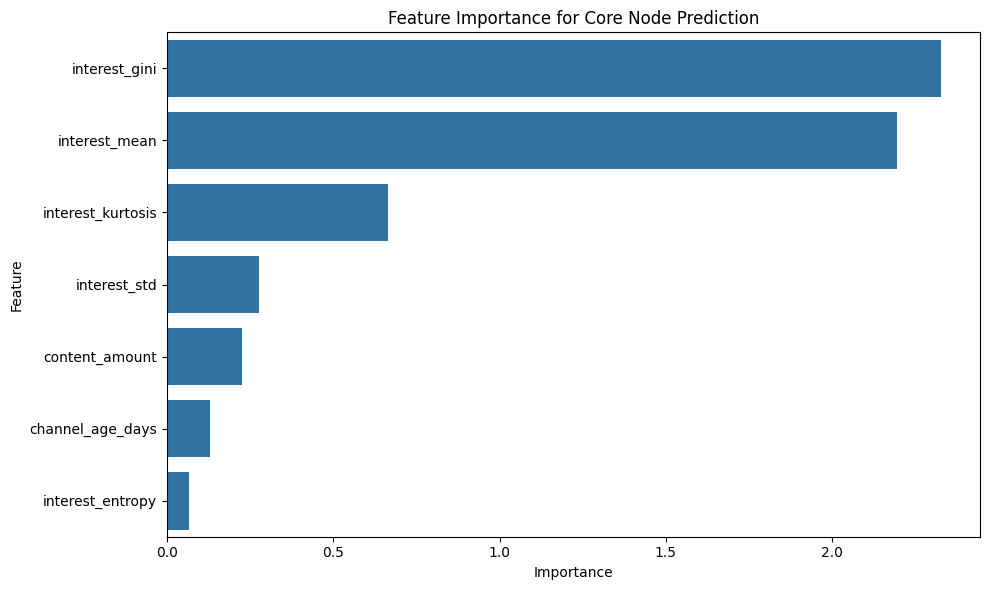

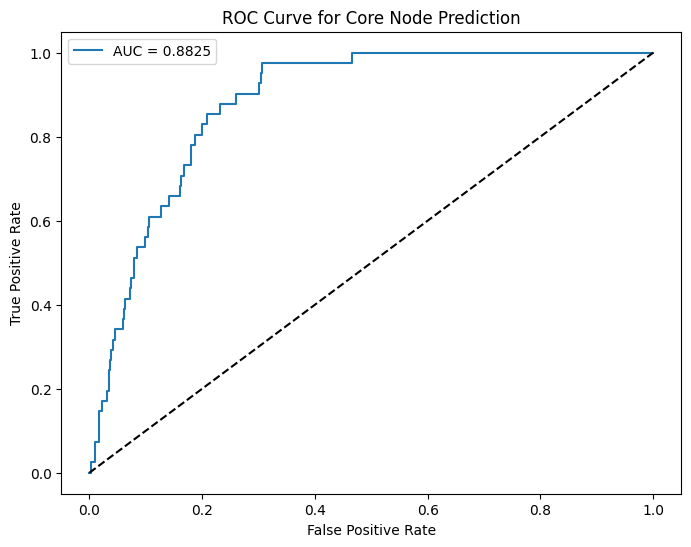

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic data that mimics the YouTube findings
def generate_synthetic_youtube_data(n_samples=5000):
    """Generate synthetic data matching YouTube channel analysis results"""
    # Generate the feature data
    data = {}
    
    # Channel attributes
    data['channel_age_days'] = np.random.normal(500, 200, n_samples)
    data['content_amount'] = np.random.normal(100, 50, n_samples)
    
    # Generate base interest features (these will be correlated)
    base = np.random.normal(0, 1, (n_samples, 3))
    
    # Calculate primary interest features with realistic distributions
    data['interest_mean'] = np.abs(0.5 * base[:, 0] + 0.3 * np.random.normal(0, 1, n_samples))
    data['interest_std'] = np.abs(0.3 * base[:, 0] + 0.2 * base[:, 1] + 0.3 * np.random.normal(0, 1, n_samples))
    data['interest_gini'] = np.abs(0.6 * base[:, 0] - 0.2 * base[:, 1] + 0.4 * np.random.normal(0, 1, n_samples))
    data['interest_gini'] = np.clip(data['interest_gini'], 0, 1)  # Gini is between 0 and 1
    data['interest_kurtosis'] = np.abs(0.4 * base[:, 0] + 0.4 * base[:, 2] + 0.4 * np.random.normal(0, 1, n_samples))
    data['interest_entropy'] = np.abs(0.3 * base[:, 1] + 0.3 * base[:, 2] + 0.1 * np.random.normal(0, 1, n_samples))
    
    # Additional interest features (may not be in best model but included for completeness)
    data['interest_max'] = data['interest_mean'] + data['interest_std'] * np.random.normal(1, 0.3, n_samples)
    data['cosine_to_network'] = np.random.normal(0.5, 0.2, n_samples)
    data['distance_to_network'] = np.random.normal(2, 0.5, n_samples)
    data['top3_concentration'] = np.random.beta(2, 2, n_samples)
    data['interest_skewness'] = np.random.normal(0, 1, n_samples)
    data['dominant_interests'] = np.random.poisson(3, n_samples)
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Generate core_nodes using coefficients similar to the YouTube findings
    # Higher values increase probability of being a core node
    z = (-5.87 * df['interest_mean'] 
         -5.08 * df['interest_gini'] 
         -1.40 * df['interest_kurtosis']
         -0.58 * df['channel_age_days'] / 1000  # Scale for numerical stability
         +0.44 * df['interest_std']
         +0.22 * df['content_amount'] / 100     # Scale for numerical stability
         -0.06 * df['interest_entropy'])
    
    # Add random noise
    z += np.random.normal(0, 2, n_samples)
    
    # Convert to probabilities with logistic function
    probs = 1 / (1 + np.exp(-z))
    
    # Create binary outcome with ~3.3% core nodes (matching YouTube data)
    threshold = np.percentile(probs, 96.7)
    df['core_nodes'] = (probs > threshold).astype(int)
    
    print(f"Generated {n_samples} samples with {df['core_nodes'].sum()} core nodes ({df['core_nodes'].mean():.1%})")
    
    return df

# Generate synthetic data
df = generate_synthetic_youtube_data(n_samples=5000)

# Basic data exploration
print("\nData Overview:")
print(df.describe())

print("\nCore Node Distribution:")
print(df['core_nodes'].value_counts())
print(f"Percentage of core nodes: {df['core_nodes'].mean():.2%}")

# Run simple logistic regression with statsmodels for detailed statistics
print("\n=== Simple Logistic Regression for Each Feature ===")
for feature in ['interest_mean', 'interest_gini', 'interest_kurtosis', 'channel_age_days', 
                'interest_std', 'content_amount', 'interest_entropy']:
    X = df[[feature]]
    X = add_constant(X)
    y = df['core_nodes']
    
    model = sm.Logit(y, X).fit(disp=0)
    
    coef = model.params[feature]
    p_value = model.pvalues[feature]
    sign = "+" if coef > 0 else "-"
    
    print(f"{feature:20}: coefficient = {coef:8.4f} ({sign}) | p-value = {p_value:.4f}")

# Run multiple logistic regression with the best feature set
best_features = ['interest_mean', 'interest_gini', 'interest_kurtosis', 
                'channel_age_days', 'interest_std', 'content_amount', 'interest_entropy']

print("\n=== Multiple Logistic Regression with Best Features ===")
X = df[best_features]
X = add_constant(X)
y = df['core_nodes']

model = sm.Logit(y, X).fit(disp=0)
print(model.summary())

# Extract coefficients and sort by absolute value
coefs = model.params[1:]  # Skip the constant
abs_coefs = abs(coefs)
sorted_idx = abs_coefs.sort_values(ascending=False).index

print("\nFeature Coefficients (sorted by absolute value):")
for feature in sorted_idx:
    sign = "+" if coefs[feature] > 0 else "-"
    print(f"{feature}: {sign} {abs(coefs[feature]):.4f}")

# ML model evaluation with sklearn
print("\n=== Machine Learning Model Evaluation ===")
X = df[best_features]
y = df['core_nodes']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Train model
model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"AUC Score: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance from ML model
importance = np.abs(model.coef_[0])
feature_importance = pd.DataFrame({
    'Feature': best_features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance from ML Model:")
for i, row in feature_importance.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance for Core Node Prediction')
plt.tight_layout()
plt.savefig('youtube_feature_importance.png')
print("\nFeature importance visualization saved as 'youtube_feature_importance.png'")

# Plot ROC curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Core Node Prediction')
plt.legend()
plt.savefig('youtube_roc_curve.png')
print("ROC curve visualization saved as 'youtube_roc_curve.png'")